In [2]:
%pip install pandas
%pip install matplotlib


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#switch the years to analyze different years

#data = pd.read_csv('c:/Users/estifo/Downloads/gamma-capture-project/data/DAT_ASCII_EURUSD_M1_2010.csv', header=None, sep=';')

In [5]:
import pandas as pd
import os

# Define the file path pattern (adjust if needed)
base_path = r"C:\Users\estifo\OneDrive\Projects\gamma-capture-project\data"

# List to store DataFrames
data_frames = []

# Loop through years 2010 to 2021
for year in range(2012, 2022):
    file_path = os.path.join(base_path, f'DAT_ASCII_EURUSD_M1_{year}.csv')
    
    # Read CSV file (adjust parameters if needed)
    df = pd.read_csv(file_path, header=None, sep=';')
    
    # Append to list
    data_frames.append(df)

# Concatenate all DataFrames into one
data = pd.concat(data_frames, ignore_index=True)

# Display first few rows to confirm
print(data.head())

                 0        1        2        3        4  5
0  20120102 020000  1.29324  1.29381  1.29324  1.29332  0
1  20120102 020100  1.29326  1.29345  1.29275  1.29341  0
2  20120102 020200  1.29342  1.29344  1.29341  1.29343  0
3  20120102 020300  1.29342  1.29342  1.29335  1.29336  0
4  20120102 020400  1.29324  1.29347  1.29320  1.29346  0


In [6]:
data.tail()

,0,1,2,3,4,5
3712742,20211231 165400,1.13797,1.13797,1.13774,1.13774,0
3712743,20211231 165500,1.13775,1.13781,1.13748,1.13748,0
3712744,20211231 165600,1.13749,1.13765,1.13704,1.13707,0
3712745,20211231 165700,1.13709,1.13740,1.13679,1.13740,0
3712746,20211231 165800,1.13740,1.13740,1.13681,1.13686,0


In [7]:
data.shape

(3712747, 6)

In [8]:
# Rename columns for clarity
data.columns = ['DateTime', 'Open', 'High', 'Low', 'Close', 'Volume']

In [9]:
data.tail(4)

,DateTime,Open,High,Low,Close,Volume
3712743,20211231 165500,1.13775,1.13781,1.13748,1.13748,0
3712744,20211231 165600,1.13749,1.13765,1.13704,1.13707,0
3712745,20211231 165700,1.13709,1.13740,1.13679,1.13740,0
3712746,20211231 165800,1.13740,1.13740,1.13681,1.13686,0


In [10]:
# Convert 'DateTime' to datetime format
data['DateTime'] = pd.to_datetime(data['DateTime'], format='%Y%m%d %H%M%S')

In [11]:
counts = data['DateTime'].value_counts()
print(counts[counts > 1])

DateTime
2019-10-27 19:00:00    2
2019-10-27 19:01:00    2
2019-10-27 19:02:00    2
2019-10-27 19:03:00    2
2019-10-27 19:04:00    2
                      ..
2021-10-31 19:55:00    2
2021-10-31 19:56:00    2
2021-10-31 19:57:00    2
2021-10-31 19:58:00    2
2021-10-31 19:59:00    2
Name: count, Length: 180, dtype: int64


In [12]:
# 1) Make a boolean mask for every duplicated timestamp (marking all occurrences)
dup_mask = data['DateTime'].duplicated(keep=False)

# 2) Subset and sort so we see each duplicated group in one place
dupe_rows = data.loc[dup_mask].sort_values('DateTime')

print(dupe_rows)


                   DateTime     Open     High      Low    Close  Volume
2904338 2019-10-27 19:00:00  1.10839  1.10844  1.10836  1.10836       0
2904398 2019-10-27 19:00:00  1.10839  1.10844  1.10836  1.10836       0
2904339 2019-10-27 19:01:00  1.10837  1.10837  1.10826  1.10826       0
2904399 2019-10-27 19:01:00  1.10837  1.10837  1.10826  1.10826       0
2904340 2019-10-27 19:02:00  1.10826  1.10826  1.10822  1.10822       0
...                     ...      ...      ...      ...      ...     ...
3648533 2021-10-31 19:57:00  1.15526  1.15526  1.15518  1.15520       0
3648594 2021-10-31 19:58:00  1.15520  1.15545  1.15518  1.15545       0
3648534 2021-10-31 19:58:00  1.15520  1.15545  1.15518  1.15545       0
3648535 2021-10-31 19:59:00  1.15545  1.15555  1.15543  1.15551       0
3648595 2021-10-31 19:59:00  1.15545  1.15555  1.15543  1.15551       0

[360 rows x 6 columns]


In [13]:
data.tail()

,DateTime,Open,High,Low,Close,Volume
3712742,2021-12-31 16:54:00,1.13797,1.13797,1.13774,1.13774,0
3712743,2021-12-31 16:55:00,1.13775,1.13781,1.13748,1.13748,0
3712744,2021-12-31 16:56:00,1.13749,1.13765,1.13704,1.13707,0
3712745,2021-12-31 16:57:00,1.13709,1.13740,1.13679,1.13740,0
3712746,2021-12-31 16:58:00,1.13740,1.13740,1.13681,1.13686,0


In [14]:
data.set_index('DateTime', inplace=True)

In [15]:
data

,Open,High,Low,Close,Volume
DateTime,,,,,
2012-01-02 02:00:00,1.29324,1.29381,1.29324,1.29332,0
2012-01-02 02:01:00,1.29326,1.29345,1.29275,1.29341,0
2012-01-02 02:02:00,1.29342,1.29344,1.29341,1.29343,0
2012-01-02 02:03:00,1.29342,1.29342,1.29335,1.29336,0
2012-01-02 02:04:00,1.29324,1.29347,1.29320,1.29346,0
...,...,...,...,...,...
2021-12-31 16:54:00,1.13797,1.13797,1.13774,1.13774,0
2021-12-31 16:55:00,1.13775,1.13781,1.13748,1.13748,0
2021-12-31 16:56:00,1.13749,1.13765,1.13704,1.13707,0


In [16]:
# Ensure 'DateTime' is the index
data.index = pd.to_datetime(data.index)

# Generate a full range of 1-minute timestamps
full_range = pd.date_range(start=data.index.min(), end=data.index.max(), freq='1T')

C:\Users\estifo\AppData\Local\Temp\ipykernel_4088\4214865167.py:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_range = pd.date_range(start=data.index.min(), end=data.index.max(), freq='1T')


In [17]:
full_range

DatetimeIndex(['2012-01-02 02:00:00', '2012-01-02 02:01:00',
               '2012-01-02 02:02:00', '2012-01-02 02:03:00',
               '2012-01-02 02:04:00', '2012-01-02 02:05:00',
               '2012-01-02 02:06:00', '2012-01-02 02:07:00',
               '2012-01-02 02:08:00', '2012-01-02 02:09:00',
               ...
               '2021-12-31 16:49:00', '2021-12-31 16:50:00',
               '2021-12-31 16:51:00', '2021-12-31 16:52:00',
               '2021-12-31 16:53:00', '2021-12-31 16:54:00',
               '2021-12-31 16:55:00', '2021-12-31 16:56:00',
               '2021-12-31 16:57:00', '2021-12-31 16:58:00'],
              dtype='datetime64[ns]', length=5258339, freq='min')

In [18]:
# Find missing timestamps
missing_timestamps = full_range.difference(data.index)   # Identifies missing timestamps

# Display missing timestamps
print(f"Missing Timestamps:\n{missing_timestamps}")


Missing Timestamps:
DatetimeIndex(['2012-01-02 09:24:00', '2012-01-02 10:41:00',
               '2012-01-02 12:29:00', '2012-01-02 12:32:00',
               '2012-01-02 12:34:00', '2012-01-02 12:36:00',
               '2012-01-02 12:45:00', '2012-01-02 13:08:00',
               '2012-01-02 13:15:00', '2012-01-02 13:16:00',
               ...
               '2021-12-30 23:48:00', '2021-12-31 00:25:00',
               '2021-12-31 00:43:00', '2021-12-31 00:48:00',
               '2021-12-31 00:52:00', '2021-12-31 01:58:00',
               '2021-12-31 02:17:00', '2021-12-31 13:43:00',
               '2021-12-31 14:07:00', '2021-12-31 14:36:00'],
              dtype='datetime64[ns]', length=1545772, freq=None)


In [19]:
data.iloc[35:45]

,Open,High,Low,Close,Volume
DateTime,,,,,
2012-01-02 02:35:00,1.29411,1.29421,1.29409,1.29413,0
2012-01-02 02:36:00,1.29414,1.29421,1.29414,1.29415,0
2012-01-02 02:37:00,1.29424,1.29453,1.29424,1.29447,0
2012-01-02 02:38:00,1.29431,1.29431,1.29391,1.29410,0
2012-01-02 02:39:00,1.29414,1.29430,1.29402,1.29424,0
2012-01-02 02:40:00,1.29426,1.29427,1.29413,1.29424,0
2012-01-02 02:41:00,1.29425,1.29436,1.29424,1.29427,0
2012-01-02 02:42:00,1.29426,1.29447,1.29423,1.29425,0
2012-01-02 02:43:00,1.29428,1.29428,1.29393,1.29396,0


In [20]:
data.iloc[50:60]

,Open,High,Low,Close,Volume
DateTime,,,,,
2012-01-02 02:50:00,1.29418,1.29429,1.29408,1.29419,0
2012-01-02 02:51:00,1.29422,1.29439,1.29422,1.29431,0
2012-01-02 02:52:00,1.29424,1.29439,1.29413,1.29413,0
2012-01-02 02:53:00,1.29414,1.29416,1.29414,1.29414,0
2012-01-02 02:54:00,1.29412,1.29415,1.29412,1.29414,0
2012-01-02 02:55:00,1.29413,1.29413,1.29402,1.29404,0
2012-01-02 02:56:00,1.29402,1.29419,1.29396,1.29416,0
2012-01-02 02:57:00,1.29412,1.29420,1.29407,1.29411,0
2012-01-02 02:58:00,1.29410,1.29410,1.29409,1.29409,0


In [21]:
missing_timestamps.shape   # All missing timestamps (including weekends)

(1545772,)

In [22]:
# Convert missing timestamps to a DataFrame
missing_df = pd.DataFrame(missing_timestamps, columns=['DateTime'])

In [23]:
missing_df['indicator'] = 1
missing_df

,DateTime,indicator
0,2012-01-02 09:24:00,1
1,2012-01-02 10:41:00,1
2,2012-01-02 12:29:00,1
3,2012-01-02 12:32:00,1
4,2012-01-02 12:34:00,1
...,...,...
1545767,2021-12-31 01:58:00,1
1545768,2021-12-31 02:17:00,1
1545769,2021-12-31 13:43:00,1
1545770,2021-12-31 14:07:00,1


In [24]:
# Generate a complete time range with 1-minute frequency
# Instead of data['DateTime'], use data.index to access the DateTime values
full_range = pd.date_range(start=data.index.min(), end=data.index.max(), freq='T')

C:\Users\estifo\AppData\Local\Temp\ipykernel_4088\2015894820.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_range = pd.date_range(start=data.index.min(), end=data.index.max(), freq='T')


In [25]:
# Create a dataframe from the complete time range
complete_df = pd.DataFrame(full_range, columns=['DateTime'])

# Merge the original dataframe with the complete time range
combined_df = pd.merge(complete_df, data, on='DateTime', how='left')

In [26]:
# Merge the missing dataframe with the combined dataframe
combined_df = pd.merge(combined_df, missing_df, on='DateTime', how='left')

In [27]:
combined_df

,DateTime,Open,High,Low,Close,Volume,indicator
0,2012-01-02 02:00:00,1.29324,1.29381,1.29324,1.29332,0.0,NaN
1,2012-01-02 02:01:00,1.29326,1.29345,1.29275,1.29341,0.0,NaN
2,2012-01-02 02:02:00,1.29342,1.29344,1.29341,1.29343,0.0,NaN
3,2012-01-02 02:03:00,1.29342,1.29342,1.29335,1.29336,0.0,NaN
4,2012-01-02 02:04:00,1.29324,1.29347,1.29320,1.29346,0.0,NaN
...,...,...,...,...,...,...,...
5258514,2021-12-31 16:54:00,1.13797,1.13797,1.13774,1.13774,0.0,NaN
5258515,2021-12-31 16:55:00,1.13775,1.13781,1.13748,1.13748,0.0,NaN
5258516,2021-12-31 16:56:00,1.13749,1.13765,1.13704,1.13707,0.0,NaN
5258517,2021-12-31 16:57:00,1.13709,1.13740,1.13679,1.13740,0.0,NaN


In [28]:
# Fill the 'indicator' column: 0 for non-missing, 1 for missing
combined_df['indicator'] = combined_df['indicator'].fillna(0).astype(int)

# Sort by DateTime (optional)
combined_df = combined_df.sort_values(by='DateTime').reset_index(drop=True)

In [29]:
combined_df.shape

(5258519, 7)

In [30]:
#######    EXPLANATORY DATA ANALYSIS   #######

In [31]:
'''
####   DUPLICATED DATA ANALYSIS  #####
# plt.figure(figsize=(22, 5))
plt.bar(dup_per_day.index, dup_per_day.values, color='purple')
plt.title('Duplicate Data Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Duplicate Price Occurrences')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Plot duplicate occurrences per day
plt.figure(figsize=(22, 5))
dup_per_day.plot(kind='bar', color='purple')
plt.title('Duplicate Data Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Duplicate Price Occurrences')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
'''

"\n####   DUPLICATED DATA ANALYSIS  #####\n# plt.figure(figsize=(22, 5))\nplt.bar(dup_per_day.index, dup_per_day.values, color='purple')\nplt.title('Duplicate Data Per Day')\nplt.xlabel('Date')\nplt.ylabel('Number of Duplicate Price Occurrences')\nplt.xticks(rotation=45)\nplt.grid(axis='y', linestyle='--', alpha=0.7)\nplt.show()\n\n\n# Plot duplicate occurrences per day\nplt.figure(figsize=(22, 5))\ndup_per_day.plot(kind='bar', color='purple')\nplt.title('Duplicate Data Per Day')\nplt.xlabel('Date')\nplt.ylabel('Number of Duplicate Price Occurrences')\nplt.xticks(rotation=45)\nplt.grid(axis='y', linestyle='--', alpha=0.7)\nplt.show()\n"

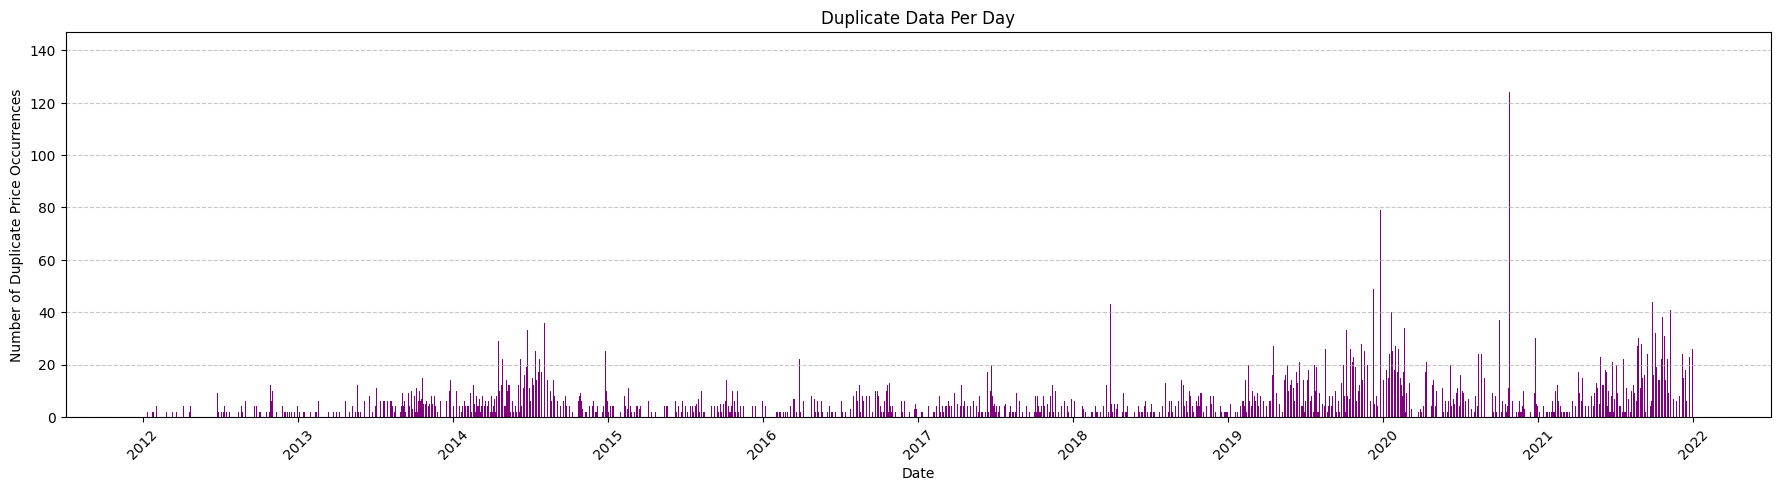

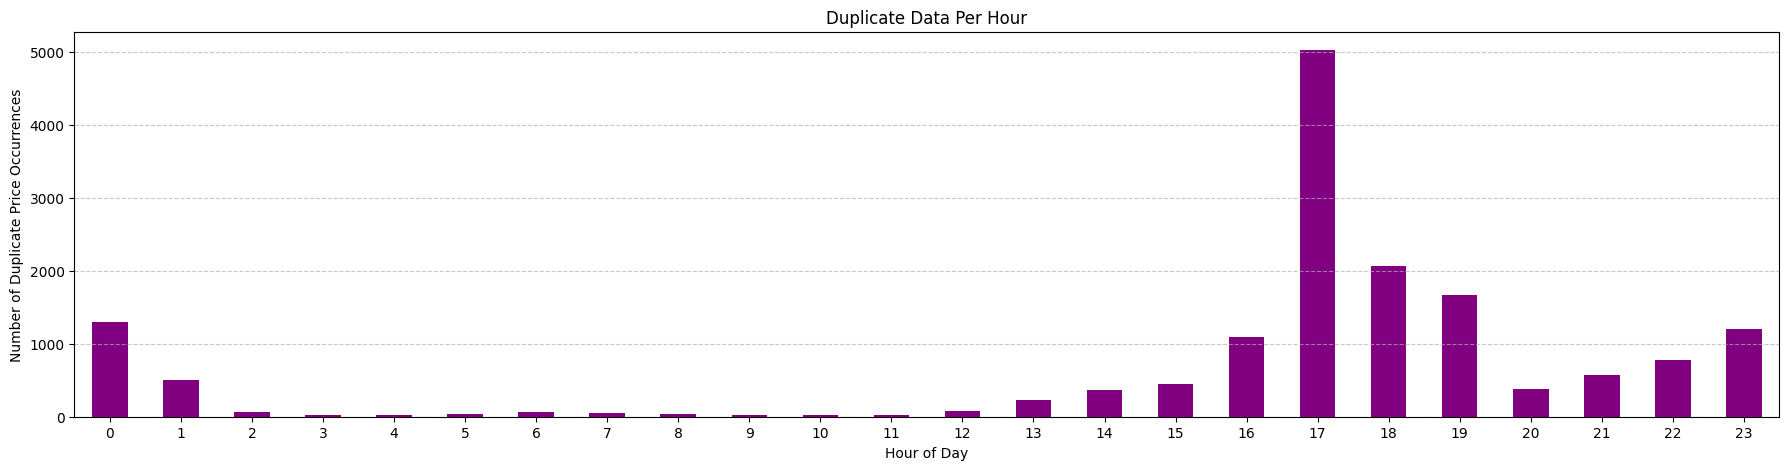

In [32]:
# Ensure DateTime is in datetime format
combined_df['DateTime'] = pd.to_datetime(combined_df['DateTime'])

# Identify duplicated consecutive OHLC prices
dup_consecutive = combined_df[['Open', 'High', 'Low', 'Close']].eq(combined_df[['Open', 'High', 'Low', 'Close']].shift(-1)).all(axis=1) | \
                  combined_df[['Open', 'High', 'Low', 'Close']].eq(combined_df[['Open', 'High', 'Low', 'Close']].shift(1)).all(axis=1)

dup_df = combined_df[dup_consecutive]

# Group duplicate occurrences by date
dup_per_day = dup_df.groupby(dup_df['DateTime'].dt.date).size()

#  Group by hour and count occurrences of duplicate data
dup_per_hour = dup_df.groupby(dup_df['DateTime'].dt.hour).size()

# 
plt.figure(figsize=(22, 5))
plt.bar(dup_per_day.index, dup_per_day.values, color='purple')
plt.title('Duplicate Data Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Duplicate Price Occurrences')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot the bar chart for duplicate data occurrences per hour
plt.figure(figsize=(22, 5))
dup_per_hour.plot(kind='bar', color='purple')
plt.title('Duplicate Data Per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Duplicate Price Occurrences')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

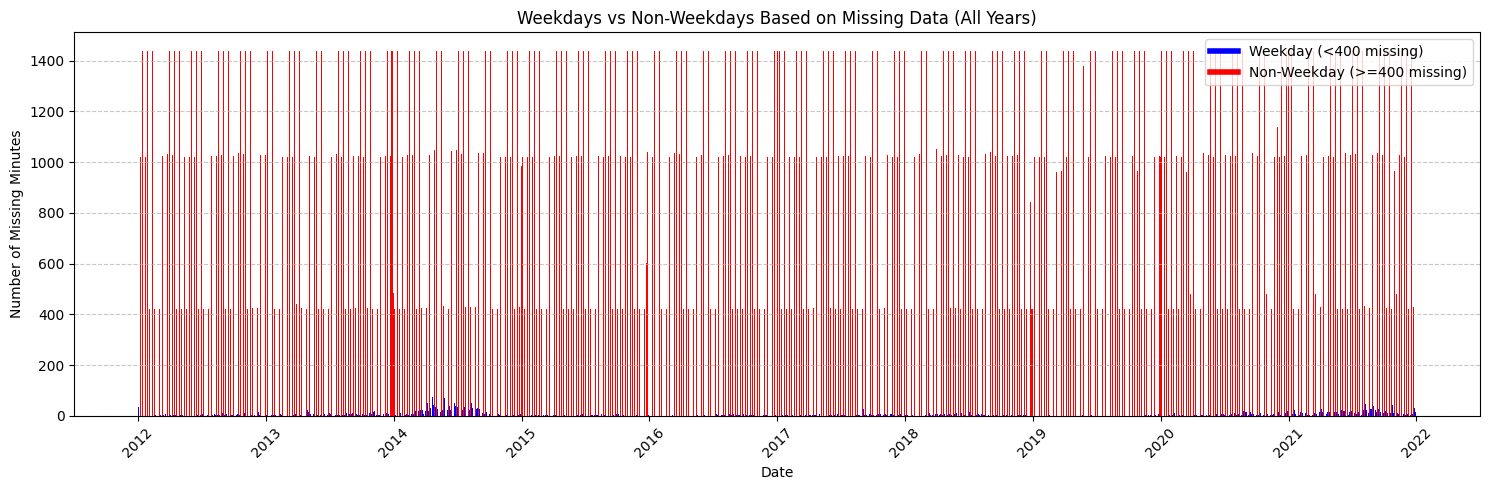

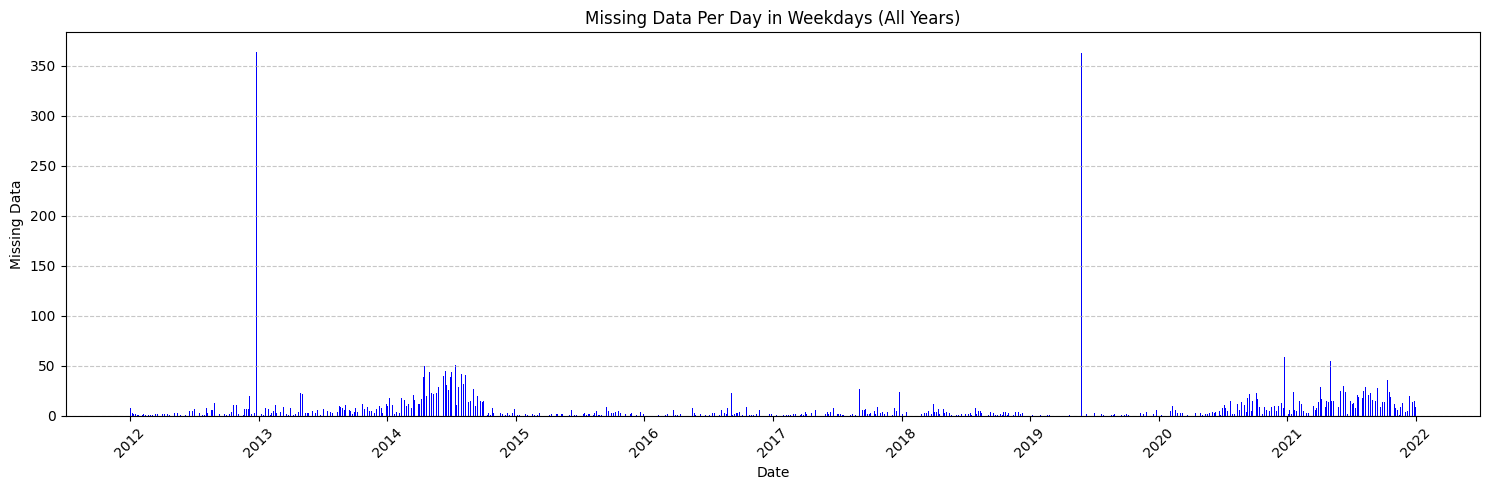

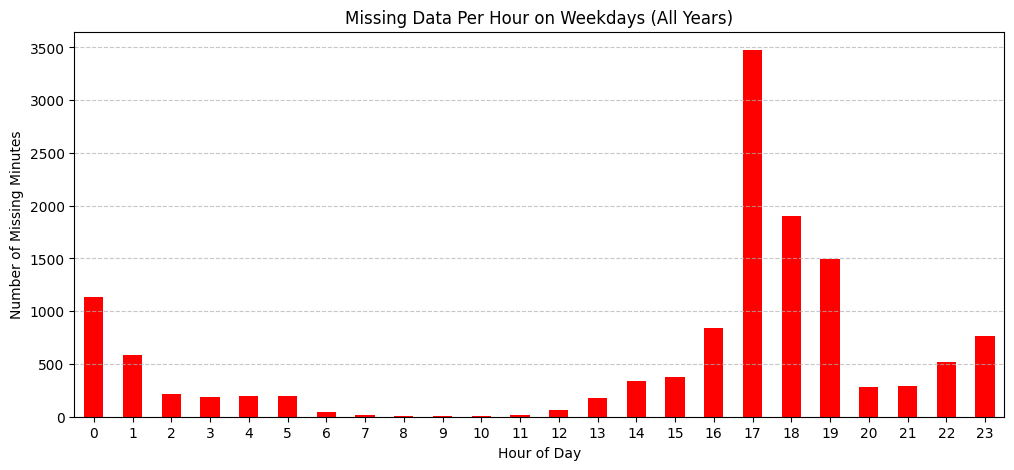

In [33]:
import pandas as pd
import matplotlib.pyplot as plt



# Ensure DateTime is in datetime format
combined_df['DateTime'] = pd.to_datetime(combined_df['DateTime'])

# Step 1: Group by date and sum the indicator column (missing minutes per day)
missing_per_day = combined_df.groupby(combined_df['DateTime'].dt.date)['indicator'].sum()

# Step 2: Identify weekdays (days with less than 400 missing data)
weekdays = missing_per_day[missing_per_day < 400].index       

# Step 3: Filter the dataframe to include only weekdays
weekday_df = combined_df[combined_df['DateTime'].dt.date.isin(weekdays)]

# Step 4: Group by hour and sum missing data
missing_per_hour_weekdays = weekday_df.groupby(weekday_df['DateTime'].dt.hour)['indicator'].sum()

# Step 5: Add year-wise grouping for better analysis
missing_per_day_yearly = combined_df.groupby([combined_df['DateTime'].dt.year, combined_df['DateTime'].dt.date])['indicator'].sum()

# --- PLOTS ---

plt.figure(figsize=(15, 5))
colors = ['blue' if date in weekdays else 'red' for date in missing_per_day.index]
plt.bar(missing_per_day.index, missing_per_day.values, color=colors)

plt.title('Weekdays vs Non-Weekdays Based on Missing Data (All Years)')
plt.xlabel('Date')
plt.ylabel('Number of Missing Minutes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4, label='Weekday (<400 missing)')
red_patch = plt.Line2D([0], [0], color='red', lw=4, label='Non-Weekday (>=400 missing)')
plt.legend(handles=[blue_patch, red_patch])
plt.tight_layout()
plt.show()


weekday_missing_data = missing_per_day[weekdays]
plt.figure(figsize=(15, 5))
plt.bar(weekday_missing_data.index, weekday_missing_data.values, color='blue')

plt.title('Missing Data Per Day in Weekdays (All Years)')
plt.xlabel('Date')
plt.ylabel('Missing Data')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Plot Step 4: Missing data per hour on weekdays
plt.figure(figsize=(12, 5))
missing_per_hour_weekdays.plot(kind='bar', color='red')
plt.title('Missing Data Per Hour on Weekdays (All Years)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Missing Minutes')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [34]:
missing_per_day

DateTime
2012-01-02     34
2012-01-03      8
2012-01-04      0
2012-01-05      1
2012-01-06    421
             ... 
2021-12-27     30
2021-12-28     15
2021-12-29     18
2021-12-30     17
2021-12-31      9
Name: indicator, Length: 3652, dtype: int64

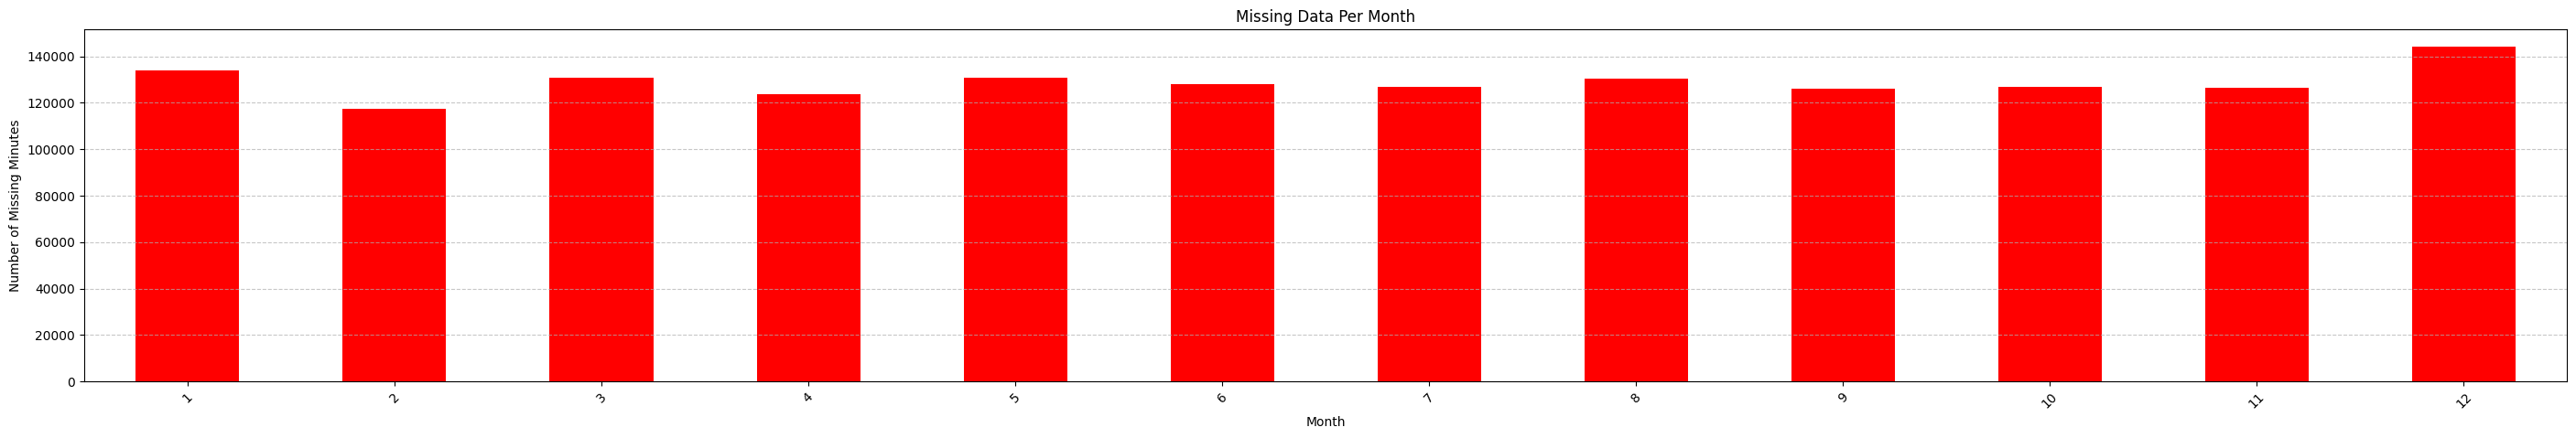

In [35]:
# Group by month and sum the indicator column (missing minutes per month)
missing_per_month = combined_df.groupby(combined_df['DateTime'].dt.month)['indicator'].sum()

# Plot the bar chart
plt.figure(figsize=(35, 5))
missing_per_month.plot(kind='bar', color='red')
plt.title('Missing Data Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Missing Minutes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [36]:
# We expect to have 4 weekends/ mo. Therefore 4*2*24*60 minutes missing per month = 11,520

In [37]:
print(missing_per_month)

DateTime
1     133889
2     117307
3     130743
4     123789
5     130668
6     128124
7     127025
8     130626
9     126070
10    126858
11    126306
12    144367
Name: indicator, dtype: int64


In [38]:
sum(missing_per_month)-(11520*12)

1407532

In [39]:
def remove_all_consecutive_duplicates(df):
    """Remove consecutive OHLC duplicates and flat bars with no price movement"""
    df_clean = df.copy()
    
    while True:
        # Check for consecutive duplicates
        prev_dup = (
            (df_clean['Open'] == df_clean['Open'].shift(1)) & 
            (df_clean['High'] == df_clean['High'].shift(1)) & 
            (df_clean['Low'] == df_clean['Low'].shift(1)) & 
            (df_clean['Close'] == df_clean['Close'].shift(1))
        )
        
        next_dup = (
            (df_clean['Open'] == df_clean['Open'].shift(-1)) & 
            (df_clean['High'] == df_clean['High'].shift(-1)) & 
            (df_clean['Low'] == df_clean['Low'].shift(-1)) & 
            (df_clean['Close'] == df_clean['Close'].shift(-1))
        )
        
        # Check for flat bars (no price movement)
        flat_bar = (
            (df_clean['Open'] == df_clean['High']) & 
            (df_clean['Open'] == df_clean['Low']) & 
            (df_clean['Open'] == df_clean['Close'])
        )
        
        # Combine conditions
        is_duplicate = prev_dup | next_dup | flat_bar
        count = is_duplicate.sum()
        
        if count == 0:
            break
            
        print(f"Marking {count} duplicates and flat bars…")

        # 1) blank out the OHLC
        df_clean.loc[is_duplicate, ['Open','High','Low','Close']] = np.nan
        df_clean.loc[is_duplicate, 'Volume'] = 0
        # 2) flag them
        df_clean.loc[is_duplicate, 'indicator'] = 1
        
    
    
    return df_clean

def remove_duplicate_timestamps(df):
    """
    Remove rows so that every DateTime is unique.
    Keeps the first occurrence of each timestamp and deletes all others.
    """
    df_clean = df.copy()

    while True:
        # Mark all rows whose DateTime appears more than once
        dup_mask = df_clean['DateTime'].duplicated(keep=False)
        if not dup_mask.any():
            break

        # Of those duplicates, keep only the first in each group
        to_remove = df_clean['DateTime'].duplicated(keep='first')
        count = to_remove.sum()
        print(f"Removing {count} rows with duplicate timestamps…")

        df_clean = df_clean.loc[~to_remove].reset_index(drop=True)

    return df_clean

def process_duplicated_data(df):
    """
    Process the DataFrame to remove duplicate timestamps and consecutive duplicates.
    """
    # Remove duplicate timestamps
    df = remove_duplicate_timestamps(df)

    # Remove consecutive duplicates and flat bars
    df = remove_all_consecutive_duplicates(df)

    return df


In [40]:
final_data_clean = process_duplicated_data(combined_df)

Removing 180 rows with duplicate timestamps…
Marking 57130 duplicates and flat bars…


In [41]:
def check_dup(data):
    # Check for consecutive duplicates with previous row
    verify_prev = (
        (data['Open'] == data['Open'].shift(1)) & 
        (data['High'] == data['High'].shift(1)) & 
        (data['Low'] == data['Low'].shift(1)) & 
        (data['Close'] == data['Close'].shift(1))
    )
    
    # Check for consecutive duplicates with next row
    verify_next = (
        (data['Open'] == data['Open'].shift(-1)) & 
        (data['High'] == data['High'].shift(-1)) & 
        (data['Low'] == data['Low'].shift(-1)) & 
        (data['Close'] == data['Close'].shift(-1))
    )
    
    # Check for flat bars (no price movement)
    flat_bar = (
        (data['Open'] == data['High']) & 
        (data['Open'] == data['Low']) & 
        (data['Open'] == data['Close'])
    )
    
    # Count each type of duplicate
    consecutive_dups = (verify_prev | verify_next).sum()
    flat_bars = flat_bar.sum()
    total_dups = (verify_prev | verify_next | flat_bar).sum()
    
    print(f"Consecutive duplicates: {consecutive_dups}")
    print(f"Flat bars (no price movement): {flat_bars}")
    print(f"Total issues: {total_dups}")
    
    return total_dups

In [42]:
check_dup(final_data_clean)

Consecutive duplicates: 0
Flat bars (no price movement): 0
Total issues: 0


np.int64(0)

In [43]:
final_data_clean

,DateTime,Open,High,Low,Close,Volume,indicator
0,2012-01-02 02:00:00,1.29324,1.29381,1.29324,1.29332,0.0,0
1,2012-01-02 02:01:00,1.29326,1.29345,1.29275,1.29341,0.0,0
2,2012-01-02 02:02:00,1.29342,1.29344,1.29341,1.29343,0.0,0
3,2012-01-02 02:03:00,1.29342,1.29342,1.29335,1.29336,0.0,0
4,2012-01-02 02:04:00,1.29324,1.29347,1.29320,1.29346,0.0,0
...,...,...,...,...,...,...,...
5258334,2021-12-31 16:54:00,1.13797,1.13797,1.13774,1.13774,0.0,0
5258335,2021-12-31 16:55:00,1.13775,1.13781,1.13748,1.13748,0.0,0
5258336,2021-12-31 16:56:00,1.13749,1.13765,1.13704,1.13707,0.0,0
5258337,2021-12-31 16:57:00,1.13709,1.13740,1.13679,1.13740,0.0,0


In [44]:
final_data = final_data_clean.copy()
# Ensure 'DateTime' is the index
#final_data.index = pd.to_datetime(final_data.index)

<Axes: >

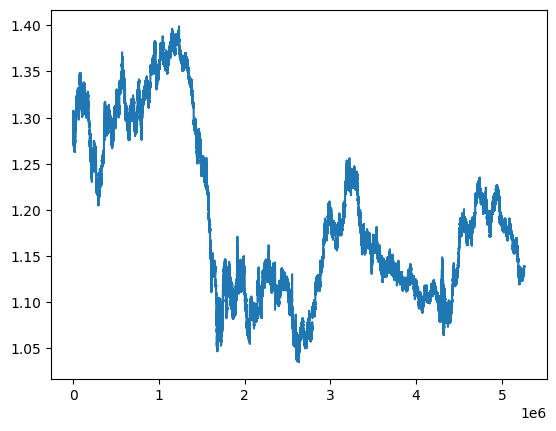

In [45]:
final_data['Close'].plot()    ### plot data nicely including years

In [46]:
final_data

,DateTime,Open,High,Low,Close,Volume,indicator
0,2012-01-02 02:00:00,1.29324,1.29381,1.29324,1.29332,0.0,0
1,2012-01-02 02:01:00,1.29326,1.29345,1.29275,1.29341,0.0,0
2,2012-01-02 02:02:00,1.29342,1.29344,1.29341,1.29343,0.0,0
3,2012-01-02 02:03:00,1.29342,1.29342,1.29335,1.29336,0.0,0
4,2012-01-02 02:04:00,1.29324,1.29347,1.29320,1.29346,0.0,0
...,...,...,...,...,...,...,...
5258334,2021-12-31 16:54:00,1.13797,1.13797,1.13774,1.13774,0.0,0
5258335,2021-12-31 16:55:00,1.13775,1.13781,1.13748,1.13748,0.0,0
5258336,2021-12-31 16:56:00,1.13749,1.13765,1.13704,1.13707,0.0,0
5258337,2021-12-31 16:57:00,1.13709,1.13740,1.13679,1.13740,0.0,0


In [47]:
data = final_data.copy()

In [48]:
data['Close'].iloc[374920:374950].max()

np.float64(1.30672)

In [49]:
data['Close'].nlargest(n=5)

1234478    1.39897
1234477    1.39886
1234486    1.39874
1234485    1.39860
1234479    1.39837
Name: Close, dtype: float64

In [50]:
max_idx = data['Close'].idxmax()
max_idx

1234478

In [51]:
data.loc[max_idx, :] = np.nan

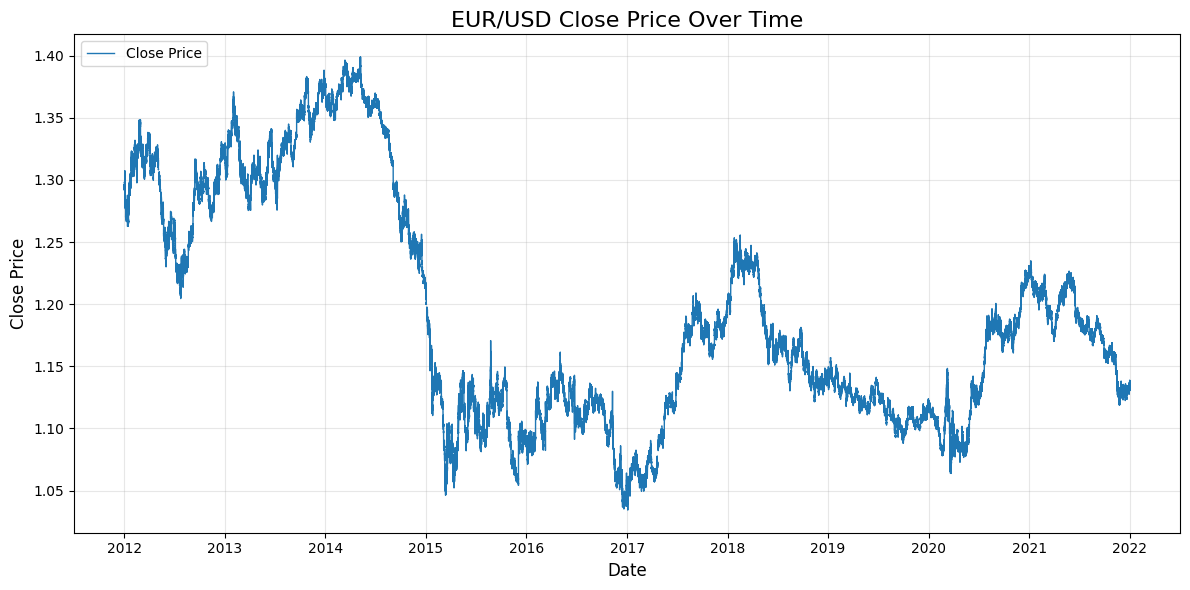

In [52]:

# Plot the 'Close' prices
plt.figure(figsize=(12, 6))
plt.plot(data['DateTime'], data['Close'], label='Close Price', linewidth=1)

# Enhancing the plot aesthetics
plt.title('EUR/USD Close Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()


In [53]:
# Create a column to identify hourly groups
data['Hour'] = pd.to_datetime(data['DateTime']).dt.floor('h').dt.hour
data

,DateTime,Open,High,Low,Close,Volume,indicator,Hour
0,2012-01-02 02:00:00,1.29324,1.29381,1.29324,1.29332,0.0,0.0,2.0
1,2012-01-02 02:01:00,1.29326,1.29345,1.29275,1.29341,0.0,0.0,2.0
2,2012-01-02 02:02:00,1.29342,1.29344,1.29341,1.29343,0.0,0.0,2.0
3,2012-01-02 02:03:00,1.29342,1.29342,1.29335,1.29336,0.0,0.0,2.0
4,2012-01-02 02:04:00,1.29324,1.29347,1.29320,1.29346,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...
5258334,2021-12-31 16:54:00,1.13797,1.13797,1.13774,1.13774,0.0,0.0,16.0
5258335,2021-12-31 16:55:00,1.13775,1.13781,1.13748,1.13748,0.0,0.0,16.0
5258336,2021-12-31 16:56:00,1.13749,1.13765,1.13704,1.13707,0.0,0.0,16.0
5258337,2021-12-31 16:57:00,1.13709,1.13740,1.13679,1.13740,0.0,0.0,16.0


In [54]:
#data.reset_index(inplace=True)

In [55]:
data

,DateTime,Open,High,Low,Close,Volume,indicator,Hour
0,2012-01-02 02:00:00,1.29324,1.29381,1.29324,1.29332,0.0,0.0,2.0
1,2012-01-02 02:01:00,1.29326,1.29345,1.29275,1.29341,0.0,0.0,2.0
2,2012-01-02 02:02:00,1.29342,1.29344,1.29341,1.29343,0.0,0.0,2.0
3,2012-01-02 02:03:00,1.29342,1.29342,1.29335,1.29336,0.0,0.0,2.0
4,2012-01-02 02:04:00,1.29324,1.29347,1.29320,1.29346,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...
5258334,2021-12-31 16:54:00,1.13797,1.13797,1.13774,1.13774,0.0,0.0,16.0
5258335,2021-12-31 16:55:00,1.13775,1.13781,1.13748,1.13748,0.0,0.0,16.0
5258336,2021-12-31 16:56:00,1.13749,1.13765,1.13704,1.13707,0.0,0.0,16.0
5258337,2021-12-31 16:57:00,1.13709,1.13740,1.13679,1.13740,0.0,0.0,16.0


In [56]:
#data.drop(columns=['index'], inplace=True)

In [57]:
data.head(20)

,DateTime,Open,High,Low,Close,Volume,indicator,Hour
0,2012-01-02 02:00:00,1.29324,1.29381,1.29324,1.29332,0.0,0.0,2.0
1,2012-01-02 02:01:00,1.29326,1.29345,1.29275,1.29341,0.0,0.0,2.0
2,2012-01-02 02:02:00,1.29342,1.29344,1.29341,1.29343,0.0,0.0,2.0
3,2012-01-02 02:03:00,1.29342,1.29342,1.29335,1.29336,0.0,0.0,2.0
4,2012-01-02 02:04:00,1.29324,1.29347,1.29320,1.29346,0.0,0.0,2.0
5,2012-01-02 02:05:00,1.29354,1.29415,1.29354,1.29392,0.0,0.0,2.0
6,2012-01-02 02:06:00,1.29393,1.29442,1.29391,1.29430,0.0,0.0,2.0
7,2012-01-02 02:07:00,1.29429,1.29429,1.29395,1.29395,0.0,0.0,2.0
8,2012-01-02 02:08:00,1.29396,1.29408,1.29395,1.29407,0.0,0.0,2.0
9,2012-01-02 02:09:00,1.29406,1.29434,1.29401,1.29420,0.0,0.0,2.0


In [58]:
# Count how many times each timestamp appears:
counts = data['DateTime'].value_counts()
print(counts[counts > 1])


Series([], Name: count, dtype: int64)


In [59]:
########################################################################
########################################################################
#############   SPY 15 VOL TEST DATASET   ##############################

In [60]:
df = pd.read_csv(r"C:\Users\estifo\Downloads\SPY1Day15Vol.csv")
df['mid'] = (df['bid '] + df['ask'])/2

# 1. Make sure your time column is datetime and floor it to the minute
df['time'] = pd.to_datetime(df['time'])
df['minute'] = df['time'].dt.floor('T')

# 2. Assign group_id by “which minute‐bin” each row belongs to
df['group_id'] = df.groupby('minute').ngroup()

# 3. Now compute the OHLC on mid for each group_id
mid_ohlc = (
    df
    .groupby('group_id')
    .agg(
        minute = ('minute', 'first'),
        open   = ('mid',    'first'),
        high   = ('mid',    'max'),
        low    = ('mid',    'min'),
        close  = ('mid',    'last')
    )
    .reset_index()
)

# mid_ohlc now has:
#   group_id | minute           | open      | high      | low       | close
#   -------------------------------------------------------------------------
#     0      | 2025-02-19 08:00 | 609.6209  | 609.6287  | 609.6209  | …
#     1      | 2025-02-19 08:01 | 609.4673  | 609.5114  | 609.4503  | …
#     2      | 2025-02-19 08:02 | …         | …         | …         | …



C:\Users\estifo\AppData\Local\Temp\ipykernel_4088\461763248.py:1: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\estifo\Downloads\SPY1Day15Vol.csv")
C:\Users\estifo\AppData\Local\Temp\ipykernel_4088\461763248.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time'] = pd.to_datetime(df['time'])
C:\Users\estifo\AppData\Local\Temp\ipykernel_4088\461763248.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df['minute'] = df['time'].dt.floor('T')


In [61]:
mid_ohlc

,group_id,minute,open,high,low,close
0,0.0,2025-02-19 08:00:00,609.620921,609.718208,609.435313,609.469308
1,1.0,2025-02-19 08:01:00,609.458008,609.531182,609.437541,609.474540
2,2.0,2025-02-19 08:02:00,609.472416,609.530265,609.427305,609.446263
3,3.0,2025-02-19 08:03:00,609.439725,609.490422,609.400389,609.425303
4,4.0,2025-02-19 08:04:00,609.419199,609.421599,609.263119,609.277285
...,...,...,...,...,...,...
776,776.0,2025-02-19 20:56:00,610.653237,610.653237,610.366333,610.403551
777,777.0,2025-02-19 20:57:00,610.403186,610.421814,610.076369,610.155527
778,778.0,2025-02-19 20:58:00,610.156854,610.246400,610.081910,610.179745
779,779.0,2025-02-19 20:59:00,610.174585,610.208648,610.006565,610.129943


In [62]:
# assuming your per-minute OHLC is in mid_ohlc

# 1. Create `indicator` = 1 if any of open/high/low/close is NaN, else 0
mid_ohlc['indicator'] = (
    mid_ohlc[['open','high','low','close']]
    .isnull()
    .any(axis=1)
    .astype(int)
)

# Now mid_ohlc looks like:
#    group_id  minute              open      high       low      close  indicator
# 0         0 2025-02-19 08:00:00  609.6209  609.7182  609.4353  609.4693          0
# 1         1 2025-02-19 08:01:00  609.4580  609.5312  609.4375  609.4745          0
# ...     ...                 ...       ...       ...       ...       ...
# n       781 2025-02-19 21:01:00       NaN       NaN       NaN       NaN          1


In [63]:
mid_ohlc['DateTime'] = pd.to_datetime(mid_ohlc['minute'])

In [64]:
mid_ohlc = mid_ohlc.drop(columns=['minute'])

In [65]:
# Rename the lowercase OHLC columns to Titlecase
mid_ohlc = mid_ohlc.rename(columns={
    'open':  'Open',
    'high':  'High',
    'low':   'Low',
    'close': 'Close'
})

# Add a Volume column, all zeros (same length as mid_ohlc)
mid_ohlc['Volume'] = 0

In [66]:
#mid_ohlc

In [67]:
#mid_ohlc.to_csv(r"C:\Users\estifo\Downloads\SPY1Day15Vol_OHLC.csv", index=False)

In [68]:
#########################################################################

In [69]:
data#.iloc[6150:6200]

,DateTime,Open,High,Low,Close,Volume,indicator,Hour
0,2012-01-02 02:00:00,1.29324,1.29381,1.29324,1.29332,0.0,0.0,2.0
1,2012-01-02 02:01:00,1.29326,1.29345,1.29275,1.29341,0.0,0.0,2.0
2,2012-01-02 02:02:00,1.29342,1.29344,1.29341,1.29343,0.0,0.0,2.0
3,2012-01-02 02:03:00,1.29342,1.29342,1.29335,1.29336,0.0,0.0,2.0
4,2012-01-02 02:04:00,1.29324,1.29347,1.29320,1.29346,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...
5258334,2021-12-31 16:54:00,1.13797,1.13797,1.13774,1.13774,0.0,0.0,16.0
5258335,2021-12-31 16:55:00,1.13775,1.13781,1.13748,1.13748,0.0,0.0,16.0
5258336,2021-12-31 16:56:00,1.13749,1.13765,1.13704,1.13707,0.0,0.0,16.0
5258337,2021-12-31 16:57:00,1.13709,1.13740,1.13679,1.13740,0.0,0.0,16.0


In [70]:
#########################     SAMPLE DATASET GENERATING FUNCTION   #########################

In [71]:
import pandas as pd
import numpy as np

def generate_sample_ohlc(start_datetime: str,
                         periods: int,
                         freq: str = '1T',
                         initial_price: float = 1.12,
                         annual_vol: float = 0.10,
                         missing_rate: float = 0.01) -> pd.DataFrame:
    """
    Generate a synthetic one-minute OHLC price dataset for testing realized-volatility pipelines.
    
    Parameters:
    - start_datetime: ISO string for the first timestamp (e.g., '2020-01-01 00:00:00').
    - periods: Number of 1-minute bars to generate.
    - freq: Frequency string, default '1T' for one-minute bars.
    - initial_price: Starting price for the simulation.
    - annual_vol: Target annualized volatility (e.g., 0.10 for 10%).
    - missing_rate: Fraction of minutes to randomly flag as missing (0 to 1).
    
    Returns:
    - DataFrame with columns ['DateTime','Open','High','Low','Close','Volume','indicator'].
    """
    # Create the datetime index
    idx = pd.date_range(start=start_datetime, periods=periods, freq=freq)
    
    # Convert annual volatility to per-minute volatility (FX: 252 trading days, 24h)
    dt = 1 / (365 * 24 * 60)
    sigma = annual_vol * np.sqrt(dt)
    
    # Simulate log-returns and price series
    returns = np.random.normal(loc=0, scale=sigma, size=periods)
    prices = initial_price * np.exp(np.cumsum(returns))
    
    # Build the OHLC DataFrame
    df = pd.DataFrame(index=idx)
    df['Open'] = prices
    # Add intraminute noise for High/Low/Close
    df['Close'] = prices * np.exp(np.random.normal(0, sigma/2, periods))
    df['High'] = np.maximum(df['Open'], df['Close']) * (1 + np.random.uniform(0, 0.0002, periods))
    df['Low']  = np.minimum(df['Open'], df['Close']) * (1 - np.random.uniform(0, 0.0002, periods))
    df['Volume']    = np.random.poisson(lam=100, size=periods)
    
    # Randomly inject missing rows
    mask = np.random.rand(periods) < missing_rate
    df['indicator'] = mask.astype(int)
    df.loc[mask, ['Open','High','Low','Close','Volume']] = np.nan
    
    # Reset index as DateTime column
    df = df.reset_index().rename(columns={'index':'DateTime'})
    return df


In [72]:
# Example usage:
sample_df = generate_sample_ohlc(start_datetime='2020-01-01 00:00:00',
                                 periods=300000,        
                                 initial_price=1.12,
                                 annual_vol=0.10,
                                 missing_rate=0.15)
#sample_df

C:\Users\estifo\AppData\Local\Temp\ipykernel_4088\2445614388.py:25: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  idx = pd.date_range(start=start_datetime, periods=periods, freq=freq)


In [73]:
#######   RVOLATILITY CALCULATION   #######

In [74]:
#filter_incomplete_groups(data, timeframe = 120, threshold=0.1, vol_measure='Close-to-Close', minute_interval=1)

In [232]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.stats import skew, kurtosis
from matplotlib.ticker import FuncFormatter

"""

Overall, the pipeline is:

1. Drop days with too many missing minutes.

2. Resample to your small minute_interval (e.g. 5 min) to form bars.

3. Compute one per‐bar variance measure 𝑉

4. Sum V and count bars in each large bucket of length timeframe.

5. Turn that sum into an annualized realized volatility.

6. Map it back onto every row, then collapse each bucket to a single row for plotting and statistical analysis.

"""

def preprocess_ohlc_data(data, minute_interval):
    """
    Prepare OHLC data by properly formatting datetime and resampling to specified interval.
    For each timestamp, the interval is (timestamp - minute_interval + 1) to timestamp inclusive.
    For example, for 17:35:00 with 5-minute interval, we include [17:31:00 to 17:35:00].
    """
    # Ensure 'DateTime' is in datetime format
    data.reset_index(inplace=True)
    data['DateTime'] = pd.to_datetime(data['DateTime'], format='%Y%m%d %H%M%S')
    

    data = data.groupby(pd.Grouper(key='DateTime', freq=f'{minute_interval}Min',closed='right',label='right')).agg({
                                          "Open":  "first",
                                          "High":  "max",
                                          "Low":   "min",
                                         "Close": "last",
                                          "Volume": "sum",
                                          "indicator": "sum",
                                          "group_id":  lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan

                                          
                                          })
    return data

def filter_incomplete_groups(ohlc_data, timeframe, threshold, vol_measure, minute_interval):
    """
    Filter out minutes within timeframe groups that exceed missing-data or are undersized.
    Before filtering, plots a scatter of available log-returns per group:
      • Green dots for groups with enough returns (≥ valid_returns_thresh)
      • Red dots for groups with too few returns (< valid_returns_thresh)
    The dashed horizontal line marks valid_returns_thresh.
    """
    # 1) Prepare & index
    ohlc = ohlc_data.copy()
    ohlc['DateTime'] = pd.to_datetime(ohlc['DateTime'], format='%Y%m%d %H%M%S')
    ohlc.set_index('DateTime', inplace=True)
    ohlc['group_id'] = ohlc.index.floor(f"{timeframe}T")

    # 2) Compute thresholds
    missing_thresh = timeframe * threshold               # max missing minutes
    valid_returns_thresh = timeframe - missing_thresh    # min log-returns needed

    # 3) Pre-filter metrics
    missing_counts = ohlc.groupby('group_id')['indicator'].sum()
    log_counts     = ohlc.groupby('group_id')['Log_Returns_global'] \
                         .apply(lambda x: x.notna().sum())

    # 4) Scatter plot of log-return counts
    passed = log_counts >= valid_returns_thresh
    plt.figure(figsize=(12, 5))
    plt.scatter(log_counts.index, log_counts.values,
                c=['green' if ok else 'red' for ok in passed],
                edgecolor='k', s=50)
    plt.axhline(y=valid_returns_thresh, color='black',
                linestyle='--', linewidth=2,
                label=f"Return-count threshold = {valid_returns_thresh:.0f}")
    plt.xticks(rotation=45)
    plt.xlabel('Group Start Time')
    plt.ylabel('Available Log-Returns')
    plt.title(
        f"EURO/USD FX Rate rVol ({timeframe} min rVol vs {minute_interval}-min)\n"
        f"Log-Return Counts per {timeframe}-Minute Group (Pre-Filter)\n"
        f"Green  ≥{valid_returns_thresh:.0f} returns, Red  <{valid_returns_thresh:.0f}"
    ) 
    #plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    # 5) Now simply select the green groups
    valid_groups = passed[passed].index
    filtered_data = ohlc[ohlc['group_id'].isin(valid_groups)].copy()
    
    # 6) Diagnostics
    # Identify weekdays in each group
    weekday_mask = log_counts.index.to_series().dt.weekday < 5  # Mon=0 ... Fri=4
    weekday_groups = log_counts[weekday_mask]                   # Only weekday groups

    # Among weekday groups, how many passed the threshold?
    weekday_passed = passed[weekday_mask]

    # Compute percentage kept
    pct_weekday_kept = weekday_passed.sum() / len(weekday_groups) * 100

    print("=== Diagnostics ===")
    print(f"Total groups:           {len(passed)}")
    print(f"Weekday groups:         {len(weekday_groups)}")
    print(f"Weekday groups kept:    {weekday_passed.sum()}")
    print(f"Weekday groups dropped: {len(weekday_groups) - weekday_passed.sum()}")
    print(f"Percent of weekday data kept: {pct_weekday_kept:.2f}%")

    
    return filtered_data

def compute_volatility_measure(ohlc_data, vol_measure):
    """
    Calculate volatility using the specified method.
    
    Parameters:
    - ohlc_data (pd.DataFrame): OHLC data
    - vol_measure (str): Volatility measure ('Garman-Klass', 'Rogers-Satchell', 'Close-to-Close')
    
    Returns:
    - ohlc_data (pd.DataFrame): OHLC data with volatility measure added
    """
    # Make a copy to avoid modifying the input
    ohlc_data = ohlc_data.copy()
    
    # Constant for Garman-Klass
    k = 2 * np.log(2) - 1
    
    # Compute volatility measures (Variance)
    if vol_measure == 'Garman-Klass':
        ohlc_data['V'] = 0.5 * (np.log(ohlc_data['High'] / ohlc_data['Low']) ** 2) - \
                       k * (np.log(ohlc_data['Close'] / ohlc_data['Open']) ** 2)
    
    elif vol_measure == 'Rogers-Satchell':


        H, L, C = ohlc_data['High'], ohlc_data['Low'], ohlc_data['Close']
        P = ohlc_data['Prev_Close_global']   # <— from step 1
        ohlc_data['V'] = np.log(H/P)*np.log(H/C) + np.log(L/P)*np.log(L/C)
                        
    
    elif vol_measure == 'Close-to-Close':
        ohlc_data['V'] = ohlc_data['Log_Returns_global']**2
        #print(ohlc_data['V'])
    
    else:
        raise ValueError("Invalid volatility measure. Choose 'Garman-Klass', 'Rogers-Satchell', or 'Close-to-Close'.")
    
    return ohlc_data

def setup_rvol_col(data, timeframe, vol_measure):
    """
    The overall purpose is to:
    1. Compute variance contributions for each row
    2. Calculate realized volatility for each group
    3. Attach the group's volatility to every row in that group
    """
    # 1) Compute per-bar variance contributions (V) for each row
    v_by_group = data.groupby('group_id')\
                     .apply(lambda grp: compute_volatility_measure(grp, vol_measure))
    
    # If it came back as a DataFrame, pick its 'V' column
    if isinstance(v_by_group, pd.DataFrame):
        v_series = v_by_group['V']
    else:
        v_series = v_by_group
    
    # Ensure index is consistent
    v_series = v_series.reset_index(level=0, drop=True)
    
    # 2) Attach per-bar V back onto a copy of your DataFrame
    df = data.copy()
    df['V'] = np.nan  # Preallocate
    df.loc[v_series.index, 'V'] = v_series
    
    # 3) Compute per-group sum of V and count of rows
    grp_stats = (
        df
        .groupby('group_id')['V']
        .agg(sum='sum', count='count')
    )
    print(grp_stats)
        # Sample variance WITHOUT using (n_minus_1)
    grp_stats['n_minus_1'] = grp_stats['count']
    grp_stats['var'] = np.where(
        grp_stats['n_minus_1'] > 0,
        grp_stats['sum'],
        np.nan
    )
    

    # 4) √variance → realized vol, annualize as before
    col_name = f'RVol_{timeframe}min_{vol_measure}'
    rvol_per_group = np.sqrt(grp_stats['var'])
    annualized_rvol = rvol_per_group * np.sqrt(365 * 24 * 60/ timeframe)

    # 5) Map both back onto every row
    df[col_name]    = df['group_id'].map(annualized_rvol)*100
    df['n_minus_1'] = df['group_id'].map(grp_stats['n_minus_1'])
    

    return df
    
def plot_realized_volatility(rvol_df, vol_measure, timeframe, minute_interval):
    """
    Plot realized volatility over time.
    
    Parameters:
    - rvol_df (pd.DataFrame): DataFrame with realized volatility values
    - vol_measure (str): Volatility measure used
    - timeframe (int): Timeframe used for calculation
    """
    col_name = f'RVol_{timeframe}min_{vol_measure}'
    main_title = f"EURO/USD FX Rate rVol ({timeframe} min rVol vs {minute_interval}-min)."
    log_vol = np.log(rvol_df[col_name])
    plt.figure(figsize=(30, 15))
    plt.scatter(rvol_df['EndDateTime'], log_vol, #rvol_df[col_name], 
               label=f'Realized Volatility ({vol_measure}, {timeframe} min)', 
               color='b', alpha=0.7)
    plt.xlabel('Time')
    plt.ylabel('Realized Volatility (%)')
    plt.title(f"{main_title}", fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.show()

def preprocess_by_group_id(rvol, vol_title):
    # Ensure 'DateTime' is in datetime format
    if isinstance(rvol.index, pd.DatetimeIndex):
        rvol.reset_index(inplace=True)
    
    # Convert DateTime if it's not already in datetime format
    if not pd.api.types.is_datetime64_any_dtype(rvol['DateTime']):
        rvol['DateTime'] = pd.to_datetime(rvol['DateTime'])
    
    # Group by group_id
    grouped = rvol.groupby('group_id')
    
    
    # Aggregate the data
    aggregated = grouped.agg({
        "DateTime": ["first", "last"],  # Keep first and last datetime for reference
        "Open": "first",                # First price in the group
        "High": "max",                  # Highest price in the group
        "Low": "min",                   # Lowest price in the group
        "Close": "last",                # Last price in the group
        "Volume": "sum",                # Sum of volume
        "indicator": "sum",             # Sum of indicator
        'n_minus_1': "mean",             # Mean of count
    })
    
    # Add vol_title aggregation explicitly
    #aggregated[vol_title] = grouped[vol_title].mean()
    
    #  — Compute mode of vol_title instead of mean:
    mode_series = grouped[vol_title].apply(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
    aggregated[vol_title] = mode_series.values
    
    # Flatten multi-level column names
    aggregated.columns = [f"{col[0]}_{col[1]}" if col[1] else col[0] for col in aggregated.columns]
    
    # Rename datetime columns for clarity
    aggregated.rename(columns={
        'DateTime_first': 'StartDateTime',
        'DateTime_last': 'EndDateTime',
        'n_minus_1_mean': 'count'  
    }, inplace=True)

    # Reset index to make group_id a regular column
    aggregated.reset_index(inplace=True)
    #print(aggregated)
    #aggregated['count'] = aggregated['n_minus_1'] # Rename n_minus_1 to count for clarity
    return aggregated

def plot_num_of_rows_per_group(df):
    
    plt.figure(figsize=(10, 6))
    plt.plot(df['group_id'], df['count'], marker='o', linestyle='', markersize=4)
    plt.xlabel('group_id')
    plt.ylabel('count of rows')
    plt.title('count vs. group_id')
    plt.grid(True)
    plt.show()


def plot_rvol_histogram(rvol_data, timeframe, minute_interval, vol_measure, title_dates=None, bins=100):
    """
    Histogram of log(rVol) with:
      • green dashed = arithmetic mean
      • red dotted   = +1σ
      • red dashdot  = -1σ
    Stats‐box on left, legend on right, and date range as subtitle.
    """
    # 1) Series extraction & cleaning
    if isinstance(rvol_data, pd.DataFrame):
        series = rvol_data.iloc[:,0].dropna()
    else:
        series = rvol_data.dropna()
    series = series.replace([np.inf, -np.inf], np.nan).dropna()
    series = series[series > 0]
    if series.empty:
        print("No valid data to plot.")
        return

    # 2) Compute arithmetic stats
    mu_log = np.log(series).mean()
    sigma_log = np.log(series).std()
    sigma = np.exp(sigma_log)
    mu = np.exp(mu_log)

    # 3) Log-transform
    log_data = np.log(series)

    # 4) Plot
    fig, ax = plt.subplots(figsize=(10,6))
    ax.hist(log_data, bins=bins, edgecolor='k', alpha=0.7)

    # 5) Vertical lines
    ax.axvline(mu_log, color='green', linestyle='--', label=f"Mean = {mu:.4f}")
    ax.axvline(mu_log + sigma_log, color='red', linestyle=':', label=f"+1σ = {np.exp(mu_log + sigma_log):.4f}")
    ax.axvline(mu_log - sigma_log, color='red', linestyle='-.', label=f"−1σ = {np.exp(mu_log - sigma_log):.4f}")

    # 6) Stats‐box (left side)
    stats_text = (
        f"std: {sigma:.4f}\n"
        f"Min:  {series.min():.4f}\n"
        f"Max:  {series.max():.4f}\n"
        f"Skew: {skew(log_data):.2f}\n"
        f"Kurt: {kurtosis(log_data):.2f}"
    )
    ax.text(0.02, 0.95, stats_text, transform=ax.transAxes,
            fontsize=10, va='top', ha='left',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    # 7) Format x‐axis back to original scale
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{np.exp(x):.3f}"))
    
    rvol_actual = series[1:]

    # 8) Title & subtitle
    main_title = f"EURO/USD FX Rate rVol ({timeframe} min rVol vs {minute_interval}-min)."
    third_title = f"Total # of Volatility Observed = {len(rvol_actual)}"
    if title_dates:
        start_str, end_str = title_dates
        subtitle = f"Date range: {start_str} to {end_str}. {third_title}"

    ax.set_title(main_title, fontsize=13, pad=20)
    ax.text(0.5, 1.02, subtitle, transform=ax.transAxes,
            fontsize=11, ha='center')

    ax.set_xlabel("Realized Volatility (%)")
    ax.set_ylabel("# of Vols")

    # 9) Legend outside right
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

    # 10) Tight layout with room on right
    plt.tight_layout(rect=(0,0,0.8,1))
    plt.show()

# Ensure DateTime is in datetime format and is a column

def plot_returns(data):
    time_col = 'DateTime'
    if 'EndDateTime' in data.columns:
        time_col = 'EndDateTime'
    elif 'StartDateTime' in data.columns:
        time_col = 'StartDateTime'
    elif 'DateTime' not in data.columns:
        raise KeyError("No valid time column found for plotting.")

    data['Prev_Close_global']  = data['Close_last'].shift(1)
    data['Prev_Close_global'].fillna(data['Open_first'], inplace=True)
    data['Log_Returns_global'] = np.log(data['Close_last'] / data['Prev_Close_global'])

    # Scatter plot of log returns
    plt.figure(figsize=(15, 6))
    plt.scatter(data[time_col], data['Log_Returns_global'], s=10, alpha=0.6)
    plt.title('EUR/USD Minute-by-Minute Log Returns Over Time')
    plt.xlabel('Time')
    plt.ylabel('Returns (%)')
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.2%}'.format(x)))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_return_histogram(data):
    log_returns = data['Log_Returns_global'].dropna()*100

    # Stats
    mu    = log_returns.mean()
    sigma = log_returns.std()
    r_min = log_returns.min()
    r_max = log_returns.max()
    r_skew = skew(log_returns)
    r_kurt = kurtosis(log_returns)

    stats_text = (
        f"Mean:    {mu:.6f}\n"
        f"Std:     {sigma:.6f}\n"
        f"Min:     {r_min:.6f}\n"
        f"Max:     {r_max:.6f}\n"
        f"Skew:    {r_skew:.6f}\n"
        f"Kurtosis:{r_kurt:.6f}"
    )

    # Plot
    plt.figure(figsize=(12, 6))
    plt.hist(log_returns, bins=60, color='steelblue', edgecolor='black', alpha=0.7)
    plt.axvline(mu, color='green', linestyle='--', linewidth=2, label=f"Mean")
    plt.axvline(mu + sigma, color='red', linestyle='--', linewidth=1.5, label='+1 Std')
    plt.axvline(mu - sigma, color='red', linestyle='--', linewidth=1.5, label='-1 Std')
    plt.title("EUR/USD Minute-by-Minute Log Returns Distribution")
    plt.xlabel("Returns (%)")
    plt.ylabel("Frequency")
    plt.legend(loc='upper right')
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.4", facecolor='white', alpha=0.8))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def add_predicted_vol(df, vol_col='RVol_120min_Rogers-Satchell', alpha=0.3, decay=0.9, max_days=1): #{'alpha': 0.3, 'decay': 0.9, 'max_days': 20}
    
    '''Example
If the current time slot is 10:00 AM on July 21: decay = 0.9, max_days = 20
1. Check July 20 10:00 AM, weight = 0.9^0 = 1/sum * vol^2
2. Check July 19 10:00 AM, weight = 0.9^1 = 0.9/sum * vol^2
3. Check July 18 10:00 AM, weight = 0.9^2 = 0.8/sum * vol^2
4. ... up to 20 days back.
Take the weighted average of these volatilities.
'''
    
    
    
    
    
    df = df.copy()
    df.sort_index(inplace=True)

    # Extract time-of-day (slot ID) from StartDateTime
    df['Slot'] = df['StartDateTime'].dt.time
    df['Date'] = df['StartDateTime'].dt.date

    # Shift volatility by 1 to get previous period volatility
    df['Prev_Vol'] = df[vol_col].shift(1)

    # Container for decayed slot volatility
    decayed_slot_vols = []

    # Build a dictionary to quickly access vol by (date, slot)
    slot_vol_map = df.set_index(['Date', 'Slot'])[vol_col].to_dict()

    for idx, row in df.iterrows():
        current_date = row['Date']
        current_slot = row['Slot']
        
        slot_vol_sum = 0
        weight_sum = 0

        for n in range(1, max_days + 1):
            past_date = current_date - pd.Timedelta(days=n)
            key = (past_date, current_slot)

            if key in slot_vol_map:
                weight = decay ** (n - 1)
                slot_vol_sum += slot_vol_map[key] * weight
                weight_sum += weight

        decayed_vol = slot_vol_sum / weight_sum if weight_sum > 0 else np.nan
        decayed_slot_vols.append(decayed_vol)

    df['Decayed_Slot_Vol'] = decayed_slot_vols
    
    #Previous Day Same Slot Vol
    #df['Predicted_Var'] = df['Decayed_Slot_Vol']**2
    
    # Previous Period Vol
    #df['Predicted_Var'] = (df['Prev_Vol']**2)

    # Blend the two components
    df['Pred_Var'] = alpha * (df['Prev_Vol']**2) + (1 - alpha) * (df['Decayed_Slot_Vol']**2)
        
    # Variance -> Volatility
    df['Predicted_Vol'] = df['Pred_Var']**0.5

    return df

def analyze_volatility_prediction(rVol, rVol_pred, time,
                                  timeframe, vol_measure, minute_interval):

    # 1) log-ratio
    log_ratio_full = np.log(rVol / rVol_pred)#np.abs(np.log(rVol / rVol_pred))#np.log(rVol / rVol_pred)
    log_ratio_even = log_ratio_full.iloc[0::2]
    log_ratio_odd  = log_ratio_full.iloc[1::2]
    time_even, time_odd = time[0::2], time[1::2]

    # 2) per-slice stats
    def stats_dict(s):
        return dict(mean=s.mean(), std=s.std(), min=s.min(), max=s.max(),
                    skew=s.skew(), kurtosis=s.kurt())
    stats_even, stats_odd = stats_dict(log_ratio_even), stats_dict(log_ratio_odd)

    # 3) stats-text strings (create **before** plotting!)
    stats_text_even = (
        f"Even Indices:\n"
        f"Mean: {stats_even['mean']:.4f}\n"
        f"Std:  {stats_even['std'] :.4f}\n"
        f"Min:  {stats_even['min'] :.4f}\n"
        f"Max:  {stats_even['max'] :.4f}\n"
        f"Skew: {stats_even['skew']:.2f}\n"
        f"Kurt: {stats_even['kurtosis']:.2f}"
    )
    stats_text_odd = (
        f"Odd  Indices:\n"
        f"Mean: {stats_odd['mean']:.4f}\n"
        f"Std:  {stats_odd['std'] :.4f}\n"
        f"Min:  {stats_odd['min'] :.4f}\n"
        f"Max:  {stats_odd['max'] :.4f}\n"
        f"Skew: {stats_odd['skew']:.2f}\n"
        f"Kurt: {stats_odd['kurtosis']:.2f}"
    )

    # --------------------------------------------------
    # 4) SCATTER (odd vs even, centred at zero line)
    plt.figure(figsize=(12, 6))
    #plt.scatter(time_even, log_ratio_even, color='orange', alpha=0.6, label='Even indices')
    plt.scatter(time_odd , log_ratio_odd , color='blue'  , alpha=0.6, label='Odd indices')
    main = f"EURO/USD FX Rate rVol({timeframe} min rVol vs {minute_interval} min)"
    second_title = f"Predicted = Previous Trailing rVol"
    plt.title(f"{main}\nln(rVol / rVol_pred)\n{second_title}\n Total # of Vol observed = {len(log_ratio_full)}")
    plt.xlabel("Time");   plt.ylabel("Log-ratio error")
    plt.axhline(0, color='red', ls='--', lw=1)
    plt.legend(); plt.grid(alpha=.4, ls='--'); plt.tight_layout()  #legend
    plt.show()
    # --------------------------------------------------
    '''
    # 5) HISTOGRAM with right-hand sidebar
    fig, ax = plt.subplots(figsize=(12, 6))
    #ax.hist(log_ratio_even, bins=50, color='orange', alpha=.4, edgecolor='black', label='Even indices')
    ax.hist(log_ratio_odd , bins=50, color='blue'  , alpha=.6, edgecolor='black', label='Odd indices')

    ax.set_title(f"{main}\nDistribution of ln(rVol / rVol_pred)")
    ax.set_xlabel("Log Ratio"); ax.set_ylabel("Frequency")

    # reserve 22 % of figure for sidebar
    plt.tight_layout(rect=(0, 0, 0.98, 1))

    # legend in sidebar
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 1.5), frameon=False)

    # stats boxes in sidebar
    ax.text(1.02, 0.95, stats_text_odd,  transform=ax.transAxes,
            ha='left', va='top', bbox=dict(fc='white', ec='blue'  , alpha=.8))
    #ax.text(1.02, 0.60, stats_text_even, transform=ax.transAxes,
    #        ha='left', va='top', bbox=dict(fc='white', ec='orange', alpha=.8))

    ax.grid(alpha=.4, ls='--')
    plt.show()'''
    # 5) HISTOGRAM (clean version with only one distribution)
    fig, ax = plt.subplots(figsize=(10, 6))  # reduced width

    # Plot only the log-ratio values (previously called 'odd')
    ax.hist(log_ratio_odd, bins=50, color='steelblue', alpha=0.7, edgecolor='black')

    # Title and labels
    ax.set_title(f"{main}\nDistribution of ln(rVol / rVol_pred)")
    ax.set_xlabel("Log Ratio")
    ax.set_ylabel("Frequency")

    # Optional stats box
    ax.text(0.97, 0.95, stats_text_odd, transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(fc='white', ec='black', alpha=0.8))

    # Grid and layout
    ax.grid(alpha=0.4, linestyle='--')
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------

    return {"odd": stats_odd, "even": stats_even}

def plot_rvol_r2(rvol_data, vol_measure, timeframe, minute_interval, vol_title):
    """
    Uses the previous rVol value as the prediction and plots R² between predicted and actual rVol.
    
    Parameters:
    - rvol_series (pd.Series): A time series of realized volatility values.
    - title (str): Title of the plot.
    """
    rvol_data.set_index('EndDateTime', inplace=True)
    
    rvol_series = rvol_data[vol_title]
    # Clean the series: remove inf and NaN
   
    rvol_series = rvol_series.replace([np.inf, -np.inf], np.nan).dropna()
    #rvol_series = rvol_series.set_index('EndDateTime')[f'RVol_{timeframe}min_{vol_measure}']
    
    # Use lag-1 as prediction
    #rvol_pred = rvol_series.shift(1).dropna()
    #rvol_pred = rvol_series.shift(1)
    #rvol_pred = rvol_series.rolling(window=12).mean()
    #rvol_pred = rvol_series.ewm(span=10, adjust=False).mean()
    #{'alpha': 0.3, 'decay': 0.9, 'max_days': 20} trained between 2012 - 2017  .28
    #{'alpha': 0.3, 'decay': 0.9, 'max_days': 20} trained between 2012 - 2023
    rvol_data = add_predicted_vol(rvol_data, vol_col= vol_title, alpha=1, decay=0.8965, max_days=1) 
    rvol_pred = rvol_data['Predicted_Vol']
    
    '''Best alpha:     0.2628
    Best decay:     0.8965
    Fixed max_days: 20
    Min Std of ln(rVol / rVol_pred): 0.322053'''
        
    rvol_actual = rvol_series.iloc[1:]
    
    # Align indices
    rvol_pred = rvol_pred.loc[rvol_actual.index]
    
    # Final clean: ensure both have no inf or NaN
    mask = (~rvol_actual.isna()) & (~rvol_pred.isna()) & \
           (~np.isinf(rvol_actual)) & (~np.isinf(rvol_pred))
    rvol_actual = rvol_actual[mask]
    rvol_pred = rvol_pred[mask]
    
    # Check if there is enough data
    if len(rvol_actual) < 2:
        print("Not enough valid data to calculate R².")
        return None
    
    # R² Score
    r2 = r2_score(rvol_actual, rvol_pred)
    # ln R² Score
    ln_R2 = r2_score(np.log(rvol_actual), np.log(rvol_pred))
    
    '''
    # Plot 1: Predicted vs Actual (swapped axes)
    plt.figure(figsize=(8, 6))
    plt.scatter(rvol_pred, rvol_actual, alpha=0.5)  # Swapped axes here
    plt.xlabel('Predicted rVol')                    # Swapped label
    plt.ylabel('Actual rVol')                       # Swapped label
    plt.title(f'{title}\nCorrelation ($R^2$ = {r2:.4f})')
    plt.grid(True)
    plt.show()'''
    
    # Plot 2: Log-Log plot with original rVol labels (swapped axes)
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Calculate log values for plotting
    log_actual = np.log(rvol_actual)
    log_pred = np.log(rvol_pred)
    
    # Scatter plot of log values (swapped axes)
    ax.scatter(log_pred, log_actual, alpha=0.5)  # Swapped axes here
    
    # Set up custom tick locators and formatters to show original values
    from matplotlib.ticker import ScalarFormatter, LogLocator
    
    # Create formatters that will convert log values back to original scale for display
    class ExpFormatter(ScalarFormatter):
        def __call__(self, x, pos=None):
            # Convert log value to original value for display
            return f"{np.exp(x):.3f}"
    
    # Apply the formatters to both axes
    ax.xaxis.set_major_formatter(ExpFormatter())
    ax.yaxis.set_major_formatter(ExpFormatter())
    
    main_title = f"EURO/USD FX Rate rVol ({timeframe} min rVol vs {minute_interval}-min). Actual vs Predicted"
    sub_title = f"Predicted = Previous Trailing rVol"
    third_title = f"Total # of Volatility Observed = {len(rvol_actual)}"
    title = f"{main_title}\n{sub_title}\n{third_title}"
    # Set labels and title (swapped labels)
    ax.set_xlabel('Predicted rVol (%)')                   # Swapped label
    ax.set_ylabel('Actual rVol (%)')                      # Swapped label
    ax.set_title(f'{title}')# = {ln_R2:.4f}')
    ax.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    stats = analyze_volatility_prediction(rvol_actual, rvol_pred, time=rvol_actual.index, minute_interval = minute_interval, timeframe = timeframe, vol_measure = vol_measure)
    
    return stats

def calculate_rvol(data, vol_measure, timeframe, minute_interval, threshold, vol_title, plot=True):
    """

    Overall, the pipeline is:
    
    0. Prepare data with necessary columns (we are pushing each close price to the next row and labelling it Prev_Close_global)

    1. Drop timeframe groups with too many missing minutes.

    2. Resample to your small minute_interval (e.g. 5 min) to form bars. (for > 1 min intervals)

    3. Compute one per‐bar variance measure 𝑉

    4. Sum V and count bars in each large bucket of length timeframe.

    5. Turn that sum into an annualized realized volatility.

    6. Map it back onto every row, then collapse each bucket to a single row for plotting and statistical analysis.

    """
    # Input validation
    assert timeframe % 60 == 0, "Timeframe must be a multiple of 60 minutes."
    assert minute_interval > 0, "Minute interval must be positive."
    
    ### Step 0: Prepare data with necessary columns (we created a new col (Prev_Close_global) that is the previous period close price)
    ###                                             (we calculate log returns using Prev_Close_global)
    data['Prev_Close_global']  = data['Close'].shift(1)
    
    #### include logic to fill missing prev close with current open if prev close is NaN
    data['Prev_Close_global'].fillna(data['Open'], inplace=True)
    ####
    
    data['Log_Returns_global'] = np.log(data['Close'] / data['Prev_Close_global'])
    
    #print(data)
    
    # Step 1: Filter incomplete timeframe groups
    filtered_ohlc_data = filter_incomplete_groups(data, timeframe, threshold, vol_measure, minute_interval)
    #print(filtered_ohlc_data)
    # Step 2: Preprocess data
    #grouped_ohlc_data = preprocess_ohlc_data(filtered_ohlc_data, minute_interval)
    grouped_ohlc_data = filtered_ohlc_data.copy()
    # Step 3: Compute volatility measures
    compute_volatility_measure(grouped_ohlc_data, vol_measure)
    # Step 4: Aggregate into realized volatility
    rvol_df1 = setup_rvol_col(grouped_ohlc_data, timeframe, vol_measure)
    # Step 5: Preprocess by group_id
    rvol_df = preprocess_by_group_id(rvol_df1, vol_title = vol_title)

    plot_returns(rvol_df)
    plot_return_histogram(rvol_df)



    #print(rvol_df1)
    
    
    #plot_num_of_rows_per_group(rvol_df)
    
    # Step 6: Plot if requested
    if plot:
        plot_realized_volatility(rvol_df, vol_measure, timeframe, minute_interval)
    print(rvol_df)    
     
    start = rvol_df['StartDateTime'].min()
    end   = rvol_df['EndDateTime'].max()
    start_str, end_str = start.strftime("%m/%d/%Y"), end.strftime("%m/%d/%Y")   
    # Step 7: Plot histogram of realized volatility
    plot_rvol_histogram(rvol_df[vol_title], timeframe, minute_interval, vol_measure, title_dates=(start_str, end_str))
    
    # Step 8: Plot R² between predicted and actual rVol
    plot_rvol_r2(rvol_df, vol_measure, timeframe, minute_interval, vol_title = vol_title)
    rvol_df['Prev_vol'] = rvol_df[vol_title].shift(1)
    #rvol_df = add_predicted_vol(rvol_df, vol_col= vol_title, alpha=0.2628, decay=0.8965, max_days=1)    
    return rvol_df

In [76]:
#CC_120m_rvol_sample_df = calculate_rvol(sample_df, vol_measure = 'Close-to-Close', timeframe = 120, minute_interval = 1, threshold = 0.1, vol_title = 'RVol_120min_Close-to-Close')

In [77]:
#CC_120m_rvol_sample_df

In [79]:
#CC_120m_rvol_mid_ohlc = calculate_rvol(mid_ohlc, vol_measure = 'Close-to-Close', timeframe = 120, minute_interval = 1, threshold = 0.1, vol_title = 'RVol_120min_Close-to-Close') # Choose 'Garman-Klass', 'Rogers-Satchell', or 'Close-to-Close'

In [83]:
data

,DateTime,Open,High,Low,Close,Volume,indicator,Hour
0,2012-01-02 02:00:00,1.29324,1.29381,1.29324,1.29332,0.0,0.0,2.0
1,2012-01-02 02:01:00,1.29326,1.29345,1.29275,1.29341,0.0,0.0,2.0
2,2012-01-02 02:02:00,1.29342,1.29344,1.29341,1.29343,0.0,0.0,2.0
3,2012-01-02 02:03:00,1.29342,1.29342,1.29335,1.29336,0.0,0.0,2.0
4,2012-01-02 02:04:00,1.29324,1.29347,1.29320,1.29346,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...
5258334,2021-12-31 16:54:00,1.13797,1.13797,1.13774,1.13774,0.0,0.0,16.0
5258335,2021-12-31 16:55:00,1.13775,1.13781,1.13748,1.13748,0.0,0.0,16.0
5258336,2021-12-31 16:56:00,1.13749,1.13765,1.13704,1.13707,0.0,0.0,16.0
5258337,2021-12-31 16:57:00,1.13709,1.13740,1.13679,1.13740,0.0,0.0,16.0


C:\Users\estifo\AppData\Local\Temp\ipykernel_4088\940849678.py:726: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Prev_Close_global'].fillna(data['Open'], inplace=True)
C:\Users\estifo\AppData\Local\Temp\ipykernel_4088\940849678.py:62: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ohlc['group_id'] = ohlc.index.floor(f"{timeframe}T")


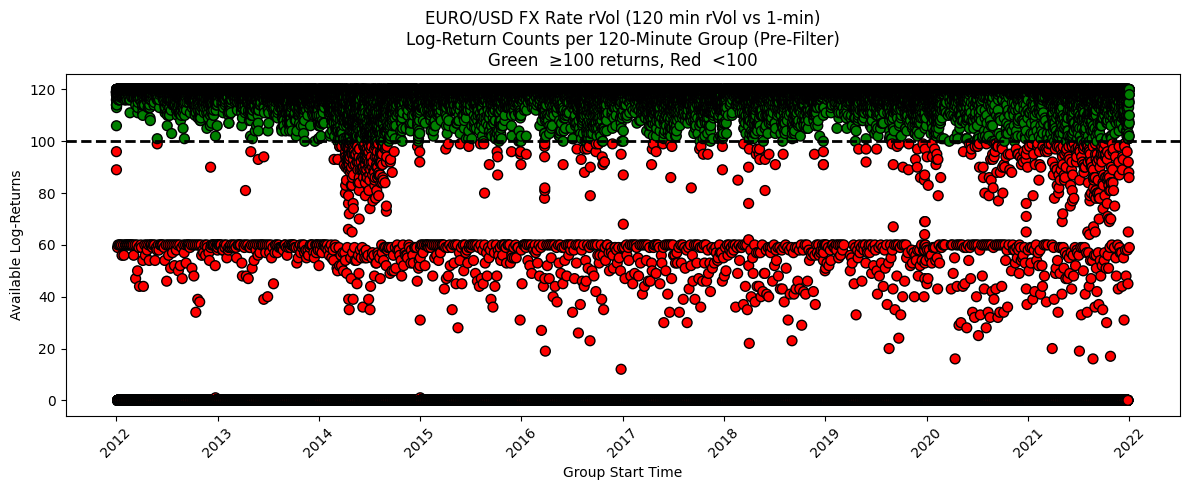

=== Diagnostics ===
Total groups:           43820
Weekday groups:         31316
Weekday groups kept:    28467
Weekday groups dropped: 2849
Percent of weekday data kept: 90.90%


C:\Users\estifo\AppData\Local\Temp\ipykernel_4088\940849678.py:167: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grp: compute_volatility_measure(grp, vol_measure))


                              sum  count
group_id                                
2012-01-02 02:00:00  2.390660e-06    119
2012-01-02 04:00:00  6.528883e-06    119
2012-01-02 06:00:00  1.139618e-06    118
2012-01-02 08:00:00  1.449495e-06    116
2012-01-02 10:00:00  9.088269e-07    114
...                           ...    ...
2021-12-31 06:00:00  1.954066e-06    120
2021-12-31 08:00:00  3.623978e-06    120
2021-12-31 10:00:00  7.476214e-06    120
2021-12-31 12:00:00  5.878490e-07    118
2021-12-31 14:00:00  3.586935e-07    110

[29979 rows x 2 columns]


C:\Users\estifo\AppData\Local\Temp\ipykernel_4088\940849678.py:382: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Prev_Close_global'].fillna(data['Open_first'], inplace=True)


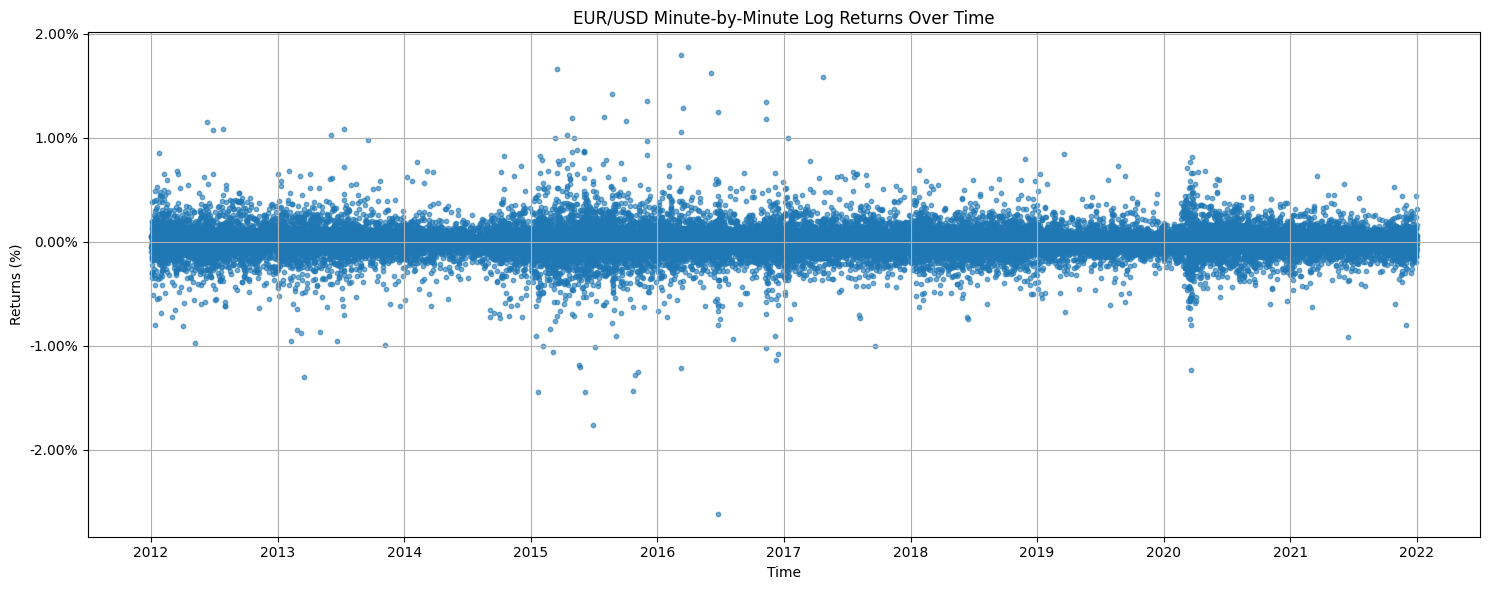

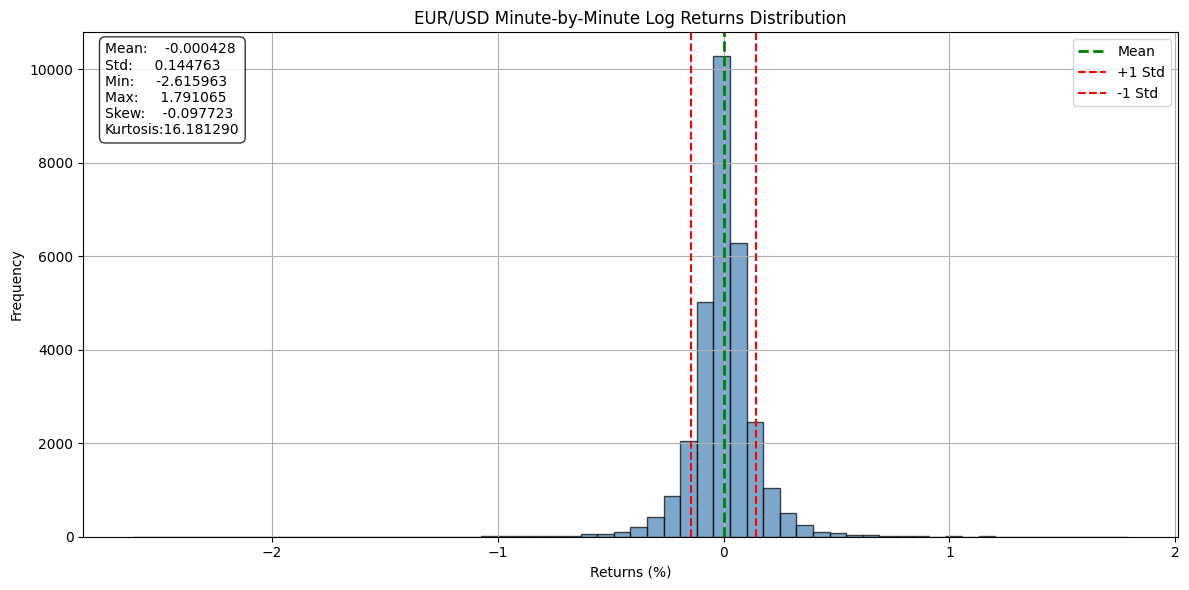

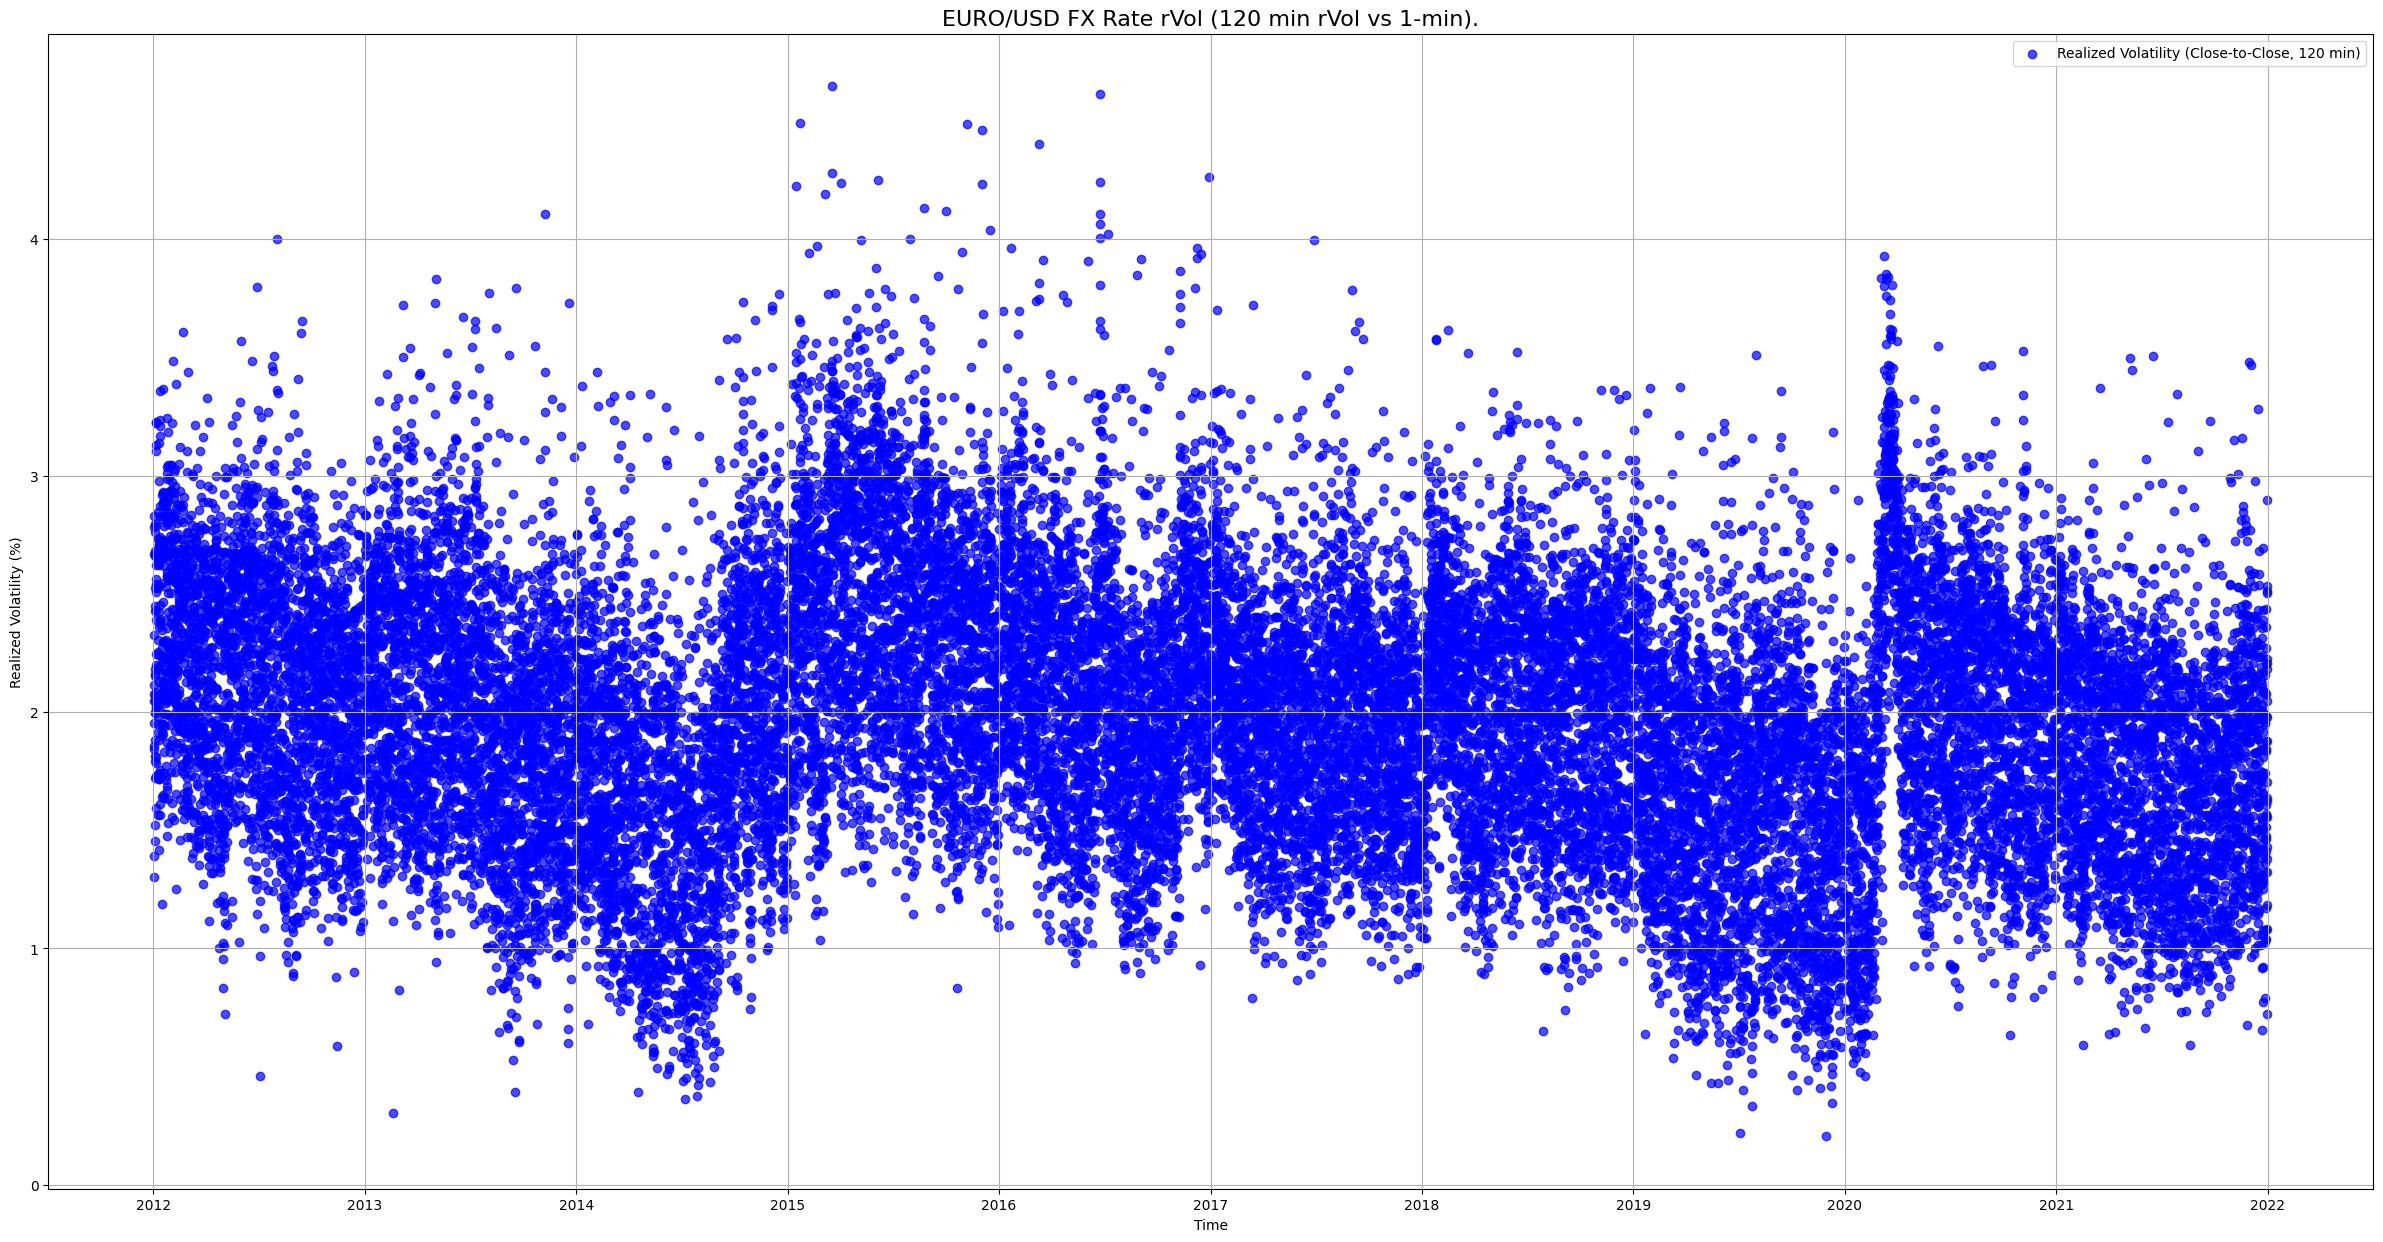

                 group_id       StartDateTime         EndDateTime  Open_first  \
0     2012-01-02 02:00:00 2012-01-02 02:00:00 2012-01-02 03:59:00     1.29324   
1     2012-01-02 04:00:00 2012-01-02 04:00:00 2012-01-02 05:59:00     1.29384   
2     2012-01-02 06:00:00 2012-01-02 06:00:00 2012-01-02 07:59:00     1.29454   
3     2012-01-02 08:00:00 2012-01-02 08:00:00 2012-01-02 09:59:00     1.29382   
4     2012-01-02 10:00:00 2012-01-02 10:00:00 2012-01-02 11:59:00     1.29325   
...                   ...                 ...                 ...         ...   
29974 2021-12-31 06:00:00 2021-12-31 06:00:00 2021-12-31 07:59:00     1.13248   
29975 2021-12-31 08:00:00 2021-12-31 08:00:00 2021-12-31 09:59:00     1.13253   
29976 2021-12-31 10:00:00 2021-12-31 10:00:00 2021-12-31 11:59:00     1.13438   
29977 2021-12-31 12:00:00 2021-12-31 12:00:00 2021-12-31 13:59:00     1.13790   
29978 2021-12-31 14:00:00 2021-12-31 14:00:00 2021-12-31 15:59:00     1.13848   

       High_max  Low_min  C

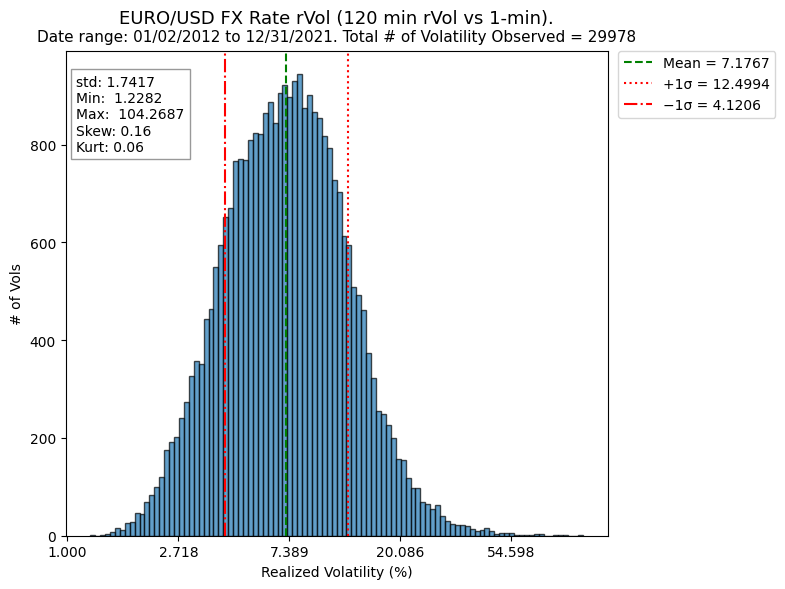

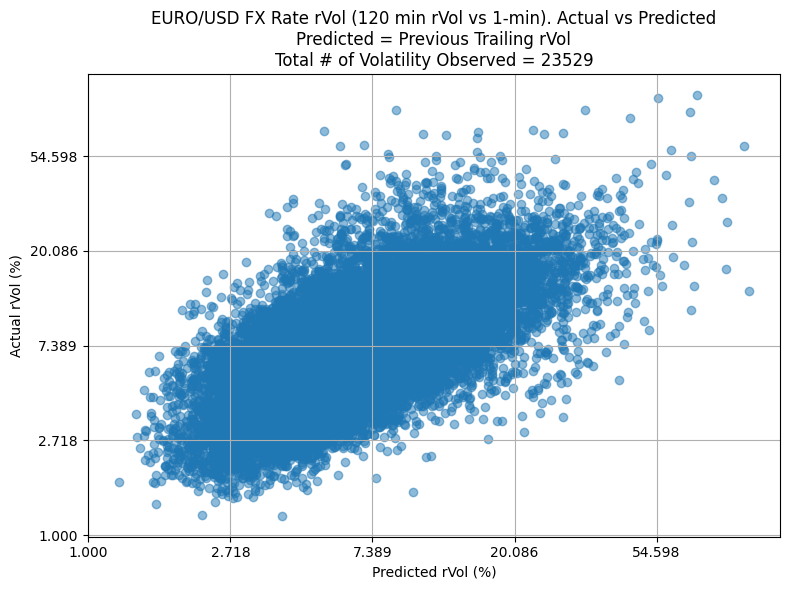

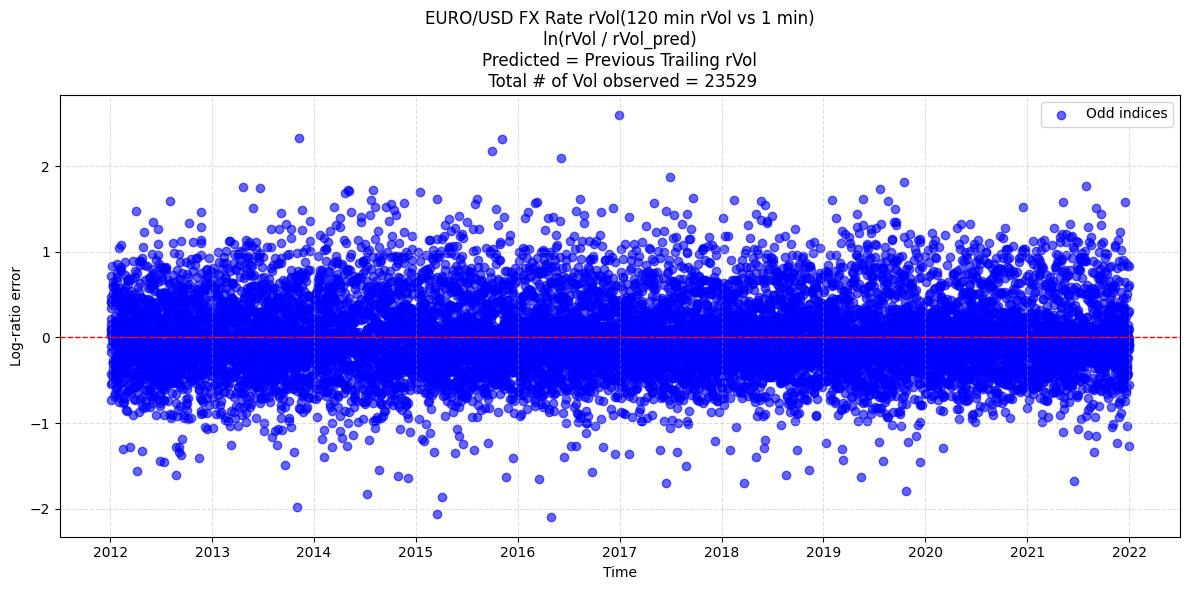

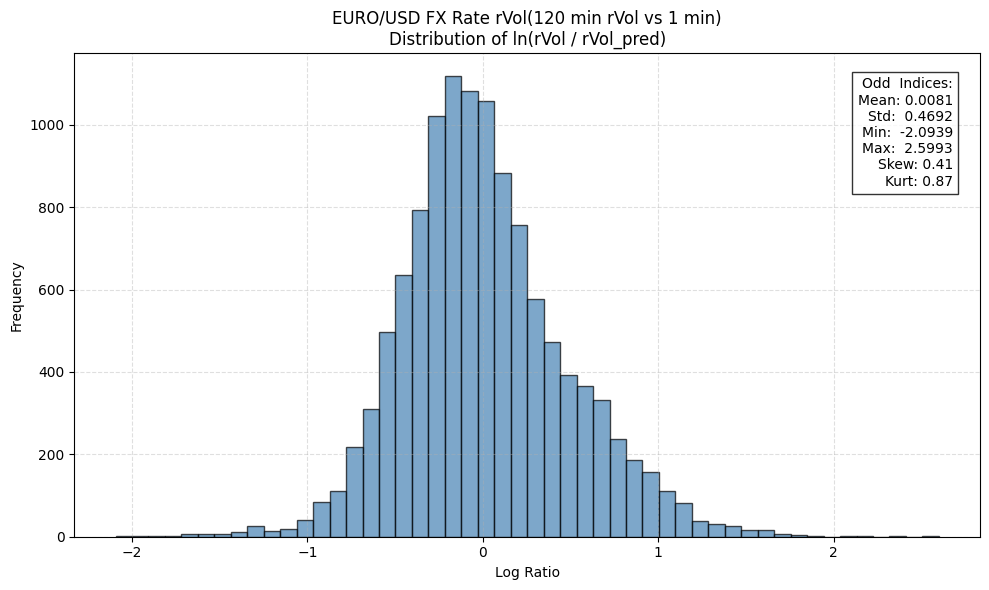

In [233]:
CC_120m_rvol = calculate_rvol(data, vol_measure = 'Close-to-Close', timeframe = 120, minute_interval = 1, threshold = 0.1667, vol_title = 'RVol_120min_Close-to-Close') # Choose 'Garman-Klass', 'Rogers-Satchell', or 'Close-to-Close'

In [234]:
CC_120m_rvol

,group_id,StartDateTime,Open_first,High_max,Low_min,Close_last,Volume_sum,indicator_sum,count,RVol_120min_Close-to-Close,Prev_Close_global,Log_Returns_global,Prev_vol
EndDateTime,,,,,,,,,,,,,
2012-01-02 03:59:00,2012-01-02 02:00:00,2012-01-02 02:00:00,1.29324,1.29531,1.29275,1.29383,0.0,1.0,119.0,10.232835,1.29324,0.000456,NaN
2012-01-02 05:59:00,2012-01-02 04:00:00,2012-01-02 04:00:00,1.29384,1.29709,1.29381,1.29457,0.0,1.0,119.0,16.910501,1.29383,0.000572,10.232835
2012-01-02 07:59:00,2012-01-02 06:00:00,2012-01-02 06:00:00,1.29454,1.29514,1.29311,1.29381,0.0,2.0,118.0,7.065073,1.29457,-0.000587,16.910501
2012-01-02 09:59:00,2012-01-02 08:00:00,2012-01-02 08:00:00,1.29382,1.29442,1.29227,1.29327,0.0,4.0,116.0,7.967928,1.29381,-0.000417,7.065073
2012-01-02 11:59:00,2012-01-02 10:00:00,2012-01-02 10:00:00,1.29325,1.29413,1.29167,1.29197,0.0,6.0,114.0,6.309249,1.29327,-0.001006,7.967928
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 07:59:00,2021-12-31 06:00:00,2021-12-31 06:00:00,1.13248,1.13349,1.13120,1.13252,0.0,0.0,120.0,9.251383,1.13248,0.000035,8.865647
2021-12-31 09:59:00,2021-12-31 08:00:00,2021-12-31 08:00:00,1.13253,1.13534,1.13191,1.13437,0.0,0.0,120.0,12.598818,1.13252,0.001632,9.251383
2021-12-31 11:59:00,2021-12-31 10:00:00,2021-12-31 10:00:00,1.13438,1.13796,1.13379,1.13790,0.0,0.0,120.0,18.095806,1.13437,0.003107,12.598818


![alt text](image.png)

In [ ]:
# Correlation plot by lag

def acf_manual(y, max_lag=None, unbiased=False):
    """
    Compute sample autocorrelation r_k for k=0..max_lag using the manual formula.
    
    Parameters
    ----------
    y : array-like, shape (N,)
        Time series values.
    max_lag : int or None
        Maximum lag to compute. Defaults to N-1 (but usually pick << N).
    unbiased : bool
        If True, divide the numerator at lag k by (N-k) instead of N during
        variance normalization (a small-sample correction). By default, uses the
        classic denominator sum_{i=1}^N (Y_i - Ybar)^2.
    
    Returns
    -------
    lags : np.ndarray of shape (max_lag+1,)
    r : np.ndarray of autocorrelations r_k
    """
    y = np.asarray(y, dtype=float).ravel()
    N = y.size
    if N < 2:
        raise ValueError("Need at least 2 observations.")
    if max_lag is None or max_lag >= N:
        max_lag = N - 1
    
    ybar = y.mean()
    denom = np.sum((y - ybar)**2)
    if denom == 0:
        # constant series -> r_k undefined except r_0=1; return zeros except r_0
        lags = np.arange(max_lag + 1)
        r = np.zeros_like(lags, dtype=float)
        r[0] = 1.0
        return lags, r
    
    r = np.empty(max_lag + 1, dtype=float)
    r[0] = 1.0
    for k in range(1, max_lag + 1):
        num = np.sum((y[:N-k] - ybar) * (y[k:] - ybar))
        if unbiased:
            # Scale to mimic unbiased auto-covariance, then normalize by variance
            r[k] = (num / (N - k)) / (denom / N)
        else:
            r[k] = num / denom
    lags = np.arange(max_lag + 1)

    return lags, r

def plot_acf_manual(y, max_lag=None, unbiased=False, title="Autocorrelation vs Lag"):
    """
    Compute and plot autocorrelation up to `max_lag` using matplotlib.
    Returns (lags, r) for further use.
    """
    lags, r = acf_manual(y, max_lag=max_lag, unbiased=unbiased)
    plt.figure()

    # Use the modern API (no deprecated args)
    plt.stem(lags, r, basefmt=" ", linefmt="C0-", markerfmt="C0o")
    
    plt.axhline(0, linewidth=1)
    N = len(np.asarray(y).ravel())
    conf = 1.96 / np.sqrt(N)
    plt.axhline(conf, linestyle="--", linewidth=1)
    plt.axhline(-conf, linestyle="--", linewidth=1)
    plt.xlabel("Lag (k)")
    plt.ylabel("Autocorrelation r_k")
    plt.title(title)
    plt.tight_layout()
    return lags, r


In [126]:
acf_manual(CC_120m_rvol['RVol_120min_Close-to-Close'], max_lag=2, unbiased=False)

(   lag
 0    0
 1    1
 2    2,
         acf
 0  1.000000
 1  0.573565
 2  0.384085)

(array([0, 1, 2, 3, 4, 5]),
 array([1.        , 0.57356516, 0.38408532, 0.30890748, 0.1398614 ,
        0.0230653 ]))

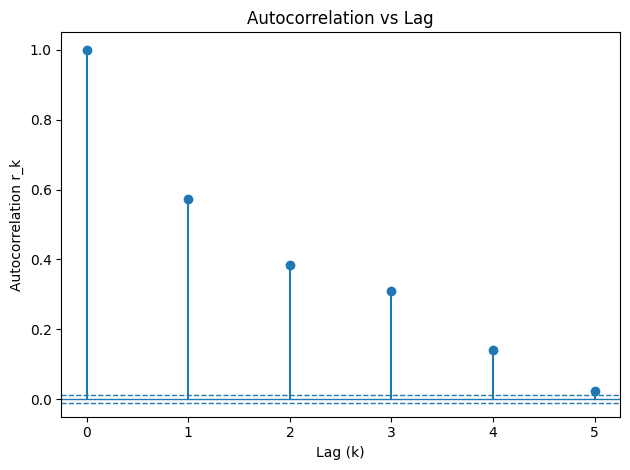

In [229]:
plot_acf_manual(CC_120m_rvol['RVol_120min_Close-to-Close'], max_lag=5, unbiased=False, title="Autocorrelation vs Lag")

In [94]:
def filter_by_hour(df, target_hour):
    """
    Filters the DataFrame by the specified hour in StartDateTime.

    Parameters:
        df (pd.DataFrame): The input DataFrame with a 'StartDateTime' column.
        target_hour (str or int): The hour to filter by (e.g., "08:00" or 8).

    Returns:
        pd.DataFrame: Filtered DataFrame containing only rows with the specified hour.
    """
    # Ensure StartDateTime is datetime type
    df['StartDateTime'] = pd.to_datetime(df['StartDateTime'])

    # Extract the hour and minute part
    if isinstance(target_hour, str) and ':' in target_hour:
        hour, minute = map(int, target_hour.split(':'))
    else:
        hour, minute = int(target_hour), 0

    # Filter rows by hour and minute
    filtered_df = df[df['StartDateTime'].dt.hour.eq(hour) & df['StartDateTime'].dt.minute.eq(minute)]

    return filtered_df


In [243]:
# Filter for 8:00 AM
df_8am = filter_by_hour(CC_120m_rvol, "08:00")
df_10am = filter_by_hour(CC_120m_rvol, "10:00")
df_12pm = filter_by_hour(CC_120m_rvol, "12:00")
# View result
df_8am.head(5)

,group_id,StartDateTime,Open_first,High_max,Low_min,Close_last,Volume_sum,indicator_sum,count,RVol_120min_Close-to-Close,Prev_Close_global,Log_Returns_global,Prev_vol
EndDateTime,,,,,,,,,,,,,
2012-01-02 09:59:00,2012-01-02 08:00:00,2012-01-02 08:00:00,1.29382,1.29442,1.29227,1.29327,0.0,4.0,116.0,7.967928,1.29381,-0.000417,7.065073
2012-01-03 09:59:00,2012-01-03 08:00:00,2012-01-03 08:00:00,1.30217,1.30460,1.30111,1.30380,0.0,0.0,120.0,11.330962,1.30220,0.001228,12.464642
2012-01-04 09:59:00,2012-01-04 08:00:00,2012-01-04 08:00:00,1.29749,1.29754,1.29310,1.29576,0.0,0.0,120.0,15.804256,1.29752,-0.001357,14.613217
2012-01-05 09:59:00,2012-01-05 08:00:00,2012-01-05 08:00:00,1.28410,1.28458,1.27834,1.28011,0.0,0.0,120.0,25.225224,1.28405,-0.003073,12.256428
2012-01-06 09:59:00,2012-01-06 08:00:00,2012-01-06 08:00:00,1.27822,1.27896,1.27047,1.27168,0.0,0.0,120.0,25.108407,1.27826,-0.005161,10.915834


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

def add_predicted_vol(df,prev_vol = "Prev_vol", vol_col='RVol_120min_Close-to-Close', alpha=0.3, decay=0.9, max_days=1): #{'alpha': 0.3, 'decay': 0.9, 'max_days': 20}
    
    '''Example
If the current time slot is 10:00 AM on July 21: decay = 0.9, max_days = 20
1. Check July 20 10:00 AM, weight = 0.9^0 = 1/sum * vol^2
2. Check July 19 10:00 AM, weight = 0.9^1 = 0.9/sum * vol^2
3. Check July 18 10:00 AM, weight = 0.9^2 = 0.8/sum * vol^2
4. ... up to 20 days back.
Take the weighted average of these volatilities.
'''
    
    
    
    
    
    df = df.copy()
    df.sort_index(inplace=True)

    # Extract time-of-day (slot ID) from StartDateTime
    df['Slot'] = df['StartDateTime'].dt.time
    df['Date'] = df['StartDateTime'].dt.date

    # Shift volatility by 1 to get previous period volatility
    df['Prev_Vol'] = df[prev_vol]

    # Container for decayed slot volatility
    decayed_slot_vols = []

    # Build a dictionary to quickly access vol by (date, slot)
    slot_vol_map = df.set_index(['Date', 'Slot'])[vol_col].to_dict()

    for idx, row in df.iterrows():
        current_date = row['Date']
        current_slot = row['Slot']
        
        slot_vol_sum = 0
        weight_sum = 0

        for n in range(1, max_days + 1):
            past_date = current_date - pd.Timedelta(days=n)
            key = (past_date, current_slot)

            if key in slot_vol_map:
                weight = decay ** (n - 1)
                slot_vol_sum += slot_vol_map[key] * weight
                weight_sum += weight

        decayed_vol = slot_vol_sum / weight_sum if weight_sum > 0 else np.nan
        decayed_slot_vols.append(decayed_vol)

    df['Decayed_Slot_Vol'] = decayed_slot_vols
    
    #Previous Day Same Slot Vol
    #df['Predicted_Var'] = df['Decayed_Slot_Vol']**2
    
    # Previous Period Vol
    #df['Predicted_Var'] = (df['Prev_Vol']**2)

    # Blend the two components
    df['Pred_Var'] = alpha * (df['Prev_Vol']**2) + (1 - alpha) * (df['Decayed_Slot_Vol']**2)
        
    # Variance -> Volatility
    df['Predicted_Vol'] = df['Pred_Var']**0.5

    return df
def generate_stability_groups(df, prev_vol, vol_col, months):
    """
    Aggregate volatility and log-ratio stability stats over fixed multi-month buckets.

    Parameters
    ----------
    df : pandas.DataFrame
        Time-indexed (DatetimeIndex) frame with columns:
        StartDateTime, EndDateTime, Open_first, High_max, Low_min, Close_last,
        Volume_sum, indicator_sum, count, and the `vol_col` provided.
    vol_col : str
        Name of the realized volatility column (e.g., 'RVol_120min_Close-to-Close').
    months : int, default 1
        Bucket size in calendar months (1=monthly, 2=every two months, 3, 4, ...).

    Returns
    -------
    pandas.DataFrame
        One row per multi-month bucket with OHLCV summaries, volatility stats, and
        log-ratio stats. Includes bucket start/end timestamps.
    """
    if not isinstance(months, int) or months < 1:
        raise ValueError("`months` must be an integer >= 1.")
    
    even_data = df.iloc[::2]
    odd_data = df.iloc[1::2]
    df = odd_data.copy()

    df = df.copy()

    # Ensure time index exists and sorted
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'EndDateTime' in df.columns:
            df = df.set_index('EndDateTime')
        elif 'StartDateTime' in df.columns:
            df = df.set_index('StartDateTime')
        else:
            raise ValueError("DataFrame must have a DatetimeIndex or a Start/EndDateTime column.")
    df = df.sort_index()

    # Previous-period vol & log-ratio
    #df['rVol_p'] = df[vol_col].shift(1)
    df['log_ratio'] = np.log(df[vol_col] / df[prev_vol])
    df = df.dropna(subset=[vol_col, 'log_ratio'])

    # (Optional thinning like your original 1::2; keep full resolution by default.)
    # df = df.iloc[1::2].copy()

    # ---- Build calendar-aligned N-month buckets anchored to January ----
    # Convert each timestamp to an absolute "month number" since year 0, then floor to bucket start.
    mnum = df.index.year * 12 + (df.index.month - 1)          # absolute month number
    bucket_start_mnum = (mnum // months) * months             # bucket start month number
    bucket_start_year = (bucket_start_mnum // 12).astype(int)
    bucket_start_month = (bucket_start_mnum % 12 + 1).astype(int)

    bucket_start = pd.to_datetime({
        'year': bucket_start_year.values,
        'month': bucket_start_month.values,
        'day': 1
    })
    # End is the last calendar day of the bucket
    bucket_end = bucket_start + pd.offsets.MonthEnd(months)

    # Attach labels
    df['Stability_group_start'] = bucket_start.values
    df['Stability_group_end']   = bucket_end.values
    # A tidy ID (PeriodIndex for the bucket start month)
    df['Stability_group_id'] = pd.PeriodIndex(df['Stability_group_start'], freq='M')

    # ---- Aggregate per bucket ----
    grouped = df.groupby(['Stability_group_start', 'Stability_group_end', 'Stability_group_id'])
    result = grouped.agg(
        StartDateTime=('StartDateTime', 'first'),
        #EndDateTime=('EndDateTime', 'last'),
        Open_first=('Open_first', 'first'),
        High_max=('High_max', 'max'),
        Low_min=('Low_min', 'min'),
        Close_last=('Close_last', 'last'),
        Volume_sum=('Volume_sum', 'sum'),
        indicator_sum=('indicator_sum', 'sum'),
        count=('count', 'sum'),
        Vol_mean=(vol_col, 'mean'),
        Vol_std=(vol_col, 'std'),
        Vol_skew=(vol_col, lambda x: skew(x, bias=False) if len(x) > 1 else np.nan),
        Vol_kurtosis=(vol_col, lambda x: kurtosis(x, bias=False) if len(x) > 1 else np.nan),
        Log_ratio_Count=('log_ratio', lambda x: x.notna().sum()),
        Log_ratio_Mean=('log_ratio', 'mean'),
        Log_ratio_Std=('log_ratio', 'std'),
        Log_ratio_Skew=('log_ratio', lambda x: skew(x, bias=False) if len(x) > 1 else np.nan),
        Log_ratio_Kurtosis=('log_ratio', lambda x: kurtosis(x, bias=False) if len(x) > 1 else np.nan),
    ).reset_index()

    # Keep a clean index keyed by the bucket start month period (nice for plotting/joins)
    result = result.set_index('Stability_group_id').sort_index()
    return result
grouped_monthly_df = generate_stability_groups(CC_120m_rvol, prev_vol = "Prev_vol", vol_col='RVol_120min_Close-to-Close', months = 1)

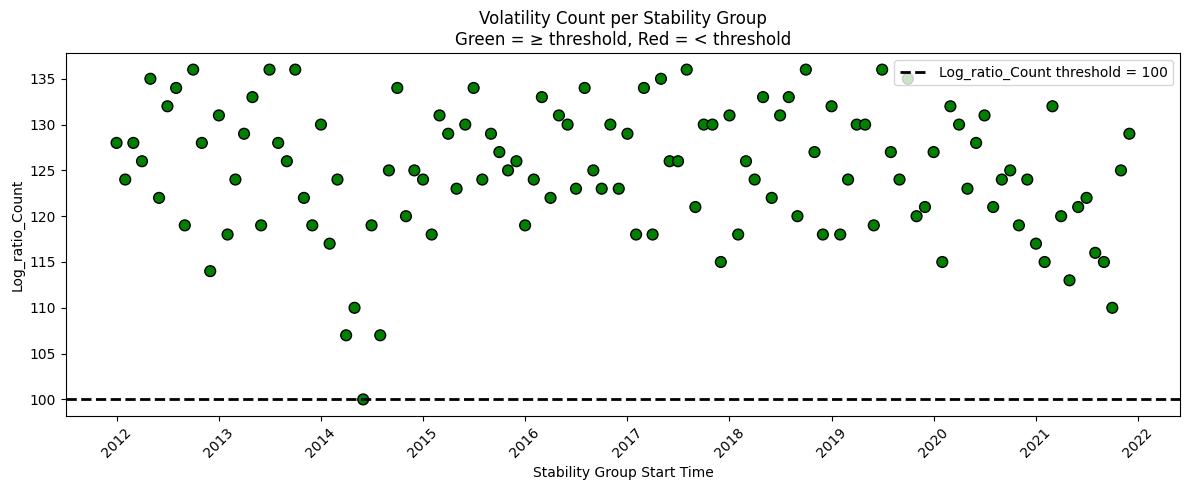

Stability_group_id
2012-01    128
2012-02    124
2012-03    128
2012-04    126
2012-05    135
          ... 
2021-08    116
2021-09    115
2021-10    110
2021-11    125
2021-12    129
Freq: M, Name: Log_ratio_Count, Length: 120, dtype: int64

In [ ]:
def plot_vol_present_scatter(df_grouped, threshold):
    """
    Plot a scatter of Log_ratio_Count per stability group.
    Green = group has enough volatility points (≥ threshold)
    Red = group has too few (< threshold)
    """
    vol_present = df_grouped["Log_ratio_Count"]
    passed = vol_present >= threshold

    plt.figure(figsize=(12, 5))
    plt.scatter(
        vol_present.index.to_timestamp(),  # <-- fix here
        vol_present.values,
        c=['green' if ok else 'red' for ok in passed],
        edgecolor='k', s=60
    )
    plt.axhline(y=threshold, color='black', linestyle='--', linewidth=2,
                label=f"Log_ratio_Count threshold = {threshold}")
    plt.xticks(rotation=45)
    plt.xlabel('Stability Group Start Time')
    plt.ylabel('Log_ratio_Count')
    plt.title('Volatility Count per Stability Group\nGreen = ≥ threshold, Red = < threshold')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    return vol_present

plot_vol_present_scatter(grouped_monthly_df, threshold=100)

In [246]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_log_rvol_ratio_statistics_filtered(df_grouped, threshold, x_col=None):
    """
    Filter groups with sufficient log-rVol ratio counts and plot mean, std dev,
    skewness, and kurtosis of ln(rVol / rVol_p) for those groups only.
    """
    # Filter groups meeting the threshold
    sufficient_data = df_grouped[df_grouped["Log_ratio_Count"] >= threshold].copy()
    if sufficient_data.empty:
        print("No groups meet the threshold.")
        return

    # Resolve x-values safely
    if x_col is not None:
        x_vals = pd.to_datetime(sufficient_data[x_col])
        x_label = x_col
    else:
        idx = sufficient_data.index
        if isinstance(idx, pd.PeriodIndex):
            x_vals = idx.to_timestamp()
        else:
            x_vals = idx
        x_label = "Stability Group Time"

    # Set up the subplots
    fig, axs = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

    # Plotting each metric (x = x_vals, y = metric)
    axs[0].scatter(x_vals, sufficient_data['Log_ratio_Mean'], s=30, color='blue')
    axs[0].set_ylabel('Mean')
    axs[0].set_title('Mean of ln(rVol / rVol_p)')

    axs[1].scatter(x_vals, sufficient_data['Log_ratio_Std'], s=30, color='orange')
    axs[1].set_ylabel('Std Dev')
    axs[1].set_title('Std Dev of ln(rVol / rVol_p)')

    axs[2].scatter(x_vals, sufficient_data['Log_ratio_Skew'], s=30, color='green')
    axs[2].set_ylabel('Skewness')
    axs[2].set_title('Skewness of ln(rVol / rVol_p)')

    axs[3].scatter(x_vals, sufficient_data['Log_ratio_Kurtosis'], s=30, color='red')
    axs[3].set_ylabel('Kurtosis')
    axs[3].set_xlabel(x_label)
    axs[3].set_title('Kurtosis of ln(rVol / rVol_p)')

    # Final layout
    plt.suptitle(f'Log-Volatility Ratio Statistics (Groups with ≥ {threshold} Log_ratio_Count)', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


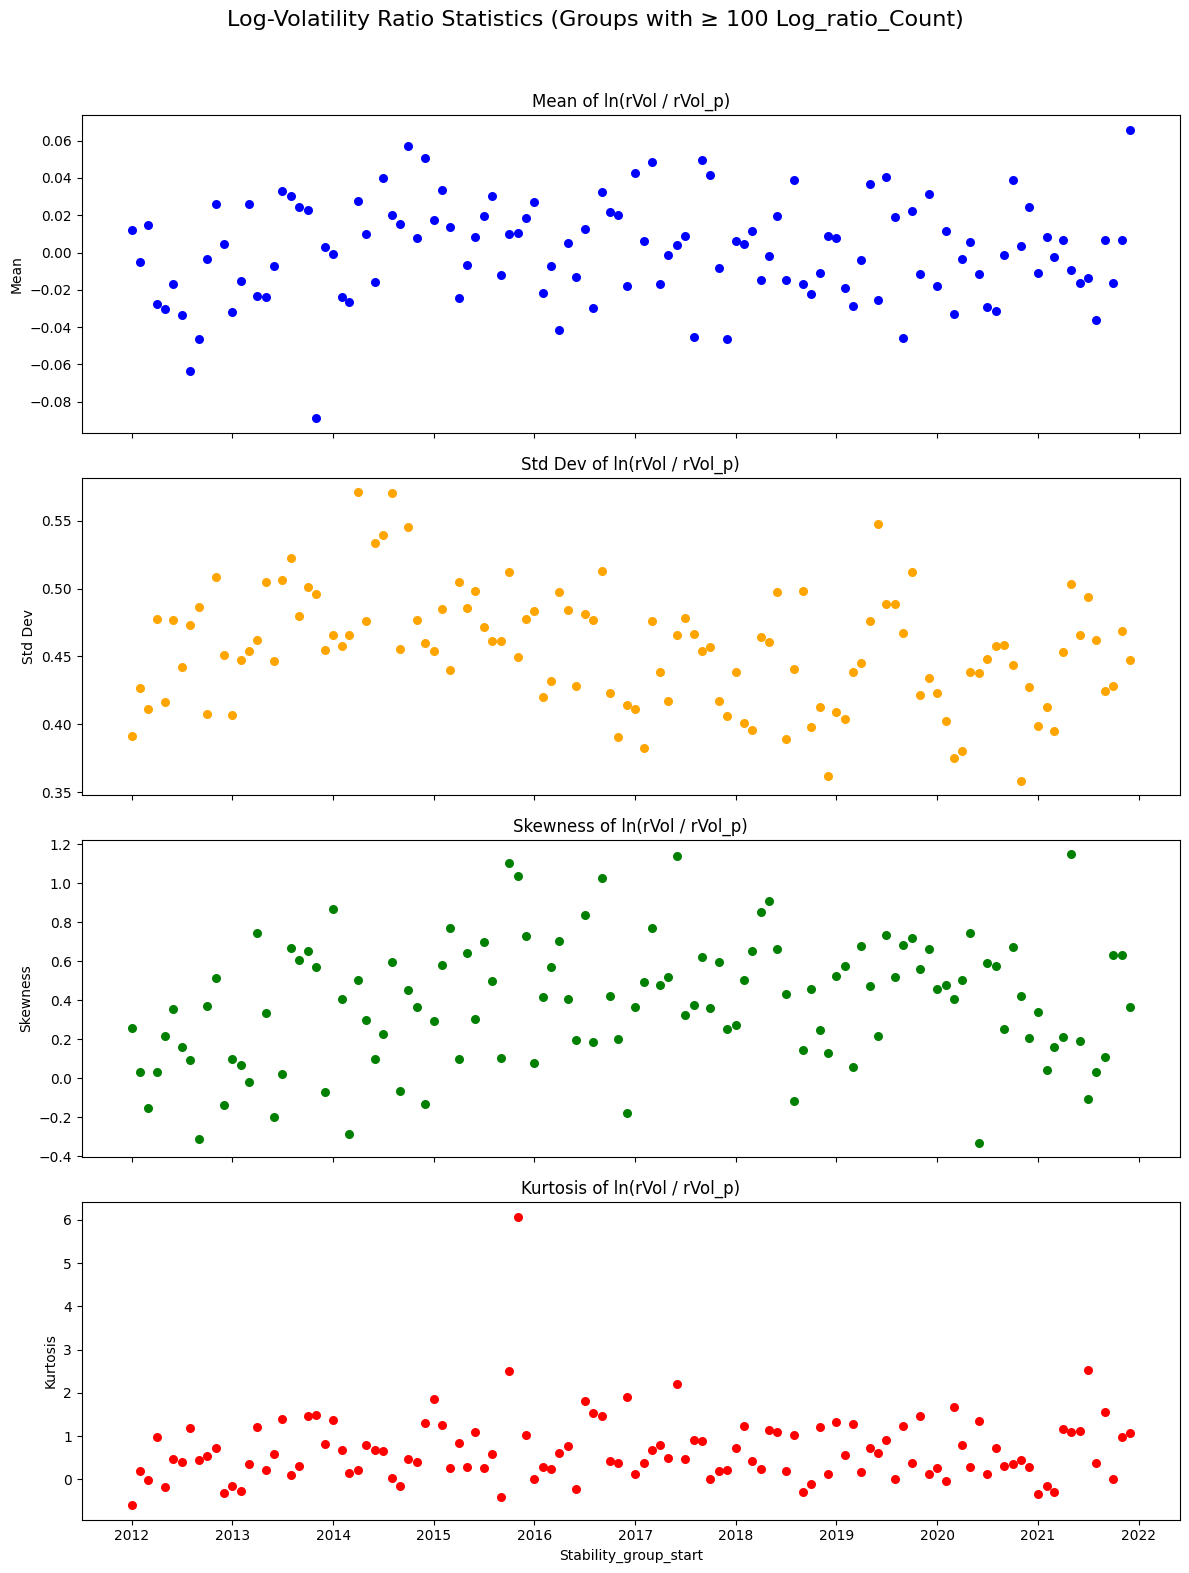

In [ ]:
plot_log_rvol_ratio_statistics_filtered(grouped_monthly_df, threshold=100, x_col='Stability_group_start')

In [103]:
import pandas as pd
import numpy as np
from itertools import product
from sklearn.metrics import r2_score
import os
#Optimization function for predicted volatility parameters
'''
def optimize_predicted_vol_params(
    df,
    vol_col='RVol_120min_Rogers-Satchell',
    alpha_range=[0.1, 0.3, 0.5, 0.7, 0.9],
    decay_range=[0.5, 0.7, 0.8, 0.9, 0.95],
    max_days_range=[5, 10, 15, 20],
    use_log=True,
    export_csv=False,
    export_path='predicted_vol_optimization_results.csv'
):
    results = []

    best_score = -np.inf
    best_params = {}

    for alpha, decay, max_days in product(alpha_range, decay_range, max_days_range):
        try:
            df_temp = add_predicted_vol(
                df.copy(),
                vol_col=vol_col,
                alpha=alpha,
                decay=decay,
                max_days=max_days
            )

            actual = df_temp[vol_col].iloc[1:]
            predicted = df_temp['Predicted_Vol'].iloc[1:]

            # Clean invalid values
            mask = (~actual.isna()) & (~predicted.isna()) & (~np.isinf(actual)) & (~np.isinf(predicted))
            actual = actual[mask]
            predicted = predicted[mask]

            if len(actual) < 20:
                continue

            if use_log:
                actual = np.log(actual)
                predicted = np.log(predicted)

            log_ratio = np.log(actual / pred)
            score = log_ratio.std()
            results.append({'alpha': alpha, 'decay': decay, 'max_days': max_days, 'std': score})

            if score > best_score:
                best_score = score
                best_params = {'alpha': alpha, 'decay': decay, 'max_days': max_days}

        except Exception as e:
            print(f"Error at α={alpha}, decay={decay}, max_days={max_days}: {e}")

    results_df = pd.DataFrame(results).sort_values(by='std', ascending=False)

    if export_csv:
        results_df.to_csv(export_path, index=False)
        print(f"\n📁 Results saved to {os.path.abspath(export_path)}")

    print("\n✅ Best Parameters Found:")
    print(best_params)
    print(f"Best std Score: {best_score:.4f}")

    return best_params, results_df  


best_params, results_df = optimize_predicted_vol_params(RS_120m_rvol)'''

'\ndef optimize_predicted_vol_params(\n    df,\n    vol_col=\'RVol_120min_Rogers-Satchell\',\n    alpha_range=[0.1, 0.3, 0.5, 0.7, 0.9],\n    decay_range=[0.5, 0.7, 0.8, 0.9, 0.95],\n    max_days_range=[5, 10, 15, 20],\n    use_log=True,\n    export_csv=False,\n    export_path=\'predicted_vol_optimization_results.csv\'\n):\n    results = []\n\n    best_score = -np.inf\n    best_params = {}\n\n    for alpha, decay, max_days in product(alpha_range, decay_range, max_days_range):\n        try:\n            df_temp = add_predicted_vol(\n                df.copy(),\n                vol_col=vol_col,\n                alpha=alpha,\n                decay=decay,\n                max_days=max_days\n            )\n\n            actual = df_temp[vol_col].iloc[1:]\n            predicted = df_temp[\'Predicted_Vol\'].iloc[1:]\n\n            # Clean invalid values\n            mask = (~actual.isna()) & (~predicted.isna()) & (~np.isinf(actual)) & (~np.isinf(predicted))\n            actual = actual[mask]\n

In [104]:
import numpy as np
import pandas as pd
#Hest Model Calibration and Forecasting
'''
def calibrate_and_forecast_heston_2h(realized_vol_series, returns_2h, forecast_horizon=120, 
                                     num_sims=10000, ci=[5, 50, 95]):
    """
    Calibrate Heston parameters using 2-hour realized volatility and returns,
    then forecast the next 120-min realized volatility (rVol).
    
    Parameters
    ----------
    realized_vol_series : pd.Series
        2-hour realized volatility (aligned with returns).
    returns_2h : pd.Series
        2-hour log returns aligned with realized_vol_series.
    forecast_horizon : int, default=120
        Forecast horizon in minutes (default = 120 min).
    num_sims : int, default=10000
        Number of Monte Carlo simulations for rVol forecast.
    ci : list, default=[5, 50, 95]
        Percentile confidence intervals to return from Monte Carlo forecast.
    
    Returns
    -------
    dict
        Dictionary containing:
        - Calibrated parameters
        - Analytical forecast (expected rVol)
        - Monte Carlo forecast (distribution and CIs)
    """
    
    # ---- Step 1: Calibration ----
    dt = 1#(2 / 60) / (6.5 * 252)  # 2-hour step in fraction of a trading year
    
    v = (realized_vol_series/100)**2
    v = v.dropna()
    
    delta_v = v.shift(-1) - v
    valid_idx = delta_v.dropna().index
    
    # OLS regression to estimate kappa and theta
    X = np.vstack([np.ones(len(valid_idx)), v.loc[valid_idx]]).T
    y = delta_v.loc[valid_idx].values
    A, B = np.linalg.lstsq(X, y, rcond=None)[0]
    
    kappa = -B / dt
    theta = A / (kappa * dt)
    
    # Vol of vol
    residuals = y - (A + B * v.loc[valid_idx])
    sigma = np.sqrt(np.var(residuals) / (dt * np.mean(v.loc[valid_idx])))
    
    # Rho: correlation between returns and variance shocks
    returns_2h = returns_2h.reindex(v.index).dropna()
    rho = np.corrcoef(returns_2h.loc[valid_idx], residuals)[0, 1]
    
    # Initial variance
    v0 = v.iloc[-1]
    
    params = {
        'kappa': float(kappa),
        'theta': float(theta),
        'sigma': float(sigma),
        'rho': float(rho),
        'v0': float(v0)
    }
    
    # ---- Step 2: Analytical forecast ----
    steps = forecast_horizon // 120  # since variance is 2-hour frequency, steps = 1
    v_exp = theta + (v0 - theta) * np.exp(-kappa * steps)
    rvol_forecast_analytical = np.sqrt(v_exp * steps)
    
    # ---- Step 3: Monte Carlo forecast ----
    v_sim = np.full(num_sims, v0)
    rvol_sims = []
    
    for step in range(steps):
        z = np.random.randn(num_sims)
        v_sim = np.maximum(
            v_sim + kappa * (theta - v_sim) * dt + sigma * np.sqrt(v_sim * dt) * z,
            1e-12  # avoid negative variance
        )
        rvol_sims.append(np.sqrt(v_sim))
    
    rvol_forecast_mc = np.sum(rvol_sims, axis=0)
    mc_percentiles = np.percentile(rvol_forecast_mc, ci)
    
    return {
        'params': params,
        'analytical_forecast': rvol_forecast_analytical,
        'monte_carlo_forecast': {
            'simulations': rvol_forecast_mc,
            'percentiles': dict(zip(ci, mc_percentiles))
        }
    }
'''

'\ndef calibrate_and_forecast_heston_2h(realized_vol_series, returns_2h, forecast_horizon=120, \n                                     num_sims=10000, ci=[5, 50, 95]):\n    """\n    Calibrate Heston parameters using 2-hour realized volatility and returns,\n    then forecast the next 120-min realized volatility (rVol).\n    \n    Parameters\n    ----------\n    realized_vol_series : pd.Series\n        2-hour realized volatility (aligned with returns).\n    returns_2h : pd.Series\n        2-hour log returns aligned with realized_vol_series.\n    forecast_horizon : int, default=120\n        Forecast horizon in minutes (default = 120 min).\n    num_sims : int, default=10000\n        Number of Monte Carlo simulations for rVol forecast.\n    ci : list, default=[5, 50, 95]\n        Percentile confidence intervals to return from Monte Carlo forecast.\n    \n    Returns\n    -------\n    dict\n        Dictionary containing:\n        - Calibrated parameters\n        - Analytical forecast (expecte

In [ ]:
from scipy.optimize import minimize
def std_log_ratio_objective_single_alpha(params, prev_vol, df, vol_col, max_days):
    # params contains [alpha, decay]
    alpha, decay = params

    # Hard-guard the domain so numdiff doesn't hit NaNs on finite-difference
    if not (0 < alpha < 1) or not (0 < decay < 1):
        return np.inf

    try:
        df_temp = add_predicted_vol(
            df.copy(),
            prev_vol=prev_vol,          # <- pass the column name here
            vol_col=vol_col,
            alpha=alpha,
            decay=decay,
            max_days=max_days
        )

        actual = df_temp[vol_col]
        pred   = df_temp['Predicted_Vol']

        # Clean/alignment
        m = actual.notna() & pred.notna() & np.isfinite(actual) & np.isfinite(pred) & (pred > 0)
        if m.sum() < 2:
            return np.inf

        log_ratio = np.log(actual[m] / pred[m])
        s = float(log_ratio.std())
        if not np.isfinite(s):
            return np.inf
        return s

    except Exception:
        return np.inf


In [178]:
def optimize_params_on_group(df_group, prev_vol, vol_col='RVol_120min_Close-to-Close', max_days=2):
    from scipy.optimize import minimize
    import numpy as np

    def obj(params):
        return std_log_ratio_objective_single_alpha(params, prev_vol, df_group, vol_col, max_days)

    result = minimize(
        obj,
        x0=np.array([0.3, 0.85], dtype=float),
        bounds=[(1e-4, 0.9999), (1e-4, 0.9999)],
        method='L-BFGS-B'
    )
    if result.success and np.isfinite(result.fun):
        alpha, decay = result.x
        return float(alpha), float(decay), float(result.fun)
    return np.nan, np.nan, np.nan

#def optimize_params_on_group(df_group, prev_vol, vol_col='RVol_120min_Close-to-Close', max_days=2):
    from scipy.optimize import minimize

    def obj(params):
        alpha, decay = params
        return std_log_ratio_objective_fixed_max_days(params, prev_vol,  df_group, vol_col, decay,  max_days)

    result = minimize(
        obj,
        x0=(0.3, 0.85),
        bounds=[(0.01, 0.99), (0.01, 0.999)],
        method='L-BFGS-B'
    )
    
    if result.success:
        return result.x[0], result.x[1], result.fun
    else:
        return np.nan, np.nan, np.nan


In [ ]:
def rolling_stability_backtest(
    full_df,
    prev_vol="Prev_vol",
    vol_col="RVol_120min_Close-to-Close",
    months=1,
    max_days=1,
    anchor="calendar"  # "calendar" (Jan-anchored) or "data_start" (anchored to first timestamp)
):
    """
    Rolling backtest over fixed multi-month calendar buckets.

    Parameters
    ----------
    full_df : pd.DataFrame
        Time-indexed (DatetimeIndex) data with columns needed by your pipeline
        (StartDateTime, EndDateTime, OHLC, Volume_sum, indicator_sum, count, prev_vol, vol_col, ...).
    prev_vol : str
        Column name for previous-period volatility (e.g., "Prev_vol").
    vol_col : str
        Column name for realized volatility (target) (e.g., 'RVol_120min_Close-to-Close').
    months : int
        Bucket size in calendar months (1=monthly, 2=every two months, 3, 4, ...).
    max_days : int
        Number of days to look back for the decayed same-slot history in add_predicted_vol.
        (Note: if max_days=1, decay is effectively irrelevant.)
    anchor : {"calendar", "data_start"}
        - "calendar": buckets are aligned to January (e.g., months=3 -> Jan–Mar, Apr–Jun, ...).
        - "data_start": buckets are aligned to the first timestamp in the data.

    Returns
    -------
    pd.DataFrame
        One row per train/test pair with alpha, decay, and log-ratio stds for train & test.
    """
    if not isinstance(months, int) or months < 1:
        raise ValueError("`months` must be an integer >= 1.")

    df = full_df.copy()

    # Ensure we have a DatetimeIndex
    if not isinstance(df.index, pd.DatetimeIndex):
        if "EndDateTime" in df.columns:
            df = df.set_index("EndDateTime")
        elif "StartDateTime" in df.columns:
            df = df.set_index("StartDateTime")
        else:
            raise ValueError("DataFrame must have a DatetimeIndex or a Start/EndDateTime column.")
    df = df.sort_index()

    # Build multi-month bucket starts (vectorized)
    mnum = df.index.year * 12 + (df.index.month - 1)  # absolute month number

    if anchor == "calendar":
        bucket_start_mnum = (mnum // months) * months
    elif anchor == "data_start":
        # Shift so the first timestamp is bucket-aligned
        first_mnum = int(mnum.min())
        bucket_start_mnum = ((mnum - first_mnum) // months) * months + first_mnum
    else:
        raise ValueError("anchor must be 'calendar' or 'data_start'.")

    bucket_start_year = (bucket_start_mnum // 12).astype(int)
    bucket_start_month = (bucket_start_mnum % 12 + 1).astype(int)

    bucket_start = pd.to_datetime(
        {"year": bucket_start_year.values, "month": bucket_start_month.values, "day": 1}
    )
    bucket_end = bucket_start + pd.offsets.MonthEnd(months)

    df["Stability_group_start"] = bucket_start.values
    df["Stability_group_end"] = bucket_end.values

    # Use the bucket start timestamp as the group ID
    df["Stability_group_id"] = df["Stability_group_start"]

    # Gather all unique, ordered group ids
    group_ids = np.sort(df["Stability_group_id"].unique())

    results = []
    for i in range(len(group_ids) - 1):
        train_id = group_ids[i]
        test_id  = group_ids[i + 1]

        train_mask = df["Stability_group_id"] == train_id
        test_mask  = df["Stability_group_id"] == test_id

        train_data = df.loc[train_mask]
        test_data  = df.loc[test_mask]

        # Optimize on training data
        alpha, decay, train_std = optimize_params_on_group(
            train_data, prev_vol, vol_col=vol_col, max_days=max_days
        )

        if not np.isfinite(alpha):
            # Skip if optimization failed
            continue

        # Apply to test data and measure generalization
        try:
            test_copy = test_data.copy()
            test_copy = add_predicted_vol(
                test_copy, prev_vol=prev_vol, vol_col=vol_col,
                alpha=alpha, decay=decay, max_days=max_days
            )
            test_copy["log_ratio"] = np.log(test_copy[vol_col] / test_copy["Predicted_Vol"])
            # Clean invalids
            m = test_copy["log_ratio"].replace([np.inf, -np.inf], np.nan).dropna()
            test_log_std = float(m.std()) if len(m) > 1 else np.nan
        except Exception:
            test_log_std = np.nan

        results.append({
            "Train_Group_ID": pd.Timestamp(train_id),
            "Test_Group_ID": pd.Timestamp(test_id),
            "months": months,
            "anchor": anchor,
            "alpha": float(alpha),
            "decay": float(decay),
            "max_days": int(max_days),
            "Train_LogRatio_Std": float(train_std) if np.isfinite(train_std) else np.nan,
            "Test_LogRatio_Std": test_log_std
        })

    return pd.DataFrame(results)


In [284]:
df_8am.head(5)

,group_id,StartDateTime,Open_first,High_max,Low_min,Close_last,Volume_sum,indicator_sum,count,RVol_120min_Close-to-Close,Prev_Close_global,Log_Returns_global,Prev_vol
EndDateTime,,,,,,,,,,,,,
2012-01-02 09:59:00,2012-01-02 08:00:00,2012-01-02 08:00:00,1.29382,1.29442,1.29227,1.29327,0.0,4.0,116.0,7.967928,1.29381,-0.000417,7.065073
2012-01-03 09:59:00,2012-01-03 08:00:00,2012-01-03 08:00:00,1.30217,1.30460,1.30111,1.30380,0.0,0.0,120.0,11.330962,1.30220,0.001228,12.464642
2012-01-04 09:59:00,2012-01-04 08:00:00,2012-01-04 08:00:00,1.29749,1.29754,1.29310,1.29576,0.0,0.0,120.0,15.804256,1.29752,-0.001357,14.613217
2012-01-05 09:59:00,2012-01-05 08:00:00,2012-01-05 08:00:00,1.28410,1.28458,1.27834,1.28011,0.0,0.0,120.0,25.225224,1.28405,-0.003073,12.256428
2012-01-06 09:59:00,2012-01-06 08:00:00,2012-01-06 08:00:00,1.27822,1.27896,1.27047,1.27168,0.0,0.0,120.0,25.108407,1.27826,-0.005161,10.915834


In [ ]:
def Generate_stability_groups(df, prev_vol, vol_col, months):
    """
    Aggregate volatility and log-ratio stability stats over fixed multi-month buckets.

    Parameters
    ----------
    df : pandas.DataFrame
        Time-indexed (DatetimeIndex) frame with columns:
        StartDateTime, EndDateTime, Open_first, High_max, Low_min, Close_last,
        Volume_sum, indicator_sum, count, and the `vol_col` provided.
    vol_col : str
        Name of the realized volatility column (e.g., 'RVol_120min_Close-to-Close').
    months : int, default 1
        Bucket size in calendar months (1=monthly, 2=every two months, 3, 4, ...).

    Returns
    -------
    pandas.DataFrame
        One row per multi-month bucket with OHLCV summaries, volatility stats, and
        log-ratio stats. Includes bucket start/end timestamps.
    """
    if not isinstance(months, int) or months < 1:
        raise ValueError("`months` must be an integer >= 1.")
    
    '''
    even_data = df.iloc[::2]
    odd_data = df.iloc[1::2]
    df = odd_data.copy()'''

    df = df.copy()

    # Ensure time index exists and sorted
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'EndDateTime' in df.columns:
            df = df.set_index('EndDateTime')
        elif 'StartDateTime' in df.columns:
            df = df.set_index('StartDateTime')
        else:
            raise ValueError("DataFrame must have a DatetimeIndex or a Start/EndDateTime column.")
    df = df.sort_index()

    # Previous-period vol & log-ratio
    #df['rVol_p'] = df[vol_col].shift(1)
    df['log_ratio'] = np.log(df[vol_col] / df[prev_vol])
    df = df.dropna(subset=[vol_col, 'log_ratio'])

    # (Optional thinning like your original 1::2; keep full resolution by default.)
    # df = df.iloc[1::2].copy()

    # ---- Build calendar-aligned N-month buckets anchored to January ----
    # Convert each timestamp to an absolute "month number" since year 0, then floor to bucket start.
    mnum = df.index.year * 12 + (df.index.month - 1)          # absolute month number
    bucket_start_mnum = (mnum // months) * months             # bucket start month number
    bucket_start_year = (bucket_start_mnum // 12).astype(int)
    bucket_start_month = (bucket_start_mnum % 12 + 1).astype(int)

    bucket_start = pd.to_datetime({
        'year': bucket_start_year.values,
        'month': bucket_start_month.values,
        'day': 1
    })
    # End is the last calendar day of the bucket
    bucket_end = bucket_start + pd.offsets.MonthEnd(months)

    # Attach labels
    df['Stability_group_start'] = bucket_start.values
    df['Stability_group_end']   = bucket_end.values
    # A tidy ID (PeriodIndex for the bucket start month)
    df['Stability_group_id'] = pd.PeriodIndex(df['Stability_group_start'], freq='M')

    # ---- Aggregate per bucket ----
    grouped = df.groupby(['Stability_group_start', 'Stability_group_end', 'Stability_group_id'])
    result = grouped.agg(
        StartDateTime=('StartDateTime', 'first'),
        #EndDateTime=('EndDateTime', 'last'),
        Open_first=('Open_first', 'first'),
        High_max=('High_max', 'max'),
        Low_min=('Low_min', 'min'),
        Close_last=('Close_last', 'last'),
        Volume_sum=('Volume_sum', 'sum'),
        indicator_sum=('indicator_sum', 'sum'),
        count=('count', 'sum'),
        Vol_mean=(vol_col, 'mean'),
        Vol_std=(vol_col, 'std'),
        Vol_skew=(vol_col, lambda x: skew(x, bias=False) if len(x) > 1 else np.nan),
        Vol_kurtosis=(vol_col, lambda x: kurtosis(x, bias=False) if len(x) > 1 else np.nan),
        Log_ratio_Count=('log_ratio', lambda x: x.notna().sum()),
        Log_ratio_Mean=('log_ratio', 'mean'),
        Log_ratio_Std=('log_ratio', 'std'),
        Log_ratio_Skew=('log_ratio', lambda x: skew(x, bias=False) if len(x) > 1 else np.nan),
        Log_ratio_Kurtosis=('log_ratio', lambda x: kurtosis(x, bias=False) if len(x) > 1 else np.nan),
    ).reset_index()

    # Keep a clean index keyed by the bucket start month period (nice for plotting/joins)
    result = result.set_index('Stability_group_id').sort_index()
    return result

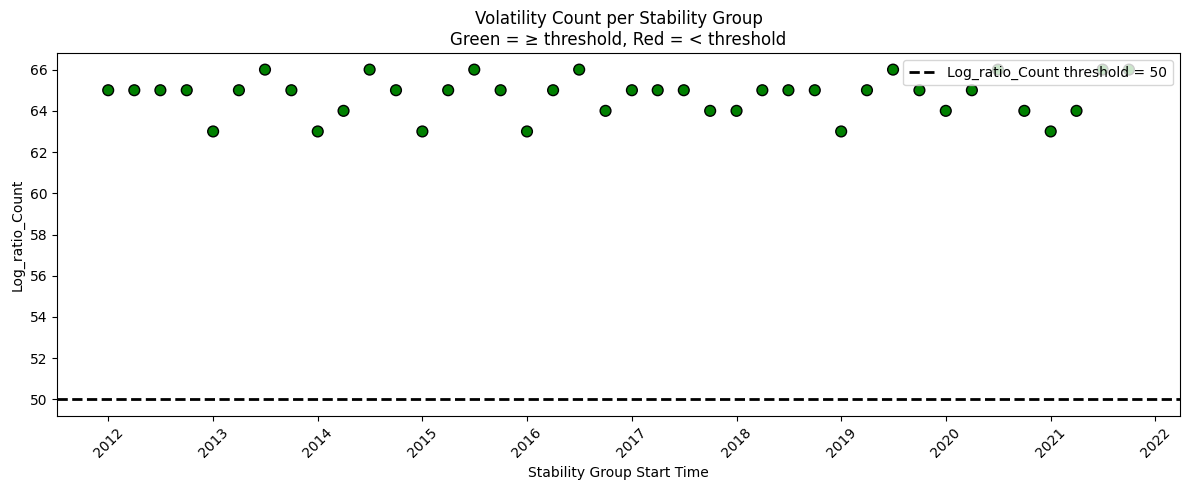

Stability_group_id
2012-01    65
2012-04    65
2012-07    65
2012-10    65
2013-01    63
2013-04    65
2013-07    66
2013-10    65
2014-01    63
2014-04    64
2014-07    66
2014-10    65
2015-01    63
2015-04    65
2015-07    66
2015-10    65
2016-01    63
2016-04    65
2016-07    66
2016-10    64
2017-01    65
2017-04    65
2017-07    65
2017-10    64
2018-01    64
2018-04    65
2018-07    65
2018-10    65
2019-01    63
2019-04    65
2019-07    66
2019-10    65
2020-01    64
2020-04    65
2020-07    66
2020-10    64
2021-01    63
2021-04    64
2021-07    66
2021-10    66
Freq: M, Name: Log_ratio_Count, dtype: int64

In [ ]:
grouped_Monthly_df = Generate_stability_groups(df_10am, prev_vol = "Prev_vol", vol_col='RVol_120min_Close-to-Close', months = 3)
plot_vol_present_scatter(grouped_Monthly_df, threshold=50)

In [283]:
backtest_df = rolling_stability_backtest(df_10am, prev_vol = "Prev_vol",vol_col='RVol_120min_Close-to-Close', months = 3, max_days=1, anchor="calendar")
backtest_df[['Train_Group_ID', 'Test_Group_ID', 'alpha', 'max_days', 'Train_LogRatio_Std', 'Test_LogRatio_Std']].head(5) # the decay is constant (insignificant if max days is = 1)

,Train_Group_ID,Test_Group_ID,alpha,max_days,Train_LogRatio_Std,Test_LogRatio_Std
0,2012-01-01,2012-04-01,0.396713,1,0.247986,0.291607
1,2012-04-01,2012-07-01,0.162001,1,0.284952,0.261102
2,2012-07-01,2012-10-01,0.167240,1,0.261092,0.229848
3,2012-10-01,2013-01-01,0.352916,1,0.222242,0.295255
4,2013-01-01,2013-04-01,0.241620,1,0.292446,0.365182


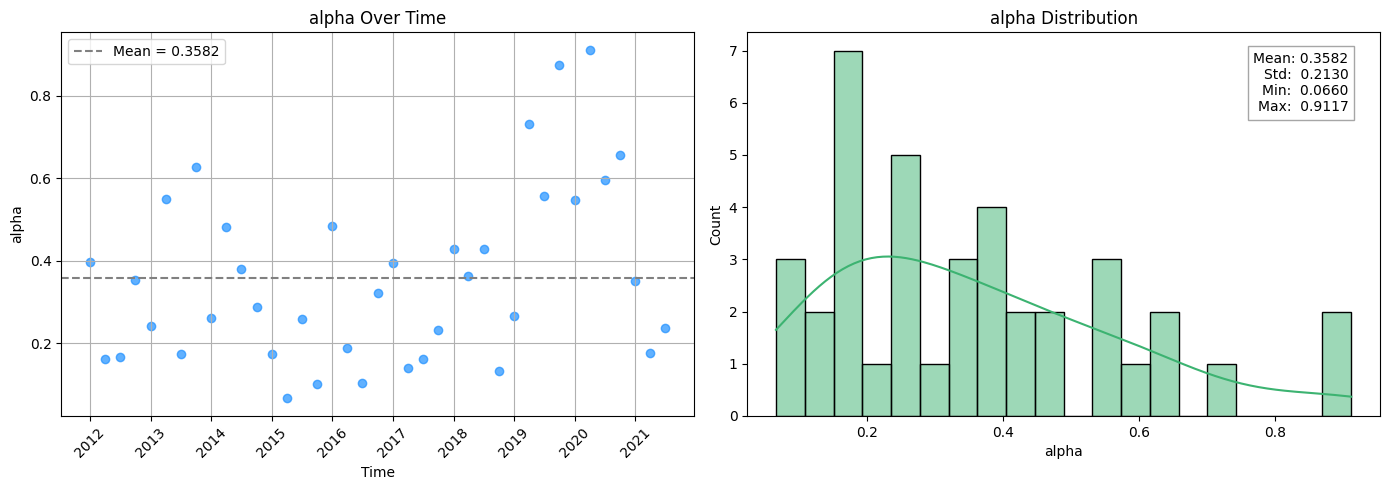

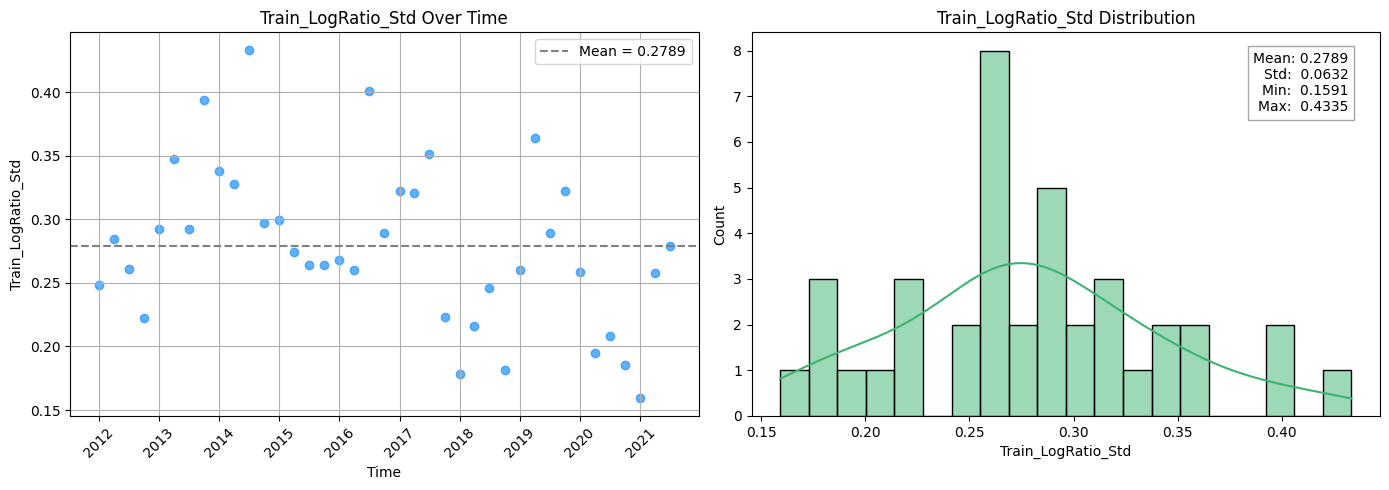

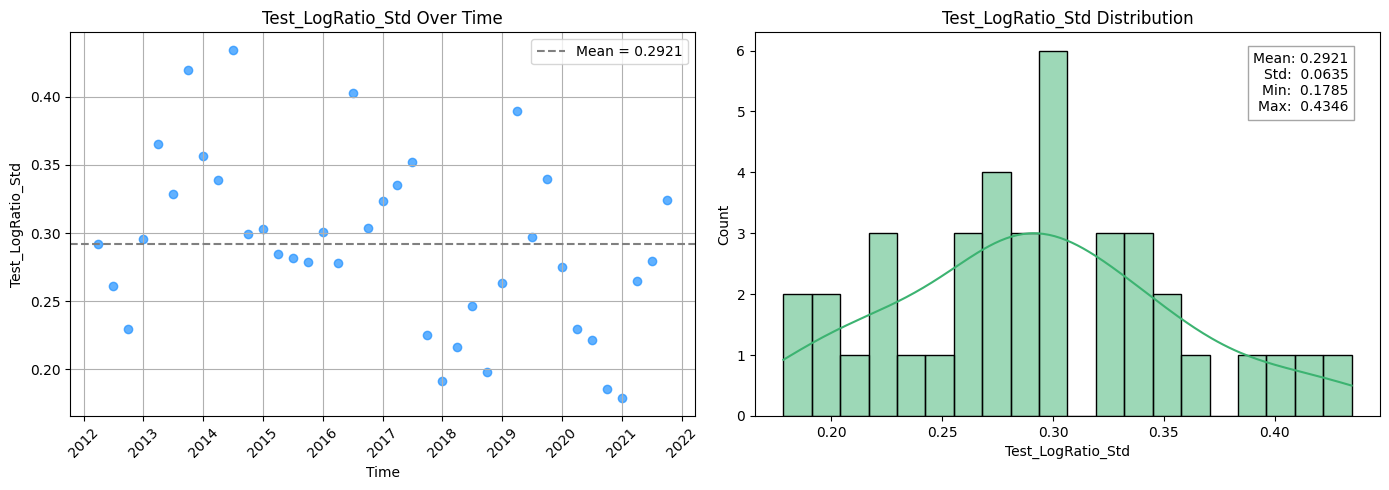

In [281]:
def plot_scatter_and_distribution(df, column, time_col='Train_Group_ID', title=None):
    series = df[column].dropna()

    # Compute stats
    mean_val = series.mean()
    std_val  = series.std()
    min_val  = series.min()
    max_val  = series.max()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Scatter over time
    axes[0].scatter(df[time_col], df[column], alpha=0.7, color='dodgerblue')
    axes[0].axhline(mean_val, color='gray', linestyle='--', label=f"Mean = {mean_val:.4f}")
    axes[0].set_title(f"{column} Over Time")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel(column)
    axes[0].legend()
    axes[0].grid(True)
    axes[0].tick_params(axis='x', rotation=45)

    # 2. Distribution with stats
    sns.histplot(series, bins=20, kde=True, ax=axes[1], color='mediumseagreen', edgecolor='black')
    axes[1].set_title(f"{column} Distribution")

    stats_text = (
        f"Mean: {mean_val:.4f}\n"
        f"Std:  {std_val:.4f}\n"
        f"Min:  {min_val:.4f}\n"
        f"Max:  {max_val:.4f}"
    )
    axes[1].text(0.95, 0.95, stats_text, transform=axes[1].transAxes,
                 fontsize=10, va='top', ha='right',
                 bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7))

    plt.tight_layout()
    if title:
        plt.suptitle(title, fontsize=14, y=1.05)
    plt.show()

plot_scatter_and_distribution(backtest_df, 'alpha', time_col='Train_Group_ID')
#plot_scatter_and_distribution(backtest_df, 'decay', time_col='Train_Group_ID')
plot_scatter_and_distribution(backtest_df, 'Train_LogRatio_Std', time_col='Train_Group_ID')
plot_scatter_and_distribution(backtest_df, 'Test_LogRatio_Std', time_col='Test_Group_ID')

In [ ]:
stop()

NameError: name 'stop' is not defined

In [ ]:
CC_120m_rvol.head(5)

,group_id,StartDateTime,Open_first,High_max,Low_min,Close_last,Volume_sum,indicator_sum,count,RVol_120min_Close-to-Close,Prev_Close_global,Log_Returns_global
EndDateTime,,,,,,,,,,,,
2012-01-02 03:59:00,2012-01-02 02:00:00,2012-01-02 02:00:00,1.29324,1.29531,1.29275,1.29383,0.0,1.0,119.0,10.232835,1.29324,0.000456
2012-01-02 05:59:00,2012-01-02 04:00:00,2012-01-02 04:00:00,1.29384,1.29709,1.29381,1.29457,0.0,1.0,119.0,16.910501,1.29383,0.000572
2012-01-02 07:59:00,2012-01-02 06:00:00,2012-01-02 06:00:00,1.29454,1.29514,1.29311,1.29381,0.0,2.0,118.0,7.065073,1.29457,-0.000587
2012-01-02 09:59:00,2012-01-02 08:00:00,2012-01-02 08:00:00,1.29382,1.29442,1.29227,1.29327,0.0,4.0,116.0,7.967928,1.29381,-0.000417
2012-01-02 11:59:00,2012-01-02 10:00:00,2012-01-02 10:00:00,1.29325,1.29413,1.29167,1.29197,0.0,6.0,114.0,6.309249,1.29327,-0.001006


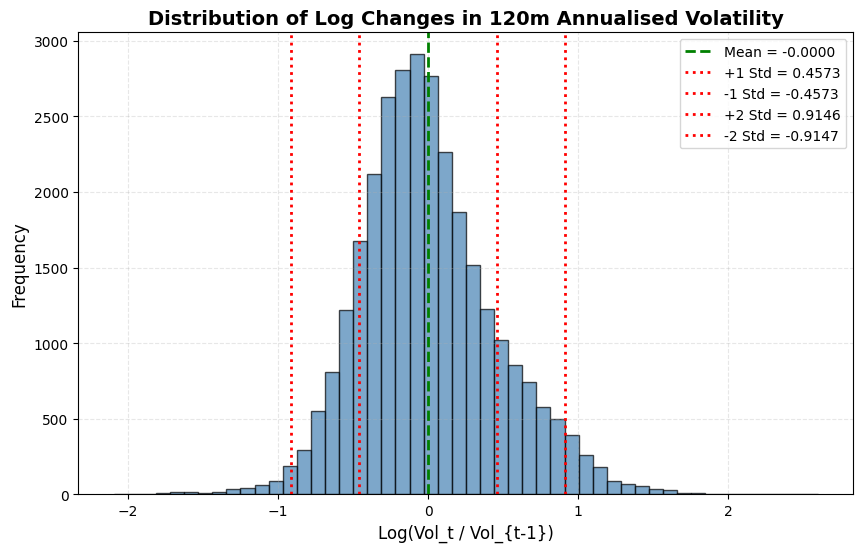

Mean: -0.0000, Std Dev: 0.4573, Min: -2.0953, Max: 2.5993


In [ ]:
# Histogram of Log Changes in 120m Volatility


# Extract volatility column
vol = CC_120m_rvol['RVol_120min_Close-to-Close'].values

# Compute log ratio: log(Vol_t / Vol_{t-1})
log_vol_change = np.log(vol[1:] / vol[:-1])
#log_vol_change = CC_120m_rvol['RVol_120min_Close-to-Close'].pct_change() * 100
#log_vol_change = log_vol_change.dropna().values
# Calculate statistics
mean_val = np.mean(log_vol_change)
std_val = np.std(log_vol_change)
min_val = np.min(log_vol_change)
max_val = np.max(log_vol_change)

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(log_vol_change, bins=50, color='steelblue', edgecolor='black', alpha=0.7)

# Add vertical lines
# Mean (green)
plt.axvline(mean_val, color='green', linestyle='dashed', linewidth=2, label=f"Mean = {mean_val:.4f}")

# ±1 Std Dev (red)
plt.axvline(mean_val + std_val, color='red', linestyle='dotted', linewidth=2, label=f"+1 Std = {mean_val+std_val:.4f}")
plt.axvline(mean_val - std_val, color='red', linestyle='dotted', linewidth=2, label=f"-1 Std = {mean_val-std_val:.4f}")

# ±2 Std Dev (red)
plt.axvline(mean_val + 2*std_val, color='red', linestyle='dotted', linewidth=2, label=f"+2 Std = {mean_val+2*std_val:.4f}")
plt.axvline(mean_val - 2*std_val, color='red', linestyle='dotted', linewidth=2, label=f"-2 Std = {mean_val-2*std_val:.4f}")

# Axis labels & title
plt.xlabel("Log(Vol_t / Vol_{t-1})", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Log Changes in 120m Annualised Volatility", fontsize=14, weight='bold')

# Add legend
plt.legend()

# Grid for clarity
plt.grid(alpha=0.3, linestyle='--')

# Show plot
plt.show()

# Print summary stats
print(f"Mean: {mean_val:.4f}, Std Dev: {std_val:.4f}, Min: {min_val:.4f}, Max: {max_val:.4f}")


In [ ]:
# Make a copy of your original DataFrame so we don’t overwrite it by mistake
df = CC_120m_rvol.copy().reset_index(drop=True)

# Column name where the annualised volatility values are stored
vol_col = 'RVol_120min_Close-to-Close'

# -----------------------------
# STEP 1: Define spike threshold
# -----------------------------

# This is the 2nd standard deviation value (from histogram of log changes)
# It’s in "log terms", so we convert it back to normal scale
log_threshold = 0.9147

# Convert log threshold into a multiplicative factor
# Example: log(Vol2/Vol1) > 0.9147  →  Vol2/Vol1 > exp(0.9147)
factor_threshold = np.exp(log_threshold)   # ≈ 2.496

# Convert factor into percentage increase
# Example: if factor = 2.496, then spike = ~149.6% increase
perc_threshold = (factor_threshold - 1) * 100  # ≈ 149.6%

# -----------------------------
# STEP 2: Calculate % change
# -----------------------------

# Compute percentage change in volatility from previous row
# Formula: (Vol_t - Vol_(t-1)) / Vol_(t-1) * 100
df['perc_change'] = df[vol_col].pct_change() * 100

# -----------------------------
# STEP 3: Flag spikes
# -----------------------------

# Mark rows where the volatility increase is greater than spike threshold
df['is_spike'] = df['perc_change'] > perc_threshold

# -----------------------------
# STEP 4: Inspect results
# -----------------------------

print(f"Spike threshold: {perc_threshold:.2f}% increase over previous volatility")

# Show first few rows where spike happened
print(
    df.loc[df['is_spike'], 
           ['StartDateTime', vol_col, 'perc_change']]
    
)
print(f"Total spikes detected: {df['is_spike'].sum()} out of {len(df)} rows")

Spike threshold: 149.60% increase over previous volatility
            StartDateTime  RVol_120min_Close-to-Close  perc_change
34    2012-01-05 02:00:00                   22.242295   263.753767
104   2012-01-13 00:00:00                   14.671089   207.063581
175   2012-01-23 02:00:00                   14.655514   164.133648
285   2012-02-03 08:00:00                   32.649475   185.951204
325   2012-02-08 18:00:00                   15.467783   196.075115
...                   ...                         ...          ...
29805 2021-12-10 08:00:00                   19.601270   230.705331
29841 2021-12-15 14:00:00                   26.639509   389.699877
29847 2021-12-16 02:00:00                    8.613116   184.971619
29938 2021-12-28 02:00:00                    7.297020   157.459782
29950 2021-12-29 02:00:00                    7.242900   155.964377

[1126 rows x 3 columns]
Total spikes detected: 1126 out of 29979 rows


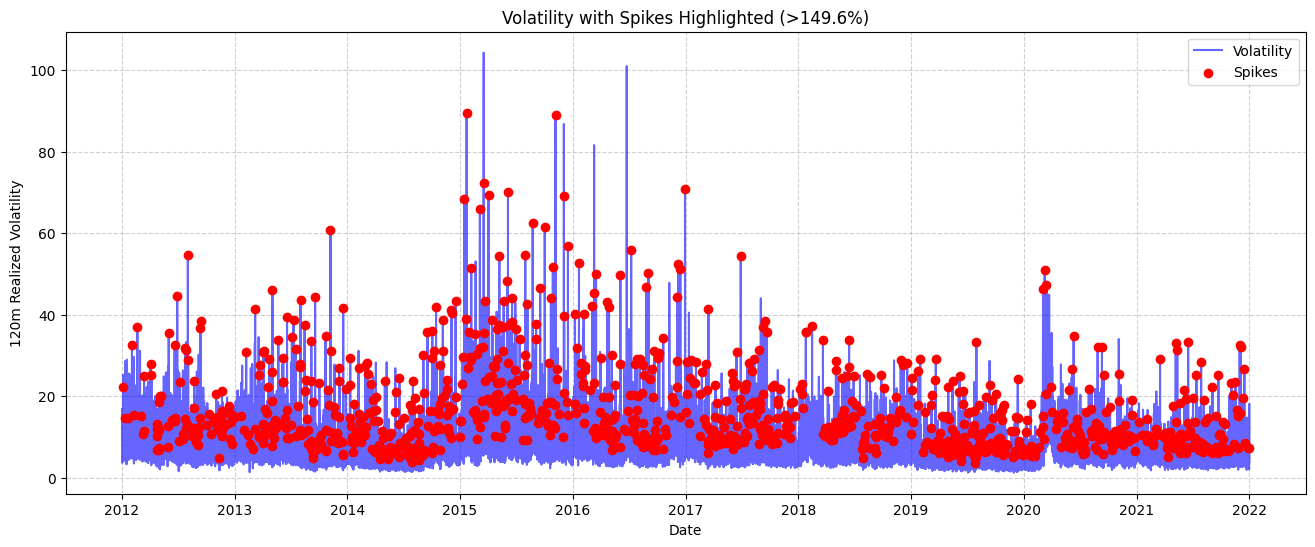

In [ ]:
# Filter spike rows into a new DataFrame
spikes = df.loc[df['is_spike'], ['StartDateTime', 'RVol_120min_Close-to-Close', 'perc_change']]

# Plot full volatility
plt.figure(figsize=(16,6))
plt.plot(df['StartDateTime'], df['RVol_120min_Close-to-Close'], 
         label='Volatility', color='blue', alpha=0.6)

# Overlay only spike points
plt.scatter(spikes['StartDateTime'], spikes['RVol_120min_Close-to-Close'], 
            color='red', label='Spikes', zorder=5)

plt.title('Volatility with Spikes Highlighted (>149.6%)')
plt.xlabel('Date')
plt.ylabel('120m Realized Volatility')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [ ]:
import numpy as np
import pandas as pd

def get_vols_after_spikes(df, vol_col, std_threshold=2, n_forward=5, dropna=True):
    """
    Identifies volatility spikes and extracts the next N volatility values after each spike.

    Parameters:
    -----------
    df : pd.DataFrame
        The DataFrame containing the volatility column.
    vol_col : str
        Name of the volatility column (e.g., 'RVol_120min_Close-to-Close').
    std_threshold : float
        Number of standard deviations to define a spike.
    n_forward : int
        How many volatility values to extract after each spike.
    dropna : bool
        Whether to drop rows with NaNs in the resulting output.

    Returns:
    --------
    pd.DataFrame
        A DataFrame where each row represents a spike and the subsequent N volatility values.
    """

    df = df.copy().reset_index(drop=True)
    
    # Step 1: Compute % change in volatility
    df['vol_change'] = df[vol_col].pct_change() * 100

    # Step 2: Compute spike threshold from distribution
    mean_change = df['vol_change'].mean()
    std_change = df['vol_change'].std()
    spike_threshold = mean_change + std_threshold * std_change

    # Step 3: Identify spike indices
    spike_indices = df.index[df['vol_change'] > spike_threshold].tolist()

    # Step 4: Gather forward vols after each spike
    post_spike_vols = []
    for idx in spike_indices:
        if idx + n_forward < len(df):
            post_vols = df.loc[idx+1:idx+n_forward, vol_col].values
            post_spike_vols.append(post_vols)

    # Step 5: Convert to DataFrame
    columns = [f'Vol_t+{i+1}' for i in range(n_forward)]
    spike_vol_df = pd.DataFrame(post_spike_vols, columns=columns)

    if dropna:
        spike_vol_df.dropna(inplace=True)

    # Optional: Add the original spike timestamp
    spike_vol_df['Spike_Index'] = spike_indices[:len(spike_vol_df)]
    spike_vol_df.set_index('Spike_Index', inplace=True)

    return spike_vol_df


In [ ]:
spike_vols_df = get_vols_after_spikes(CC_120m_rvol, vol_col='RVol_120min_Close-to-Close', std_threshold=2, n_forward=50, dropna=False)

In [ ]:
spike_vols_df

,Vol_t+1,Vol_t+2,Vol_t+3,Vol_t+4,Vol_t+5,Vol_t+6,Vol_t+7,Vol_t+8,Vol_t+9,Vol_t+10,...,Vol_t+41,Vol_t+42,Vol_t+43,Vol_t+44,Vol_t+45,Vol_t+46,Vol_t+47,Vol_t+48,Vol_t+49,Vol_t+50
Spike_Index,,,,,,,,,,,,,,,,,,,,,
34,22.903590,12.256428,25.225224,16.247096,9.443847,7.561368,11.397566,7.557129,4.920089,5.961655,...,7.870789,5.575281,9.393750,8.977894,5.573011,7.662260,13.765280,12.667858,23.092672,19.604303
104,15.501204,28.669903,14.494144,24.779584,25.362711,10.931546,10.716766,8.662682,9.354200,7.014591,...,14.147016,8.279810,8.427340,9.288940,9.980388,8.196076,8.366637,16.946908,18.094104,14.647575
175,17.653490,17.209484,16.845718,12.546310,10.023044,9.246740,10.889127,7.893593,7.687917,5.631249,...,12.933274,9.747582,4.617415,9.769860,7.304294,8.739849,8.777024,14.319342,18.743311,11.287656
187,19.837912,16.372383,17.861281,13.367531,7.752876,4.366758,5.321487,9.134990,7.341280,5.395210,...,19.881876,9.900369,8.786904,8.225538,7.002859,9.538770,14.999313,13.141966,12.916730,15.542793
204,20.819962,7.799027,8.489879,8.068104,5.114452,7.874898,15.239076,16.524039,12.209565,17.190154,...,9.039912,14.531870,13.271321,12.229058,12.989762,20.979473,9.852857,9.215922,5.727162,8.462526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29805,10.982755,5.922363,3.633638,4.136020,5.672220,2.882153,3.347240,6.242468,7.175251,7.482398,...,3.022447,8.613116,6.266854,14.586634,13.243537,12.664142,6.008532,5.159958,3.862517,4.509394
29841,4.974106,5.025838,3.666623,2.757065,3.022447,8.613116,6.266854,14.586634,13.243537,12.664142,...,8.464919,7.342446,7.193520,8.169990,10.559970,7.427359,4.222640,7.602718,3.987557,4.700049
29847,6.266854,14.586634,13.243537,12.664142,6.008532,5.159958,3.862517,4.509394,5.029181,3.180046,...,4.222640,7.602718,3.987557,4.700049,2.504931,4.511960,7.158438,8.305042,7.450844,9.411475


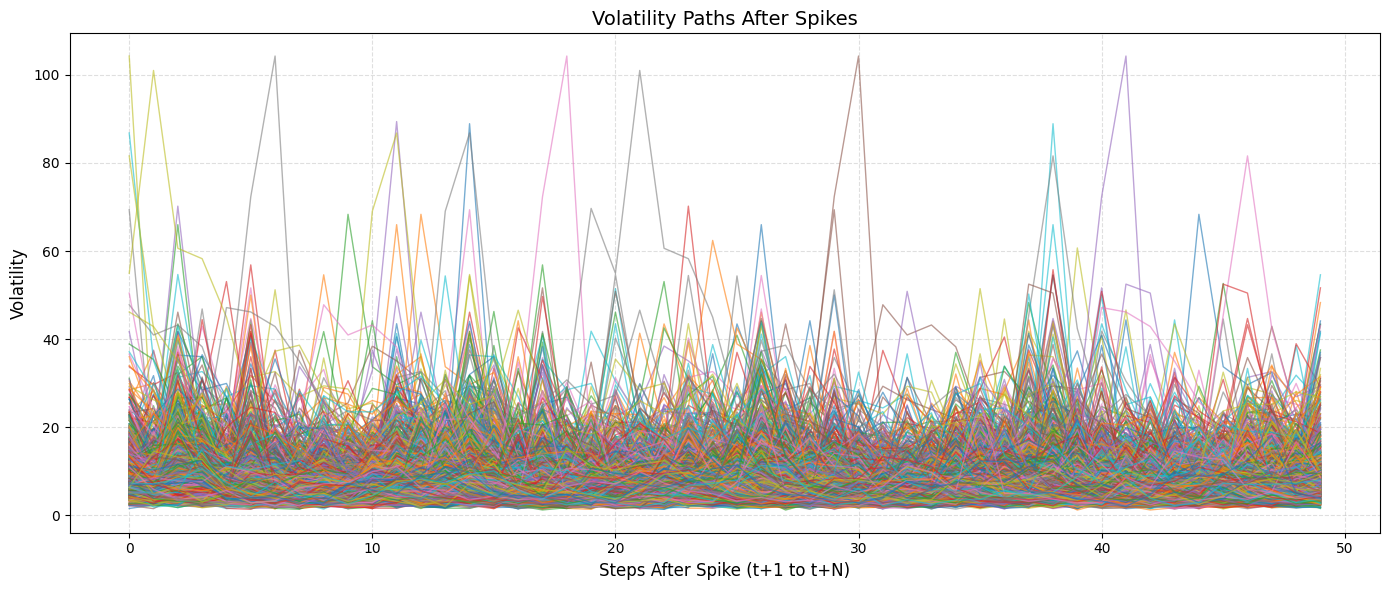

In [ ]:
import matplotlib.pyplot as plt

def plot_spike_vol_paths(spike_vol_df, title="Volatility Paths After Spikes"):
    plt.figure(figsize=(14, 6))

    for idx, row in spike_vol_df.iterrows():
        plt.plot(row.values, alpha=0.6, linewidth=1)

    plt.title(title, fontsize=14)
    plt.xlabel("Steps After Spike (t+1 to t+N)", fontsize=12)
    plt.ylabel("Volatility", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
plot_spike_vol_paths(spike_vols_df)


In [ ]:
#######  ENDS HERE #########

In [ ]:
pip install databento

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import databento as db

In [ ]:
import pandas as pd
import numpy as np
from io import StringIO

# Sample data as provided
data = """date,open,high,low,close,volume
1/9/2015 9:15,8467.95,8476.75,8467.75,8469.9,0
1/9/2015 9:16,8469.9,8469.9,8461.15,8462.35,0
1/9/2015 9:17,8462.95,8462.95,8454.85,8456.3,0"""

# Read into a DataFrame
df = pd.read_csv(r'C:\Users\estifo\AppData\Local\Temp\275e1fa5-14fe-400d-8d3e-11508331bf42_Nifty Data.zip.f42\NIFTY AUTO_minute_data.csv', parse_dates=['date'])

# Rename columns to have first letter capitalized for OHLC
df.rename(columns={
    'date': 'DateTime',
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close',
    'volume': 'Volume'
}, inplace=True)


# Add 'indicator' column: 1 if any OHLC is NaN, else 0
df['indicator'] = df[['Open', 'High', 'Low', 'Close']].isna().any(axis=1).astype(int)

# Add 'Hour' column
df['Hour'] = df['DateTime'].dt.hour
data = df.copy()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\estifo\\AppData\\Local\\Temp\\275e1fa5-14fe-400d-8d3e-11508331bf42_Nifty Data.zip.f42\\NIFTY AUTO_minute_data.csv'

In [ ]:
data

,DateTime,Open,High,Low,Close,Volume,indicator,Hour
0,2015-01-09 09:15:00,8467.95,8476.75,8467.75,8469.90,0,0,9
1,2015-01-09 09:16:00,8469.90,8469.90,8461.15,8462.35,0,0,9
2,2015-01-09 09:17:00,8462.95,8462.95,8454.85,8456.30,0,0,9
3,2015-01-09 09:18:00,8456.30,8460.15,8456.30,8459.80,0,0,9
4,2015-01-09 09:19:00,8459.80,8468.55,8459.80,8468.55,0,0,9
...,...,...,...,...,...,...,...,...
932517,2025-02-07 15:25:00,23466.50,23468.90,23462.50,23462.50,0,0,15
932518,2025-02-07 15:26:00,23462.50,23463.20,23449.20,23454.60,0,0,15
932519,2025-02-07 15:27:00,23454.60,23470.25,23451.55,23467.45,0,0,15
932520,2025-02-07 15:28:00,23469.50,23469.50,23444.20,23446.00,0,0,15


C:\Users\estifo\AppData\Local\Temp\ipykernel_26492\3665320587.py:702: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Prev_Close_global'].fillna(data['Open'], inplace=True)
C:\Users\estifo\AppData\Local\Temp\ipykernel_26492\3665320587.py:62: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ohlc['group_id'] = ohlc.index.floor(f"{timeframe}T")


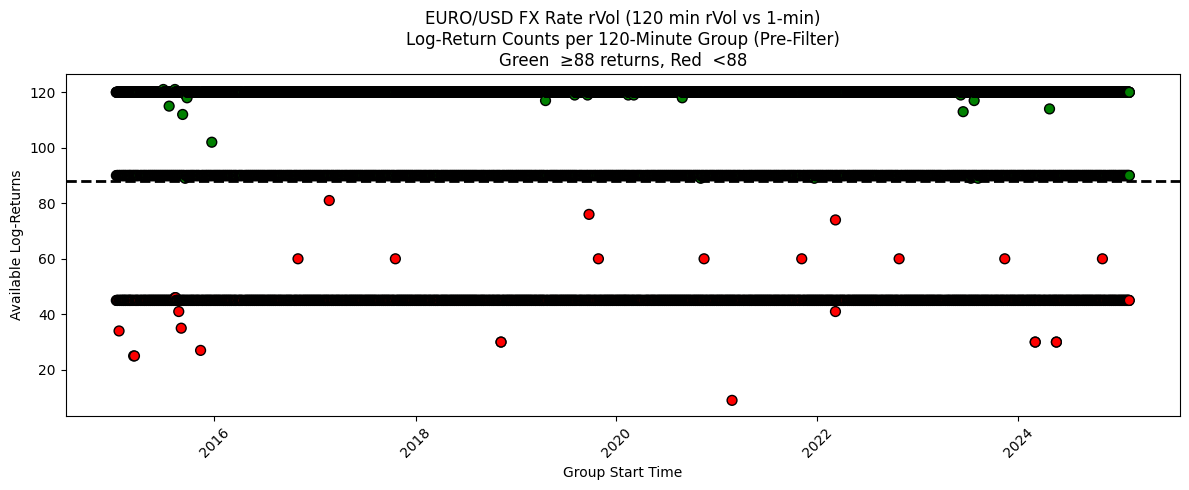

Keeping 7452 groups (the green ones) out of 9960 total.


C:\Users\estifo\AppData\Local\Temp\ipykernel_26492\3665320587.py:151: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grp: compute_volatility_measure(grp, vol_measure))


                          sum  count
group_id                            
2015-01-09 10:00:00  0.000009    120
2015-01-09 12:00:00  0.000060    120
2015-01-09 14:00:00  0.000018     90
2015-01-12 10:00:00  0.000011    120
2015-01-12 12:00:00  0.000017    120
...                       ...    ...
2025-02-06 12:00:00  0.000014    120
2025-02-06 14:00:00  0.000011     90
2025-02-07 10:00:00  0.000060    120
2025-02-07 12:00:00  0.000058    120
2025-02-07 14:00:00  0.000036     90

[7452 rows x 2 columns]


C:\Users\estifo\AppData\Local\Temp\ipykernel_26492\3665320587.py:366: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Prev_Close_global'].fillna(data['Open_first'], inplace=True)


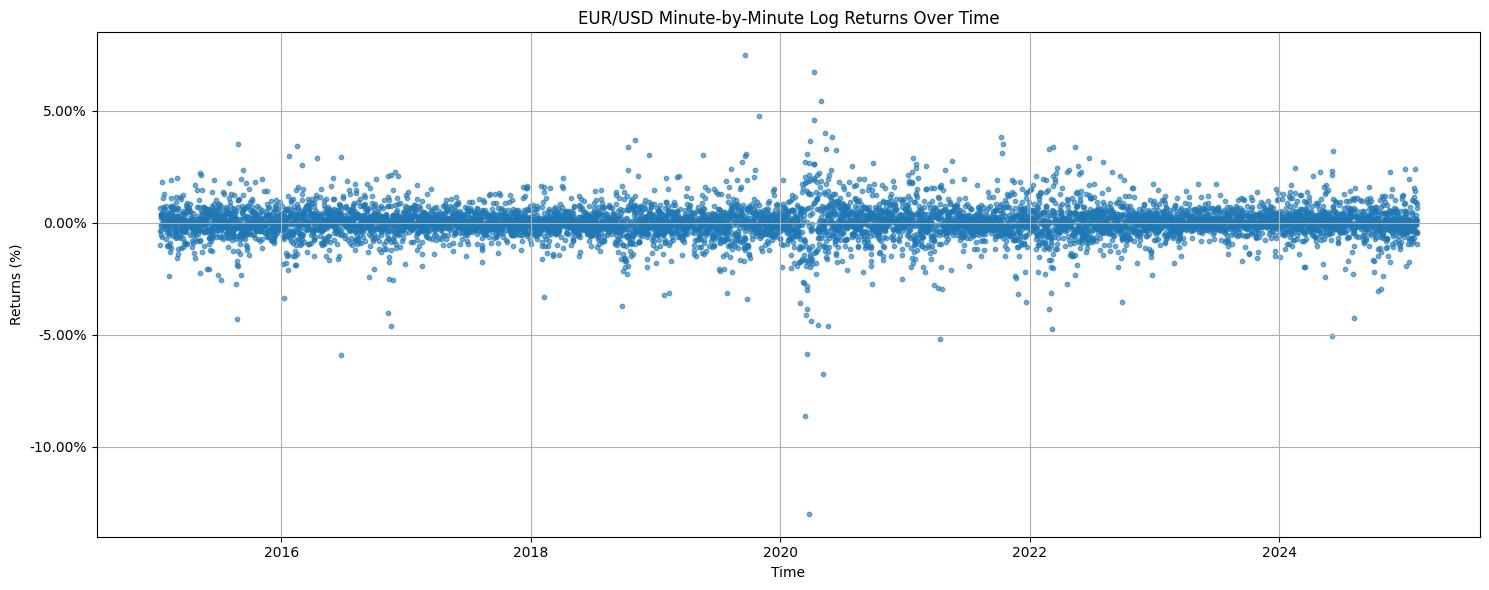

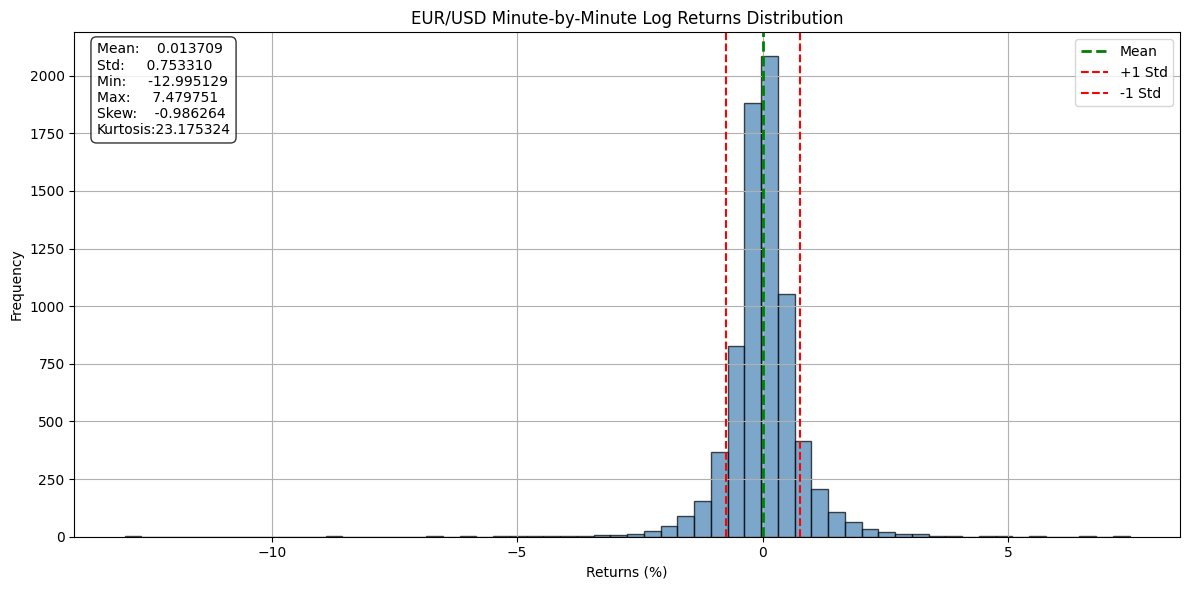

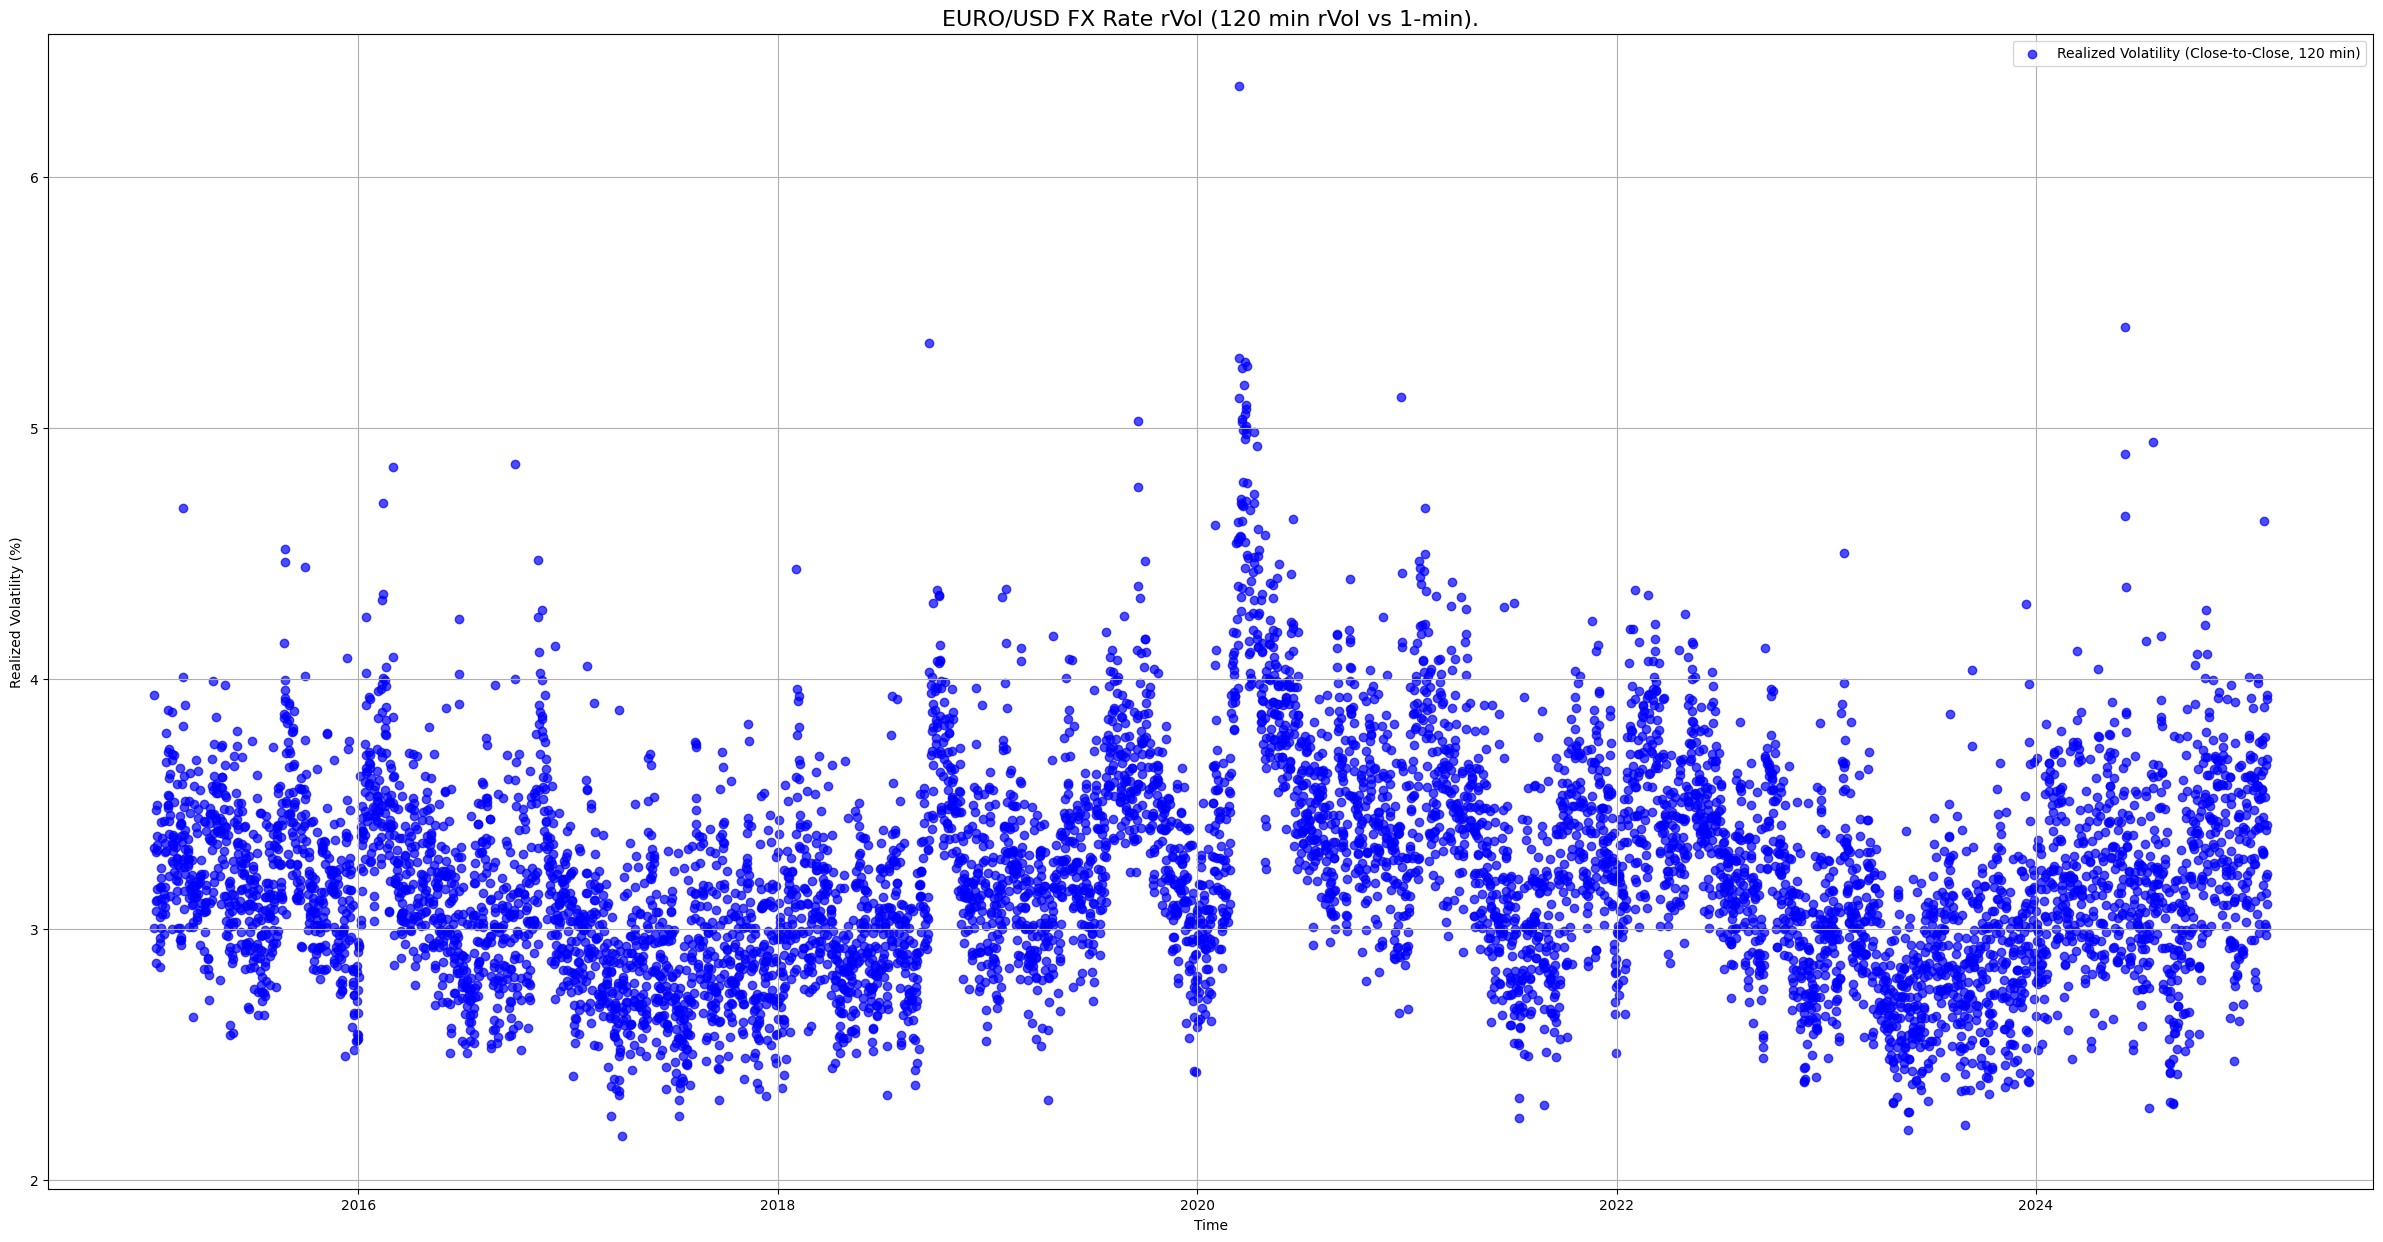

                group_id       StartDateTime         EndDateTime  Open_first  \
0    2015-01-09 10:00:00 2015-01-09 10:00:00 2015-01-09 11:59:00     8445.20   
1    2015-01-09 12:00:00 2015-01-09 12:00:00 2015-01-09 13:59:00     8415.65   
2    2015-01-09 14:00:00 2015-01-09 14:00:00 2015-01-09 15:29:00     8332.95   
3    2015-01-12 10:00:00 2015-01-12 10:00:00 2015-01-12 11:59:00     8369.00   
4    2015-01-12 12:00:00 2015-01-12 12:00:00 2015-01-12 13:59:00     8376.55   
...                  ...                 ...                 ...         ...   
7447 2025-02-06 12:00:00 2025-02-06 12:00:00 2025-02-06 13:59:00    23397.50   
7448 2025-02-06 14:00:00 2025-02-06 14:00:00 2025-02-06 15:29:00    23305.45   
7449 2025-02-07 10:00:00 2025-02-07 10:00:00 2025-02-07 11:59:00    23367.55   
7450 2025-02-07 12:00:00 2025-02-07 12:00:00 2025-02-07 13:59:00    23528.70   
7451 2025-02-07 14:00:00 2025-02-07 14:00:00 2025-02-07 15:29:00    23308.60   

      High_max   Low_min  Close_last  V

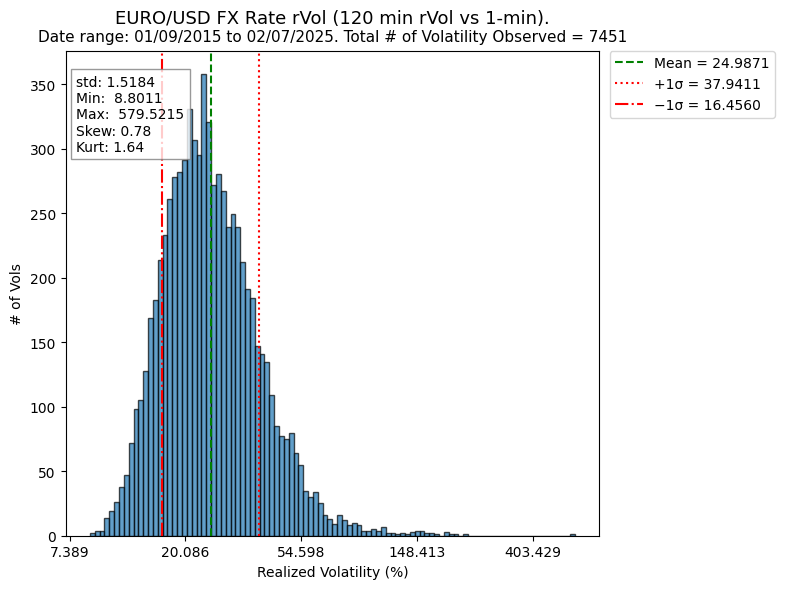

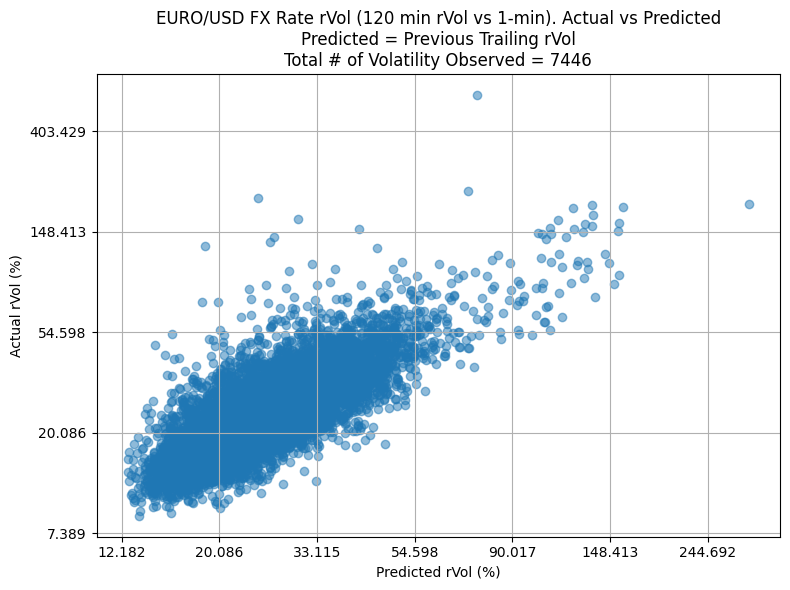

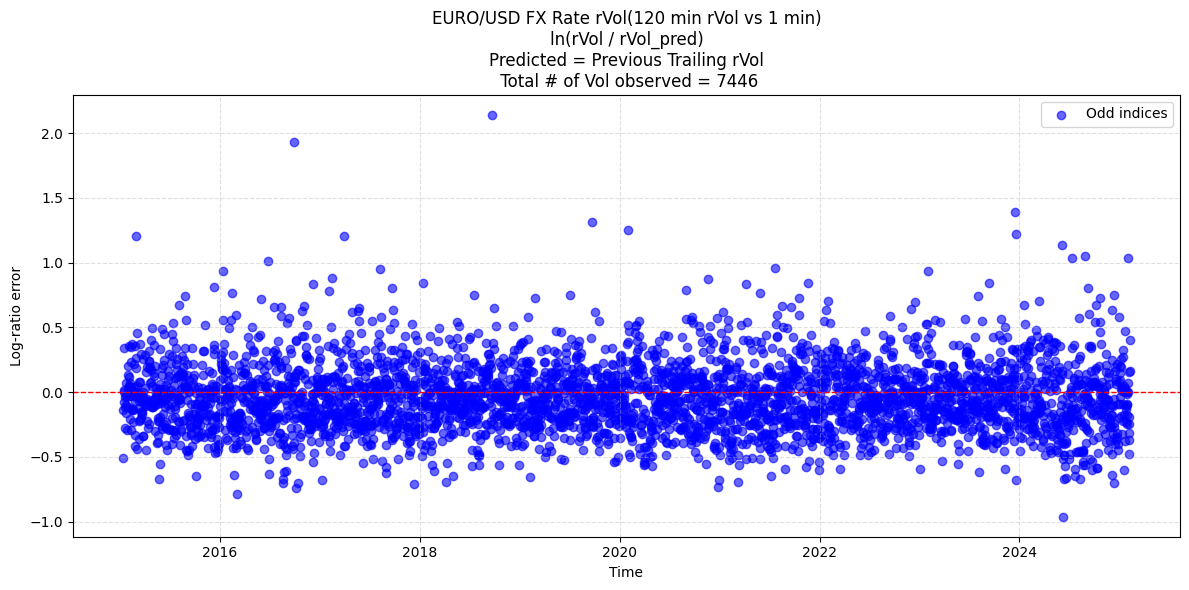

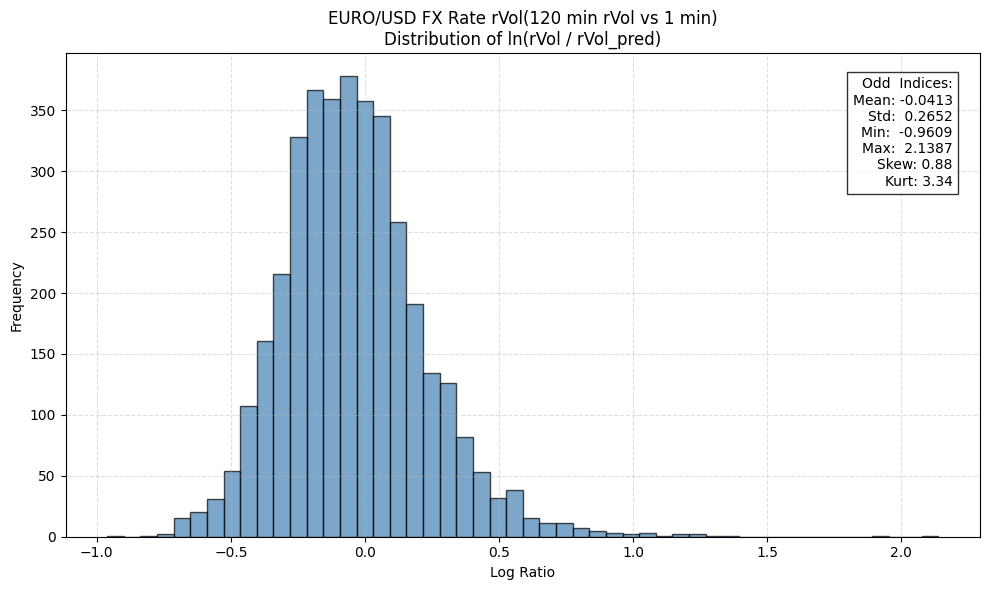

In [ ]:
RS_120m_rvol = calculate_rvol(data, vol_measure = 'Close-to-Close', timeframe = 120, minute_interval = 1, threshold = 0.2667, vol_title = 'RVol_120min_Close-to-Close') # Choose 'Garman-Klass', 'Rogers-Satchell', or 'Close-to-Close'